In [1]:
!python --version
import os
import warnings
print (os.environ['CONDA_DEFAULT_ENV'])

#suppress warnings
warnings.filterwarnings('ignore')

Python 3.10.18
culRI-Bayesian-py310


# 1. Workbook setups

## 1.1 Import packages

In [2]:
import pandas as pd
import numpy as np
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
import math
from scipy.stats import pearsonr, spearmanr, truncnorm
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor

import statsmodels.api as sm

import matplotlib as mpl

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo

import proplot as plot
import seaborn as sns
from shapely.geometry import Point, Polygon

from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time

from cmdstanpy import CmdStanModel

## 1.2 Miscellaneous codes

In [3]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,lon2 = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(lon2,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    lon1, lat1 = origin
    lon2, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient



### 1.2.1 Pred TEX and Pred SST from previous calibrations

In [4]:
def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten2002, schouten2003, kim2008, OBrien2017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten2002':(66.6667,-18.6667),
        'schouten2003':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien2017':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_coretop_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_coretop_linear':(69.61698822,-16.73443208),
        'low23_coretop_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_coretop_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_coretop_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_coretop_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten2002, schouten2003, kim2008, OBrien2017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten2002':(0.015,0.280),
        'schouten2003':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien2017':(0.0170,0.19),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_coretop_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_coretop_linear':(69.61698822,-16.73443208),
        'low23_coretop_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_coretop_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_coretop_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_coretop_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

## 1.3 Dictionaries

In [5]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


def label_pvalues(x):
    if x<0.001:
        return r'$\it{p}$<.001'
    elif x<0.01:
        return r'$\it{p}$<.01'
    elif x<0.05:
        return r'$\it{p}$<.05'
    elif x<0.1:
        return r'$\it{p}$<.1'
    elif x>=0.1:
        return r'$\it{p}$>.1'


## 1.4 Set local paths

In [6]:
# set the path to local folder other than github
login_name = os.getlogin()
### 1.4.1 Local path on PC
local_documents_path = f'/home/{login_name}/Documents' ### this is the path when code is run on Linux

### 1.4.2 Path to github folder
gitpath_idx = os.getcwd().find('culRI-Bayesian')+len('culRI-Bayesian')
local_github_path = os.getcwd()[:gitpath_idx]

### 1.4.3 Path to OneDrive folder
local_onedrive_path = f'/home/{login_name}/OneDrive'


### stan_models path 
stan_models_path = local_github_path+'/culRIBayesian/stan_models/'

# 2. Import data

## 2.1 Import Ocean Data Products

In [7]:
fpath2 = fr'{local_documents_path}/Postdoc/TEXAS-PSM/netcdf/WOA-database/WOA23/WOA-decav'
ts = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_t00_04.nc'),decode_times=False).drop('time')

T_da = ts.isel(time=0).load()
T_da

<xarray.Dataset>
Dimensions:             (lat: 720, nbounds: 2, lon: 1440, depth: 102)
Coordinates:
  * lat                 (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon                 (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
  * depth               (depth) float32 0.0 5.0 10.0 ... 5.3e+03 5.4e+03 5.5e+03
Dimensions without coordinates: nbounds
Data variables: (12/14)
    crs                 int32 -2147483647
    lat_bnds            (lat, nbounds) float32 -90.0 -89.75 ... 89.75 90.0
    lon_bnds            (lon, nbounds) float32 -180.0 -179.8 ... 179.8 180.0
    depth_bnds          (depth, nbounds) float32 0.0 2.5 ... 5.45e+03 5.5e+03
    climatology_bounds  (nbounds) float32 1.704e+03 2.064e+03
    t_an                (depth, lat, lon) float32 nan nan nan ... nan nan nan
    ...                  ...
    t_sd                (depth, lat, lon) float32 nan nan nan ... nan nan nan
    t_se                (depth, lat, lon) float32 nan nan nan ... nan nan nan
    t_oa                (depth, lat, lon) float32 nan nan nan ... nan nan nan
    t_gp                (depth, lat, lon) float64 nan nan nan ... nan nan nan
    t_sdo               (depth, lat, lon) float32 nan nan nan ... nan nan nan
    t_sea               (depth, lat, lon) float32 nan nan nan ... nan nan nan
Attributes: (12/45)
    Conventions:                     CF-1.6
    title:                           World Ocean Atlas 2023 : sea_water_tempe...
    summary:                         Climatological mean temperature for the ...
    references:                      Locarnini, R.A., A.V. Mishonov, O.K. Bar...
    institution:                     NOAA National Centers for Environmental ...
    comment:                         Global Climatology as part of the World ...
    ...                              ...
    ncei_template_version:           NCEI_NetCDF_Grid_Template_v1.0
    license:                         These data are openly available to the p...
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    metadata_link:                   https://www.ncei.noaa.gov/products/world...
    date_created:                    2024-01-28 
    date_modified:                   2024-01-28

In [8]:
import glob

fpath2 = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature/monthly'
### read multiple netcdf files
nc_files = sorted(glob.glob(os.path.join(fpath2, '*.nc')))

ds = xr.open_mfdataset(nc_files, decode_times=False, combine='by_coords').drop('time')
## assign month as coordinates from 1 to 12 
ds['month'] = np.arange(1,13)
ds

<xarray.Dataset>
Dimensions:             (time: 12, lat: 720, nbounds: 2, lon: 1440, depth: 57,
                         month: 12)
Coordinates:
  * lat                 (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon                 (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
  * depth               (depth) float32 0.0 5.0 10.0 ... 1.45e+03 1.5e+03
  * month               (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: time, nbounds
Data variables: (12/15)
    crs                 (time) int32 -2147483647 -2147483647 ... -2147483647
    lat_bnds            (time, lat, nbounds) float32 dask.array<chunksize=(1, 720, 2), meta=np.ndarray>
    lon_bnds            (time, lon, nbounds) float32 dask.array<chunksize=(1, 1440, 2), meta=np.ndarray>
    depth_bnds          (time, depth, nbounds) float32 dask.array<chunksize=(1, 57, 2), meta=np.ndarray>
    climatology_bounds  (time, nbounds) float32 dask.array<chunksize=(1, 2), meta=np.ndarray>
    t_an                (time, depth, lat, lon) float32 dask.array<chunksize=(1, 57, 720, 1440), meta=np.ndarray>
    ...                  ...
    t_se                (time, depth, lat, lon) float32 dask.array<chunksize=(1, 57, 720, 1440), meta=np.ndarray>
    t_oa                (time, depth, lat, lon) float32 dask.array<chunksize=(1, 57, 720, 1440), meta=np.ndarray>
    t_ma                (time, depth, lat, lon) float32 dask.array<chunksize=(1, 57, 720, 1440), meta=np.ndarray>
    t_gp                (time, depth, lat, lon) float64 dask.array<chunksize=(1, 57, 720, 1440), meta=np.ndarray>
    t_sdo               (time, depth, lat, lon) float32 dask.array<chunksize=(1, 57, 720, 1440), meta=np.ndarray>
    t_sea               (time, depth, lat, lon) float32 dask.array<chunksize=(1, 57, 720, 1440), meta=np.ndarray>
Attributes: (12/45)
    Conventions:                     CF-1.6
    title:                           World Ocean Atlas 2023 : sea_water_tempe...
    summary:                         Climatological mean temperature for the ...
    references:                      Locarnini, R.A., A.V. Mishonov, O.K. Bar...
    institution:                     NOAA National Centers for Environmental ...
    comment:                         Global Climatology as part of the World ...
    ...                              ...
    ncei_template_version:           NCEI_NetCDF_Grid_Template_v1.0
    license:                         These data are openly available to the p...
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    metadata_link:                   https://www.ncei.noaa.gov/products/world...
    date_created:                    2024-01-28 
    date_modified:                   2024-01-28

In [9]:
T_diff = ds.t_an.isel(depth=0).max(dim='time') - ds.t_an.isel(depth=0).min(dim='time')
T_max = ds.t_an.isel(depth=0).max(dim='time')
T_min = ds.t_an.isel(depth=0).min(dim='time')

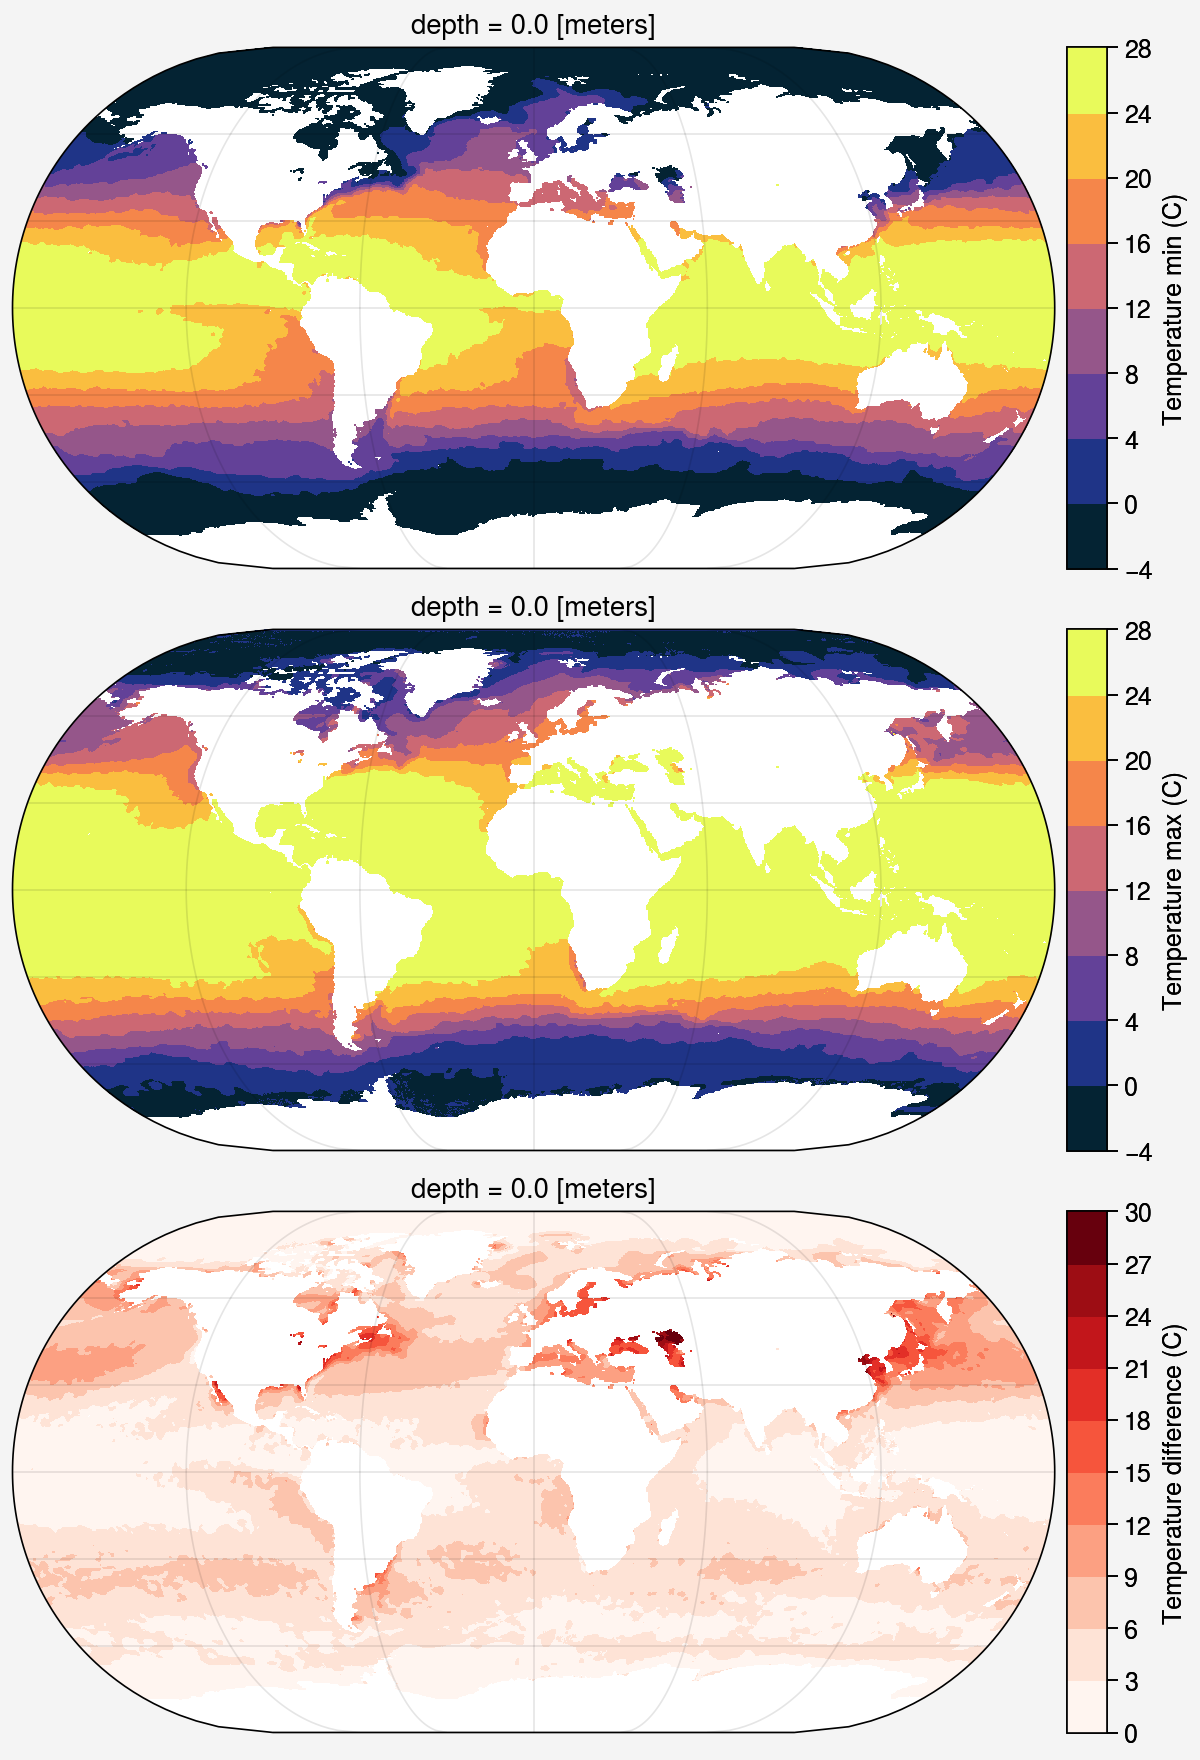

In [10]:
fig, axs = plot.subplots(nrows=3,proj='eck3',width=6)
T_min.plot(ax=axs[0],robust=True,vmin=-4,vmax=30, cmap='cmo.thermal', cbar_kwargs={'label':'Temperature min (C)'})
T_max.plot(ax=axs[1],robust=True,vmin=-4,vmax=30, cmap='cmo.thermal', cbar_kwargs={'label':'Temperature max (C)'})
T_diff.plot(ax=axs[2],robust=True,vmin=0,vmax=30, cmap='reds', cbar_kwargs={'label':'Temperature difference (C)'})

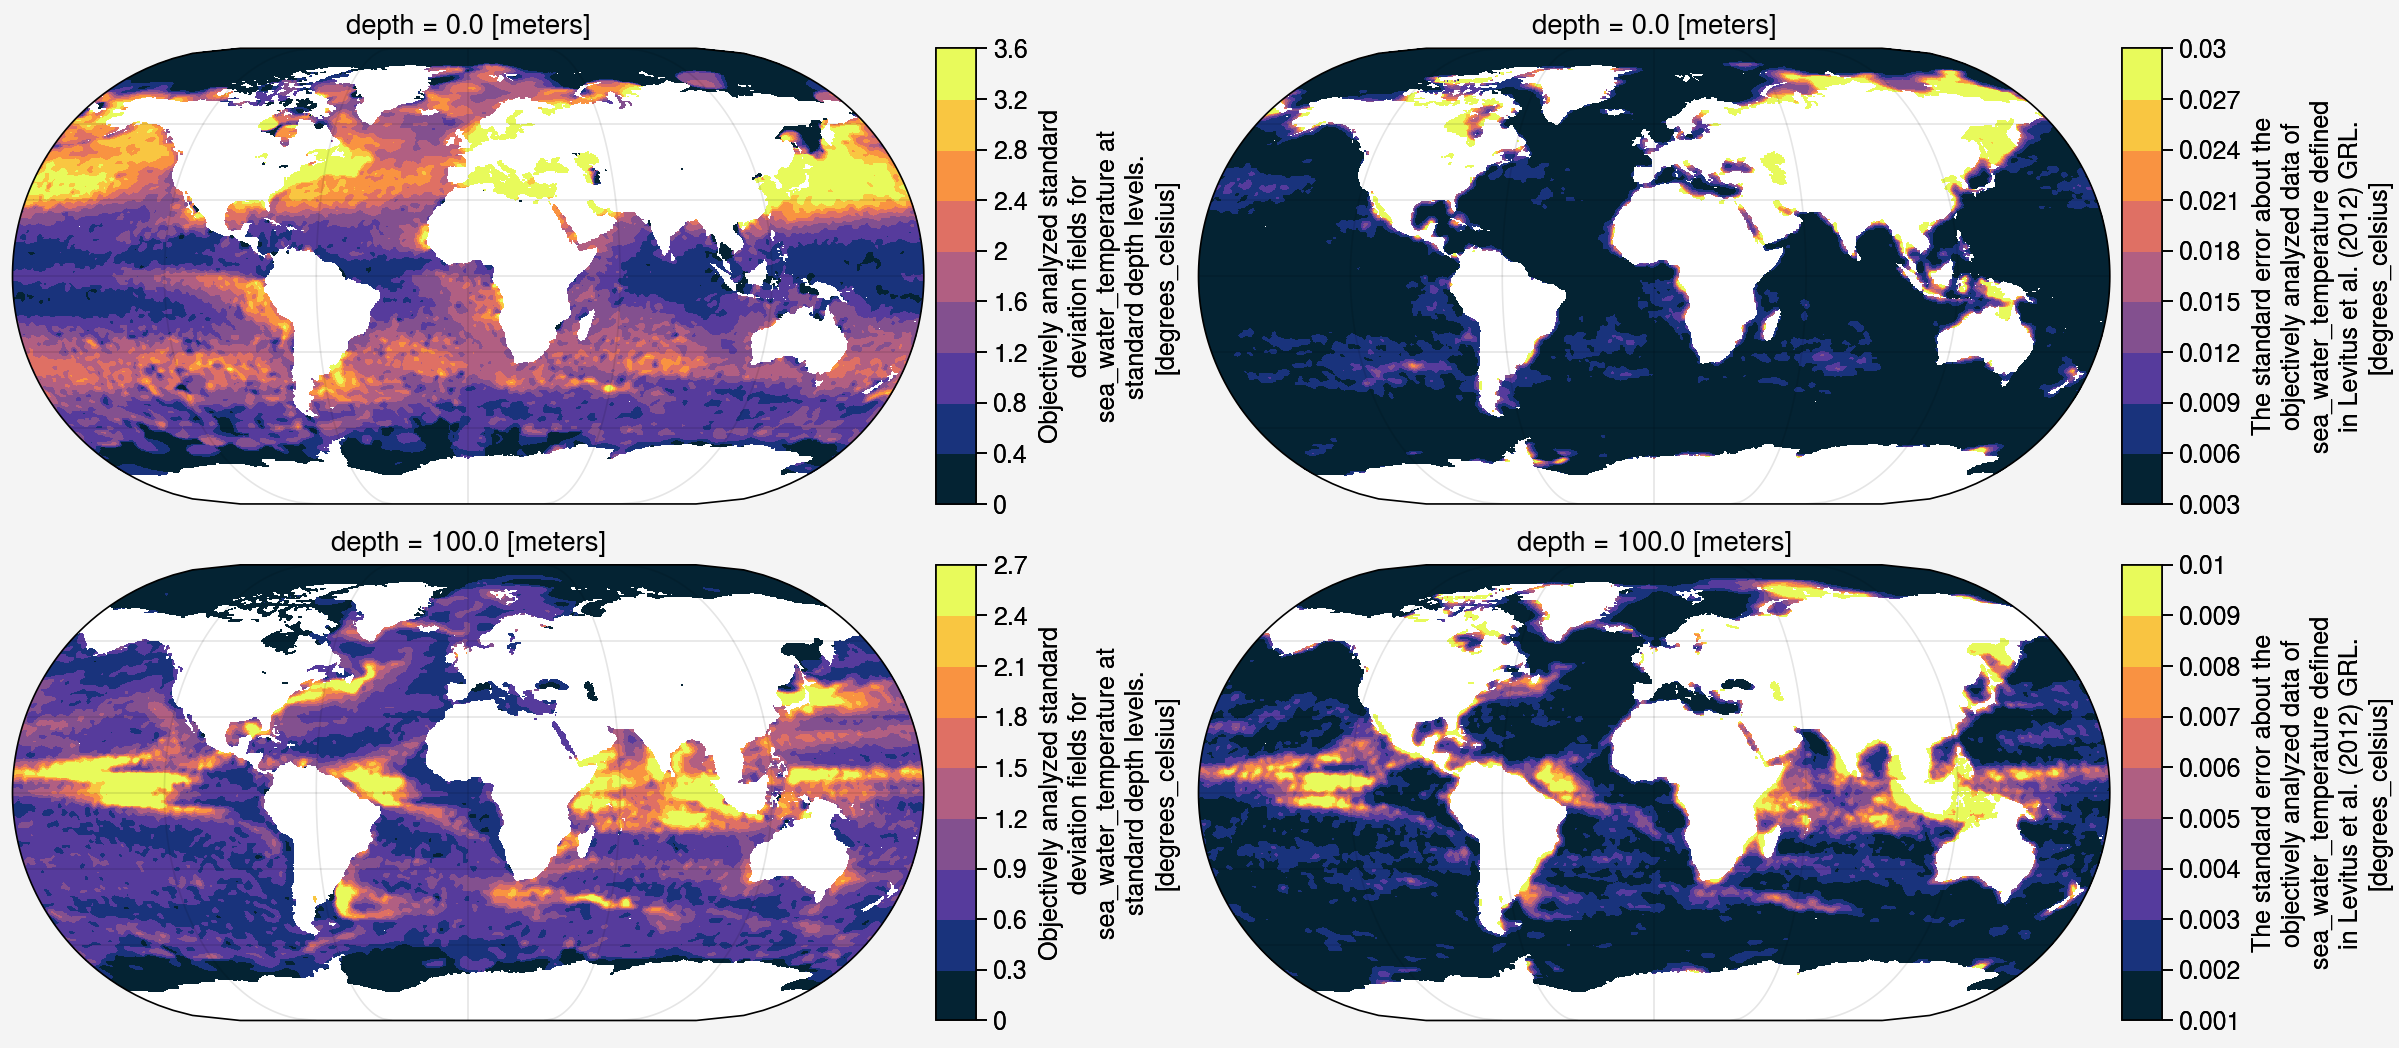

In [11]:
fig, axs = plot.subplots(width=12,proj='eck3',nrows=2,ncols=2)

ax = axs[0,0]
T_da.t_sdo.sel(depth=0,method='nearest').plot(cmap='cmo.thermal',robust=True,ax=ax,rasterized=True)

ax = axs[0,1]
T_da.t_sea.sel(depth=0,method='nearest').plot(cmap='cmo.thermal',robust=True,ax=ax,rasterized=True)

ax = axs[1,0]
T_da.t_sdo.sel(depth=100,method='nearest').plot(cmap='cmo.thermal',robust=True,ax=ax,rasterized=True)

ax = axs[1,1]
T_da.t_sea.sel(depth=100,method='nearest').plot(cmap='cmo.thermal',robust=True,ax=ax,rasterized=True)

In [12]:
fpath = f'{local_github_path}/nc_files/'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_properties_ds = xr.open_dataset(os.path.join(fpath, fname))
ocean_properties_ds

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

## 2.2 Import culture and mesocosm data

In [13]:
### Regression dataset compilation
fpath = fr'{local_github_path}/spreadsheets'
fname = r'culture_mesocosm_combined_rev_030425.csv'

culture_meso_df = pd.read_csv(os.path.join(fpath, fname))
culture_meso_growthrate = culture_meso_df[culture_meso_df['experiment_setup'].isin(['Culture-growth-rate','Culture-oxygen'])].reset_index(drop=True)  
culture_meso_df = culture_meso_df[culture_meso_df['experiment_setup'].isin(['mesocosm','Culture-temperature'])].reset_index(drop=True)
culture_meso_df['gdgt23ratio'] = culture_meso_df['fGDGT_2']/culture_meso_df['fGDGT_3']
# culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Sinninghe Damste et al. (2002) Journal of Lipid Research'].reset_index(drop=True)
culture_meso_df['Strains_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['Strains'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['Strains_edited'].iloc[i] = culture_meso_df['Strains'].iloc[i]

culture_meso_df['GTDB_genus_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['GTDB_genus'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['GTDB_genus_edited'].iloc[i] = culture_meso_df['GTDB_genus'].iloc[i]

culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Varma et al. (2024) Biogeosciences']
culture_meso_df


,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins,Strains_edited,GTDB_genus_edited
0,TEXAS_PSM_culture_RR001,Bale2019_019_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,37,0.578544,2.792553,0.698138,0.478873,13.0,p__Thermoproteota,...,0.125887,0.443262,0.081560,culture,0.420744,0.174917,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
1,TEXAS_PSM_culture_RR002,Bale2019_020_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,46,0.806931,3.734637,0.933659,0.482759,13.0,p__Thermoproteota,...,0.040503,0.712291,0.167598,culture,0.115169,0.007782,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
2,TEXAS_PSM_culture_RR003,Bale2019_021_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,50,0.755102,3.725664,0.931416,0.652174,13.0,p__Thermoproteota,...,0.029077,0.745891,0.139064,culture,0.109415,0.008403,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
3,TEXAS_PSM_culture_RR004,Elling2015_Culture_NA0A2_18,Elling et al. (2015) GCA,18,0.858108,2.437576,0.609394,0.402266,5.2,p__Thermoproteota,...,0.427879,0.161212,0.015758,culture,0.798621,0.429185,0,Culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
4,TEXAS_PSM_culture_RR005,Elling2015_Culture_NA0A2_22,Elling et al. (2015) GCA,22,0.827338,2.235429,0.558857,1.088785,5.2,p__Thermoproteota,...,0.244571,0.200000,0.014857,culture,0.742818,0.451411,0,Culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,TEXAS_PSM_mesocosm_RR017,meso_017,Schouten2007,25,0.449778,2.772491,0.693123,2.629108,0.0,mesocosm,...,0.013396,0.635200,0.011792,mesocosm,0.159209,0.266255,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
126,TEXAS_PSM_mesocosm_RR018,meso_018,Schouten2007,32,0.683519,2.627887,0.656972,3.553719,0.0,mesocosm,...,0.015702,0.564495,0.039904,mesocosm,0.169194,0.325581,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
127,TEXAS_PSM_mesocosm_RR019,meso_019,Schouten2007,34,0.606766,3.236153,0.809038,2.318038,0.0,mesocosm,...,0.019677,0.747221,0.011769,mesocosm,0.131807,0.144080,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
128,TEXAS_PSM_mesocosm_RR020,meso_020,Schouten2007,36,0.813041,3.598787,0.899697,2.396907,0.0,mesocosm,...,0.022633,0.822493,0.027125,mesocosm,0.106058,0.056856,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles


## 2.3 Import coretop data

In [14]:
fpath = f'{local_github_path}/nc_files/'
fname = 'ds04_gridded_coretop_tex_scaledRI.nc'
coretop_ds = xr.open_dataset(os.path.join(fpath, fname))
coretop_ds

<xarray.Dataset>
Dimensions:                    (lat: 720, lon: 1440)
Coordinates:
  * lat                        (lat) float32 -89.88 -89.62 ... 89.62 89.88
  * lon                        (lon) float32 -179.9 -179.6 ... 179.6 179.9
Data variables: (12/15)
    region_ID                  (lon, lat) float64 ...
    tex_count                  (lon, lat) float64 ...
    tex_median                 (lon, lat) float64 ...
    tex_mean                   (lon, lat) float64 ...
    tex_std                    (lon, lat) float64 ...
    scaledRI_count             (lon, lat) float64 ...
    ...                         ...
    gdgt23ratio_count          (lon, lat) float64 ...
    gdgt23ratio_median         (lon, lat) float64 ...
    gdgt23ratio_mean           (lon, lat) float64 ...
    gdgt23ratio_std            (lon, lat) float64 ...
    modernWaterDepth_mean      (lon, lat) float64 ...
    mahalanobis_distance_mean  (lon, lat) float64 ...
Attributes:
    title:             Gridded coretop TEX86 data
    long_name:         statistics of TEX86 for each grid cell with the same l...
    units:             TEX86 [unitless], Scaled RI [unitless]
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    processing_level:  Derived product
    history:           Computed from the global compilation of core-top GDGT ...
    references:        This study

In [15]:
coretop_ds_merged = xr.merge([coretop_ds, ocean_properties_ds])
coretop_da = coretop_ds_merged.to_dataframe().dropna(subset=['scaledRI_median','t_sf2tc_avg']).reset_index()
coretop_da

,lat,lon,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,scaledRI_mean,...,gdgt23ratio_median,gdgt23ratio_mean,gdgt23ratio_std,modernWaterDepth_mean,mahalanobis_distance_mean,no3_sf2tc_avg,no3_tc,t_sf2tc_avg,tc_depth,t_tc
0,-77.875,-40.375,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,0.509982,...,1.502839,1.502839,NaN,928.0,2.684224,NaN,NaN,-1.636017,30.0,-1.75611
1,-77.375,-158.375,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,0.438075,...,2.833333,2.833333,NaN,1081.0,2.016756,NaN,NaN,-1.586854,50.0,-1.66971
2,-77.125,-45.375,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,0.410931,...,1.824832,1.824832,NaN,332.0,2.380477,NaN,NaN,-1.692642,30.0,-1.76631
3,-76.625,-35.375,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,0.433342,...,2.066396,2.066396,NaN,932.0,2.422640,28.365620,28.426125,-1.498910,10.0,-1.56971
4,-76.375,-33.875,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,0.447518,...,2.040640,2.040640,NaN,839.0,2.392552,29.118933,29.757280,-1.651191,40.0,-1.75551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458,84.875,40.625,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,0.459150,...,4.516129,4.516129,NaN,4018.0,2.447200,7.665815,9.033155,-1.373924,125.0,0.08159
1459,86.625,152.125,3.0,1.0,0.490000,0.490000,NaN,1.0,0.382600,0.382600,...,21.272727,21.272727,NaN,1467.0,3.324040,7.059811,9.083502,-1.156047,175.0,0.24909
1460,86.875,-146.125,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,0.399850,...,9.555556,9.555556,NaN,3368.0,4.652252,8.384475,9.424562,-1.477433,150.0,-0.88321
1461,87.125,104.625,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,0.433075,...,2.870370,2.870370,NaN,4443.0,3.303009,6.828367,8.589128,-1.377392,150.0,-0.05211


In [16]:
fpath = f'{local_github_path}/spreadsheets'
fname = 'ds03_processed_coretop_tex.csv'
raw_coretop_df = pd.read_csv(os.path.join(fpath, fname))
raw_coretop_df = raw_coretop_df[raw_coretop_df['gdgt23ratio']<50].reset_index(drop=True)
raw_coretop_df['scaledRI'] = raw_coretop_df['ringIndex']/4
raw_coretop_df

,sampleID,index_column,core_name,core_type,sample_depth_start,sample_depth_end,Latitude,Longitude,modernWaterDepth,TEX86,...,thermocline_T,thermocline_T_depthIntegral,SSN,thermocline_nitrate,thermocline_nitrate_depthIntegral,region_ID,regionName,mahalanobis_distance,mahalanobis_distance_weights,mahalanobis_outlier
0,RR00002,JET_RR_00002,KNR195-5-5 MC11,MC,6.0,8.0,-1.532700,-86.78520,2288.0,0.602873,...,20.861510,22.520248,4.094641,8.300386,5.318187,10.0,East Equatorial Pacific,1.886982,0.894152,False
1,RR00005,JET_RR_00005,KNR195-5-8 MC18,MC,4.0,6.0,-3.969000,-81.31000,1024.0,0.599447,...,20.119310,21.319408,4.326240,6.462469,4.969550,10.0,East Equatorial Pacific,1.217141,0.946764,False
2,RR00007,JET_RR_00007,KNR195-5 MC25,MC,5.0,7.0,-3.583000,-81.16500,381.0,0.617192,...,20.730000,22.093159,3.517715,5.804398,4.208444,10.0,East Equatorial Pacific,0.738066,0.984392,False
3,RR00008,JET_RR_00008,KNR195-5-13 MC33,MC,3.0,5.0,-3.223700,-82.91420,2949.0,0.605147,...,18.431309,20.624900,4.120540,11.105642,6.493748,10.0,East Equatorial Pacific,1.470317,0.926878,False
4,RR00009,JET_RR_00009,KNR195-5-14 MC34,MC,4.0,6.0,-3.597500,-83.96320,3224.0,0.588670,...,18.941510,21.165697,5.059356,10.533526,6.708450,10.0,East Equatorial Pacific,1.331750,0.937762,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2001,RR02080,JET_RR_02080,AMD17_176_BC,NaN,NaN,NaN,69.600000,-65.40000,267.0,0.400000,...,-0.879210,-0.630935,3.086211,3.155563,3.107517,60.0,Baffin Bay,4.267857,0.707148,False
2002,RR02081,JET_RR_02081,AMD17_8.1_BC,NaN,NaN,NaN,69.410000,-64.40000,1054.0,0.322581,...,-0.841310,-0.534860,2.976617,3.043328,2.995078,60.0,Baffin Bay,3.700127,0.751740,False
2003,RR02082,JET_RR_02082,AMD17_Disko_Fan_BC,NaN,NaN,NaN,67.970000,-59.49000,1012.0,0.375000,...,0.088910,0.324683,2.783790,2.829360,2.795761,60.0,Baffin Bay,4.128651,0.718082,False
2004,RR02083,JET_RR_02083,DSDP591_0-3cm_PC,PC,0.0,3.0,-31.584330,164.44867,2131.0,0.671171,...,19.653900,20.455896,0.494959,0.917937,0.575588,61.0,Tasman Sea,1.925943,0.891092,False


# 3. Define curve fit functions

In [ ]:
def logistic_fixed_upper(x, x0, k, b):
    return (1-b) / (1 + np.exp(-k * (x - x0))) + b

def logistic(x, x0, k, L, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

def generalized_logistic_model(x, x0, A, K, B, v, Q, C=1):
    """
    Generalized logistic model function.
    
    Parameters:
    - A: Lower asymptote (left asymptote)
    - K: the right horizontal asymptote when C = 1. If A = 0 and C = 1, then K is the carrying capacity.
    - B: Growth rate
    - Q: Exponent
    - C: typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = A + (K - A) / np.power(C + Q * np.exp(-B * (x - x0)), 1/v)

    return Y

def generalized_logistic_model_fixed_upper(x, x0, A, B, v, Q, C=1):
    """
    Generalized logistic model function.
    
    Parameters:
    - A: Lower asymptote (left asymptote)
    - B: Growth rate
    - Q: Exponent
    - C: typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = A + (1 - A) / np.power(C + Q * np.exp(-B * (x - x0)), 1/v)

    return Y

In [18]:
culture_meso_df.groupby('Strains_edited').size().sort_values(ascending=False).reset_index(name='counts')

,Strains_edited,counts
0,SCM1,20
1,mesocosm - North Sea,15
2,MY1T,7
3,mesocosm - Seychelles,6
4,Ga9.2,6
5,D3C,5
6,HCE1,5
7,NAOA2,5
8,EN76,5
9,HCA1,4


(<matplotlib.collections.PathCollection at 0x7f981314ae30>,
 <matplotlib.collections.PathCollection at 0x7f9813160310>)

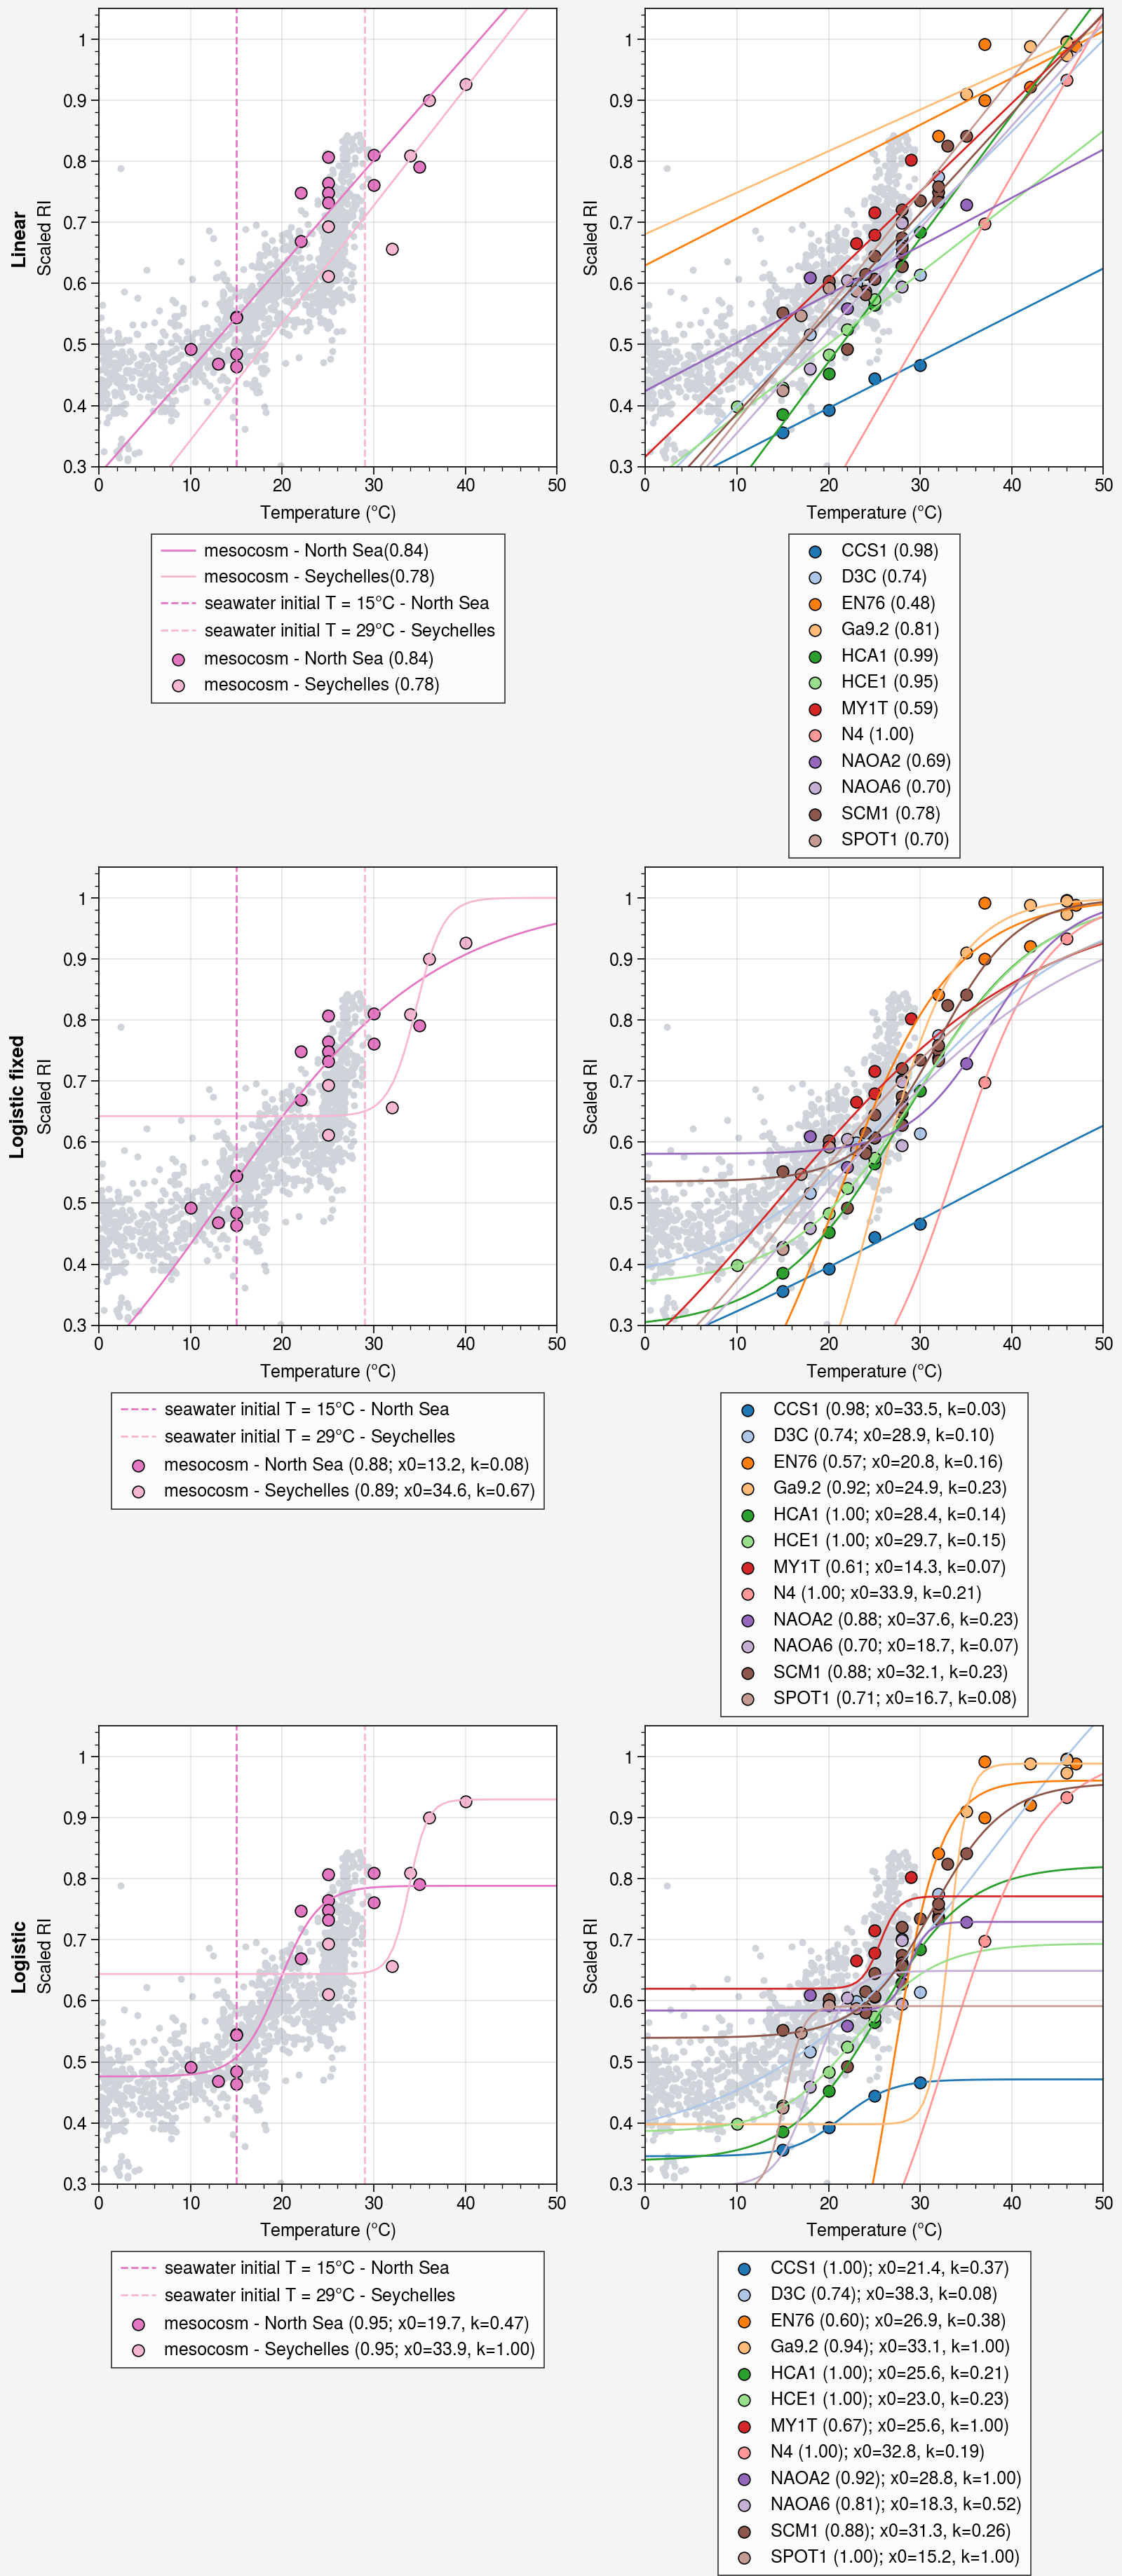

In [19]:
xx_sample = np.linspace(0, 60, 100)
fig, axs = plot.subplots(width=8,ncols=2,nrows=3,share=0)
ax = axs[0]
plot_data = culture_meso_df[culture_meso_df['Temperature']<50]
data_len_threshold = 2
strains_list = list((plot_data.groupby('Strains_edited')['Strains_edited'].count() >= data_len_threshold).index[plot_data.groupby('Strains_edited')['Strains_edited'].count() >= data_len_threshold])

new_cycler = plot.Cycle('tab20',len(strains_list))
list_new_cycler = [list(new_cycler)[i].get('color') for i in range(len(list(new_cycler)))]
strains_colordict = dict(zip(strains_list,list_new_cycler))
grouped = plot_data.groupby('Strains_edited')
for i, (name, group) in enumerate(grouped):
    if len(group) >= data_len_threshold:
        if 'mesocosm' in name:
                ## linear regression
                reg_X = group['Temperature'].values.reshape(-1, 1)
                reg_y = group['scaledRI']
                ols = LinearRegression()
                ols.fit(reg_X, reg_y)
                r2 = ols.score(reg_X, reg_y)
                y_sample = ols.predict(xx_sample.reshape(-1, 1))
                axs[0,0].plot(xx_sample, y_sample, c=strains_colordict.get(name,'gray5'), ls='-', lw=1,
                                label=name+f'({r2:.2f})')
                axs[0,0].scatter(group['Temperature'], group['scaledRI'],mec='k',
                        c=strains_colordict.get(name,'gray5'),label=name+f' ({r2:.2f})', m='o')

                ## curve fit logistic fixed
                p0_fixed = [25, 0.1, 0.1]
                bounds_fixed = (0, [50, 1, 1])
                popt_fixed, pcov_fixed = scipy.optimize.curve_fit(logistic_fixed_upper, group['Temperature'], group['scaledRI'], p0=p0_fixed, bounds=bounds_fixed)
                y_sample = logistic_fixed_upper(xx_sample, *popt_fixed)
                
                ## score for logistic fixed 
                y_residual = group['scaledRI'] - logistic_fixed_upper(group['Temperature'], *popt_fixed)
                r2 = 1 - (np.var(y_residual) / np.var(group['scaledRI']))
                fitted_x0_fixed = popt_fixed[0]
                fitted_k_fixed = popt_fixed[1]
                axs[1,0].scatter(group['Temperature'], group['scaledRI'],mec='k', 
                        c=strains_colordict.get(name,'gray5'),label=name+f' ({r2:.2f}; x0={fitted_x0_fixed:.1f}, k={fitted_k_fixed:.2f})', m='o')
                axs[1,0].plot(xx_sample, y_sample, c=strains_colordict.get(name,'gray5'), ls='-', lw=1)
                
                ## curve fit logistic 
                p0 = [25, 0.1, 0.1, 0.1]
                bounds = (0, [50, 1, 1, 1])
                popt, pcov = scipy.optimize.curve_fit(logistic, group['Temperature'], group['scaledRI'], p0=p0, 
                                                        bounds=bounds
                                                        )
                y_sample = logistic(xx_sample, *popt)

                ## score for logistic
                y_residual = group['scaledRI'] - logistic(group['Temperature'], *popt)
                r2 = 1 - (np.var(y_residual) / np.var(group['scaledRI']))
                fitted_x0 = popt[0]
                fitted_k = popt[1]
                axs[2,0].scatter(group['Temperature'], group['scaledRI'],mec='k',
                        c=strains_colordict.get(name,'gray5'),label=name+f' ({r2:.2f}; x0={fitted_x0:.1f}, k={fitted_k:.2f})', m='o')
                axs[2,0].plot(xx_sample, y_sample, c=strains_colordict.get(name,'gray5'), ls='-', lw=1)


        else:
            
                reg_X = group['Temperature'].values.reshape(-1, 1)
                reg_y = group['scaledRI']
                ols = LinearRegression()
                ols.fit(reg_X, reg_y)
                y_sample = ols.predict(xx_sample.reshape(-1, 1))
                axs[0,1].plot(xx_sample, y_sample, c=strains_colordict.get(name,'gray5'), ls='-', lw=1)
                ## score 
                r2 = ols.score(reg_X, reg_y)

                axs[0,1].scatter(group['Temperature'], group['scaledRI'],mec='k', 
                        c=strains_colordict.get(name,'gray5'),label=name+f' ({r2:.2f})', m='o')
                

                ### logistic_fixed_upper regression with curve_fit
                p0_fixed = [25, 0.1, 0.1]
                bounds_fixed = (0, [50, 1, 1])
                popt_fixed, pcov_fixed = scipy.optimize.curve_fit(logistic_fixed_upper, group['Temperature'], group['scaledRI'], p0=p0_fixed, bounds=bounds_fixed)
                y_sample = logistic_fixed_upper(xx_sample, *popt_fixed)

                fitted_x0_fixed = popt_fixed[0]
                fitted_k_fixed = popt_fixed[1]
                axs[1,1].plot(xx_sample, y_sample, c=strains_colordict.get(name,'gray5'), ls='-', lw=1)
                ## score for logistic
                y_residual = group['scaledRI'] - logistic_fixed_upper(group['Temperature'], *popt_fixed)
                r2 = 1 - (np.var(y_residual) / np.var(group['scaledRI']))
                axs[1,1].scatter(group['Temperature'], group['scaledRI'],mec='k', 
                        c=strains_colordict.get(name,'gray5'),label=name+f' ({r2:.2f}; x0={fitted_x0_fixed:.1f}, k={fitted_k_fixed:.2f})', m='o')
                
                ## curve fit logistic
                p0 = [25, 0.1, 0.1, 0.1]
                bounds = (0, [50, 1, 1, 1])
                popt, pcov = scipy.optimize.curve_fit(logistic, group['Temperature'], group['scaledRI'], p0=p0,
                                                        bounds=bounds
                                                        )
                y_sample = logistic(xx_sample, *popt)
                fitted_x0 = popt[0]
                fitted_k = popt[1]
                axs[2,1].plot(xx_sample, y_sample, c=strains_colordict.get(name,'gray5'), ls='-', lw=1)
                ## score for logistic
                y_residual = group['scaledRI'] - logistic(group['Temperature'], *popt)
                r2 = 1 - (np.var(y_residual) / np.var(group['scaledRI']))
                axs[2,1].scatter(group['Temperature'], group['scaledRI'],mec='k',
                    c=strains_colordict.get(name,'gray5'),label=name+f' ({r2:.2f}); x0={fitted_x0:.1f}, k={fitted_k:.2f})', m='o')
                

reg_mesocosm = culture_meso_df[culture_meso_df['experiment_setup']=='mesocosm'].reset_index(drop=True)
X = reg_mesocosm['Temperature'].values.reshape(-1, 1)
y = reg_mesocosm['scaledRI']
ols = LinearRegression()
ols.fit(X, y)
y_sample = ols.predict(xx_sample.reshape(-1, 1))
# axs.plot(xx_sample, y_sample, color='k', lw=1.5, label='OLS (all meso)')

### initial water temperature for mesocosm
axs[:,0].axvline(15, color=strains_colordict.get('mesocosm - North Sea'), ls='--', lw=1, label ='seawater initial T = 15$\degree$C - North Sea')
axs[:,0].axvline(29, color=strains_colordict.get(name,'mesocosm - Seychelles'), ls='--', lw=1, label ='seawater initial T = 29$\degree$C - Seychelles')

for ax in axs[:,:]:
    ax.set_xlabel('Temperature ($\degree$C)')
    ax.set_ylabel('Scaled RI')
    ax.set_xlim(0, 50)
    ax.set_ylim(-0.5, 1.05)

    h, l = ax.get_legend_handles_labels()
    ax.legend(h, loc='b', fontsize=8,ncols=1,)

# h0, l0 = axs[0].get_legend_handles_labels()
# axs[0,-1].legend(h0, loc='b', fontsize=8,ncols=1,)

# h1, l1 = axs[1].get_legend_handles_labels()
# axs[1].legend(h1, loc='b', fontsize=8,ncols=1,)

# h2, l2 = axs[2].get_legend_handles_labels()
# axs[2].legend(h2, loc='b', fontsize=8,ncols=1,)

# h3, l3 = axs[3].get_legend_handles_labels()
# axs[3].legend(h3, loc='b', fontsize=8,ncols=1,)

axs.format(ylim=(0.3,1.05),
           rowlabels=['Linear','Logistic fixed','Logistic'])

#### plot coretop T vs scaledRI
plot_x = coretop_da['t_sf2tc_avg']
plot_y = coretop_da['scaledRI_median']
axs.scatter(plot_x, plot_y, c='gray4', m='.', zorder=0)


In [ ]:
xx_sample = np.linspace(0, 60, 100)
array = [
      [1,2,3],
      [4,5,6],
      [7,0,0]
]
fig, axs = plot.subplots(array,width=12,share=0,
                         wspace=5)
ax = axs[0]
plot_data = culture_meso_df[culture_meso_df['Temperature']<50]

data_len_threshold = 0
strains_list = list((plot_data.groupby('Strains_edited')['Strains_edited'].count() >= data_len_threshold).index[plot_data.groupby('Strains_edited')['Strains_edited'].count() >= data_len_threshold])

cyc1 = plot.get_colors('tab20',15)
cyc2 = plot.get_colors('tab20b',10)
new_cycler = cyc1 + cyc2
strains_colordict = dict(zip(strains_list, new_cycler))
strains_markerdict = {
      'mesocosm - North Sea':'s',
      'mesocosm - Seychelles':'s',
}
grouped = plot_data.groupby('Strains_edited')

for i, (name, group) in enumerate(grouped):
    if len(group) >= data_len_threshold:
            ### plot cren vs cren'
            plot_x = group['fGDGT_cren']
            plot_y = group['fGDGT_cren_prime']
            axs[0,0].scatter(plot_x, plot_y, 
                  c=strains_colordict.get(name,'gray5'), mec='k',
                  m=strains_markerdict.get(name,'o'), label=name)
            
            ### plot cren vs cren'
            plot_x = group['gdgt23ratio']
            plot_y = group['Temperature']
            axs[1,0].scatter(plot_x, plot_y, 
                  c=strains_colordict.get(name,'gray5'), mec='k',
                  m=strains_markerdict.get(name,'o'), label=name)   
            
            ### plot cren vs cren'
            plot_x = group['gdgt23ratio']
            plot_y = group['TEX86']
            axs[2,0].scatter(plot_x, plot_y, 
                  c=strains_colordict.get(name,'gray5'), mec='k',
                  m=strains_markerdict.get(name,'o'), label=name) 

            ### plot gdgt23ratio vs cren'
            plot_x = group['gdgt23ratio']
            plot_y = group['fGDGT_cren_prime']
            axs[0,1].scatter(plot_x, plot_y, 
                  c=strains_colordict.get(name,'gray5'), mec='k',
                  m=strains_markerdict.get(name,'o'), label=name)
            
            ### plot gdgt23ratio vs cren'
            plot_x = group['gdgt23ratio']
            plot_y = group['fGDGT_cren']
            axs[1,1].scatter(plot_x, plot_y, 
                  c=strains_colordict.get(name,'gray5'), mec='k',
                  m=strains_markerdict.get(name,'o'), label=name)
            
            ### plot temperature vs cren'
            plot_x = group['Temperature']
            plot_y = group['fGDGT_cren_prime']
            axs[0,2].scatter(plot_x, plot_y, 
                  c=strains_colordict.get(name,'gray5'), mec='k',
                  m=strains_markerdict.get(name,'o'), label=name)
            
            ### plot temperature vs cren'
            plot_x = group['Temperature']
            plot_y = group['fGDGT_cren']
            axs[1,2].scatter(plot_x, plot_y, 
                  c=strains_colordict.get(name,'gray5'), mec='k',
                  m=strains_markerdict.get(name,'o'), label=name)
            



### plot cren vs cren'
plot_x = raw_coretop_df['fGDGT_cren']
plot_y = raw_coretop_df['fGDGT_cren_prime']
axs[0,0].scatter(plot_x, plot_y, c='gray4', m='.', zorder=0)
axs[0,0].format(
      yscale='log'
#       ylim=(-0.01, 0.15),
)

### plot cren vs cren'
plot_x = raw_coretop_df['gdgt23ratio']
plot_y = raw_coretop_df['SST']
axs[1,0].scatter(plot_x, plot_y, c='gray4', m='.', zorder=0)
axs[1,0].format(
      # xscale='log'
      xlim=(0, 20)
#       ylim=(-0.01, 0.15),
)

### plot cren vs cren'
plot_x = raw_coretop_df['gdgt23ratio']
plot_y = raw_coretop_df['TEX86']
axs[2,0].scatter(plot_x, plot_y, c='gray4', m='.', zorder=0)
axs[2,0].format(
      # xscale='log'
      xlim=(0, 20)
#       ylim=(-0.01, 0.15),
)

### plot gdgt23ratio vs cren'
plot_x = raw_coretop_df['gdgt23ratio']
plot_y = raw_coretop_df['fGDGT_cren_prime']
axs[0,1].scatter(plot_x, plot_y, c='gray4', m='.', zorder=0)
axs[0,1].format(
      yscale='log',
      xscale='log'
#       ylim=(-0.01, 0.15),
)

### plot gdgt23ratio vs cren'
plot_x = raw_coretop_df['gdgt23ratio']
plot_y = raw_coretop_df['fGDGT_cren']
axs[1,1].scatter(plot_x, plot_y, c='gray4', m='.', zorder=0)
axs[1,1].format(
      yscale='log',
      xscale='log'
#       ylim=(-0.01, 0.15),
)

### plot temperature vs cren'
plot_x = raw_coretop_df['SST']
plot_y = raw_coretop_df['fGDGT_cren_prime']
axs[0,2].scatter(plot_x, plot_y, c='gray4', m='.', zorder=0)
axs[0,2].format(
      yscale='log',
      # xscale='log'
#       ylim=(-0.01, 0.15),
#       xlim=(0, 30)
)

### plot temperature vs cren'
plot_x = raw_coretop_df['SST']
plot_y = raw_coretop_df['fGDGT_cren']
axs[1,2].scatter(plot_x, plot_y, c='gray4', m='.', zorder=0)
axs[1,2].format(
      yscale='log',
      # xscale='log'
#       ylim=(-0.01, 0.15),
#       xlim=(0, 30)
)

h,  l = axs[0,0].get_legend_handles_labels()
axs[-1].legend(h, loc='r', fontsize=8,ncols=5,
               bbox_to_anchor=(2, 0.5),)

In [ ]:
raw_coretop_df.columns

In [ ]:
xx_sample = np.linspace(0, 60, 100)
fig, axs = plot.subplots(width=12,ncols=3,nrows=2)
ax = axs[0]
plot_data = culture_meso_df[culture_meso_df['Temperature']<50]

genus_list = list((plot_data.groupby('GTDB_genus_edited')['GTDB_genus_edited'].count() >= 0).index[plot_data.groupby('GTDB_genus_edited')['GTDB_genus_edited'].count() >= 5])

new_cycler = plot.Cycle('tab20',len(genus_list))
list_new_cycler = [list(new_cycler)[i].get('color') for i in range(len(list(new_cycler)))]
genus_colordict = dict(zip(genus_list,list_new_cycler))
grouped = plot_data.groupby('GTDB_genus_edited')
for i, (name, group) in enumerate(grouped):
    if len(group) >= 5:
        if 'mesocosm' in name:

                ## linear regression
                reg_X = group['Temperature'].values.reshape(-1, 1)
                reg_y = group['scaledRI']
                ols = LinearRegression()
                ols.fit(reg_X, reg_y)
                r2 = ols.score(reg_X, reg_y)
                y_sample = ols.predict(xx_sample.reshape(-1, 1))
                axs[0,0].plot(xx_sample, y_sample, c=genus_colordict.get(name,'gray5'), ls='-', lw=1,
                                label=name+f'({r2:.2f})')
                axs[0,0].scatter(group['Temperature'], group['scaledRI'],mec='k',
                        c=genus_colordict.get(name,'gray5'),label=name+f' ({r2:.2f})', m='o')

                ## curve fit logistic fixed
                p0_fixed = [25, 0.1, 0.1]
                bounds_fixed = (0, [50, 1, 1])
                popt_fixed, pcov_fixed = scipy.optimize.curve_fit(logistic_fixed_upper, group['Temperature'], group['scaledRI'], p0=p0_fixed, bounds=bounds_fixed)
                y_sample = logistic_fixed_upper(xx_sample, *popt_fixed)
                
                ## score for logistic fixed 
                y_residual = group['scaledRI'] - logistic_fixed_upper(group['Temperature'], *popt_fixed)
                r2 = 1 - (np.var(y_residual) / np.var(group['scaledRI']))
                fitted_x0_fixed = popt_fixed[0]
                axs[0,1].scatter(group['Temperature'], group['scaledRI'],mec='k', 
                        c=genus_colordict.get(name,'gray5'),label=name+f' ({r2:.2f}; x0={fitted_x0_fixed:.1f})', m='o')
                axs[0,1].plot(xx_sample, y_sample, c=genus_colordict.get(name,'gray5'), ls='-', lw=1)
                
                ## curve fit logistic 
                p0 = [25, 0.1, 0.1, 0.1]
                bounds = (0, [50, 1, 1, 1])
                popt, pcov = scipy.optimize.curve_fit(logistic, group['Temperature'], group['scaledRI'], p0=p0, 
                                                        bounds=bounds
                                                        )
                y_sample = logistic(xx_sample, *popt)

                ## score for logistic
                y_residual = group['scaledRI'] - logistic(group['Temperature'], *popt)
                r2 = 1 - (np.var(y_residual) / np.var(group['scaledRI']))
                fitted_x0 = popt[0]
                axs[0,2].scatter(group['Temperature'], group['scaledRI'],mec='k',
                        c=genus_colordict.get(name,'gray5'),label=name+f' ({r2:.2f}; x0={fitted_x0:.1f})', m='o')
                axs[0,2].plot(xx_sample, y_sample, c=genus_colordict.get(name,'gray5'), ls='-', lw=1)
        else:
            
                reg_X = group['Temperature'].values.reshape(-1, 1)
                reg_y = group['scaledRI']
                ols = LinearRegression()
                ols.fit(reg_X, reg_y)
                y_sample = ols.predict(xx_sample.reshape(-1, 1))
                axs[1,0].plot(xx_sample, y_sample, c=genus_colordict.get(name,'gray5'), ls='-', lw=1)
                ## score 
                r2 = ols.score(reg_X, reg_y)

                axs[1,0].scatter(group['Temperature'], group['scaledRI'],mec='k', 
                        c=genus_colordict.get(name,'gray5'),label=name+f' ({r2:.2f})', m='o')
                

                ### logistic_fixed_upper regression with curve_fit
                p0_fixed = [25, 0.1, 0.1]
                bounds_fixed = (0, [50, 1, 1])
                popt_fixed, pcov_fixed = scipy.optimize.curve_fit(logistic_fixed_upper, group['Temperature'], group['scaledRI'], p0=p0_fixed, bounds=bounds_fixed)
                y_sample = logistic_fixed_upper(xx_sample, *popt_fixed)

                fitted_x0_fixed = popt_fixed[0]
                axs[1,1].plot(xx_sample, y_sample, c=genus_colordict.get(name,'gray5'), ls='-', lw=1)
                ## score for logistic
                y_residual = group['scaledRI'] - logistic_fixed_upper(group['Temperature'], *popt_fixed)
                r2 = 1 - (np.var(y_residual) / np.var(group['scaledRI']))
                axs[1,1].scatter(group['Temperature'], group['scaledRI'],mec='k', 
                        c=genus_colordict.get(name,'gray5'),label=name+f' ({r2:.2f}; x0={fitted_x0_fixed:.1f})', m='o')
                
                ## curve fit logistic
                p0 = [25, 0.1, 0.1, 0.1]
                bounds = (0, [50, 1, 1, 1])
                popt, pcov = scipy.optimize.curve_fit(logistic, group['Temperature'], group['scaledRI'], p0=p0,
                                                        bounds=bounds
                                                        )
                y_sample = logistic(xx_sample, *popt)
                fitted_x0 = popt[0]
                axs[1,2].plot(xx_sample, y_sample, c=genus_colordict.get(name,'gray5'), ls='-', lw=1)
                ## score for logistic
                y_residual = group['scaledRI'] - logistic(group['Temperature'], *popt)
                r2 = 1 - (np.var(y_residual) / np.var(group['scaledRI']))
                axs[1,2].scatter(group['Temperature'], group['scaledRI'],mec='k',
                    c=genus_colordict.get(name,'gray5'),label=name+f' ({r2:.2f}); x0={fitted_x0:.1f})', m='o')
            
reg_mesocosm = culture_meso_df[culture_meso_df['experiment_setup']=='mesocosm'].reset_index(drop=True)
X = reg_mesocosm['Temperature'].values.reshape(-1, 1)
y = reg_mesocosm['scaledRI']
ols = LinearRegression()
ols.fit(X, y)
y_sample = ols.predict(xx_sample.reshape(-1, 1))
# axs.plot(xx_sample, y_sample, color='k', lw=1.5, label='OLS (all meso)')

### initial water temperature for mesocosm
axs[0,:].axvline(15, color=genus_colordict.get('mesocosm - North Sea'), ls='--', lw=1, label ='seawater initial T = 15$\degree$C - North Sea')
axs[0,:].axvline(29, color=genus_colordict.get('mesocosm - Seychelles'), ls='--', lw=1, label ='seawater initial T = 29$\degree$C - Seychelles')

for ax in axs:
    ax.set_xlabel('Temperature ($\degree$C)')
    ax.set_ylabel('Scaled RI')
    ax.set_xlim(0, 60)
    ax.set_ylim(-0.5, 1.05)

    h, l = ax.get_legend_handles_labels()
    ax.legend(h, loc='b', fontsize=8,ncols=1,)

# h0, l0 = axs[0].get_legend_handles_labels()
# axs[0,-1].legend(h0, loc='b', fontsize=8,ncols=1,)

# h1, l1 = axs[1].get_legend_handles_labels()
# axs[1].legend(h1, loc='b', fontsize=8,ncols=1,)

# h2, l2 = axs[2].get_legend_handles_labels()
# axs[2].legend(h2, loc='b', fontsize=8,ncols=1,)

# h3, l3 = axs[3].get_legend_handles_labels()
# axs[3].legend(h3, loc='b', fontsize=8,ncols=1,)

axs.format(ylim=(0.3,1.05),)

#### plot coretop T vs scaledRI
plot_x = coretop_da['t_sf2tc_avg']
plot_y = coretop_da['scaledRI_median']
axs.scatter(plot_x, plot_y, c='gray4', m='.', zorder=0)

In [ ]:
plot_data = culture_meso_df[culture_meso_df['Temperature']<50]

# Get strains with at least 5 occurrences
strain_counts = plot_data['Strains_edited'].value_counts()
strains_list = strain_counts[strain_counts >= 5].index.tolist()


plot_data_filtered = plot_data[plot_data['Strains_edited'].isin(strains_list)].reset_index(drop=True)
plot_data_filtered.groupby(['Strains_edited','Source','NCBI_family']).size().sort_values(ascending=False).reset_index(name='counts')

In [ ]:
plot_data = culture_meso_df[culture_meso_df['Temperature']<50][
    culture_meso_df['Source']!='Varma et al. (2024) Biogeosciences']

# Get strains with at least 5 occurrences
strain_counts = plot_data['Strains_edited'].value_counts()
strains_list = strain_counts[strain_counts >= 5].index.tolist()


plot_data_filtered = plot_data[plot_data['Strains_edited'].isin(strains_list)].reset_index(drop=True)

# Define the known optimal temperature ranges for each strain
optimal_temp_ranges = {
    ### information from BacDive bacdive.dsmz.de
    'D3C': (15, 32, 37), ## Elling et al (unpublished) | Bayer et al. 2019 (https://www.microbiologyresearch.org/content/journal/ijsem/10.1099/ijsem.0.003360)
    'EN76': (28, 42, 47), ## N. viennensis | Elling et al (unpublished) | Stieglmeier et al. 2014 (https://www.microbiologyresearch.org/content/journal/ijsem/10.1099/ijs.0.063172-0), Tourna et al. 2011 (PNAS; https://www.pnas.org/doi/10.1073/pnas.1013488108#fig01)
    'Ga9.2': (30, 46, 55), ## N. Gargensis | Pitcher et al. (2010), Elling et al. (2017) | Chow et al. (2018) (https://www.nature.com/articles/s41598-018-32059-0#:~:text=The%20carboxylesterase%20was%20mostly%20active,(%E2%88%BC46%20%C2%B0C).)
    'HCA1': (10, 25, 30), ## Qin et al. (2015) PNAS | Bayer et al. 2019 (https://www.microbiologyresearch.org/content/journal/ijsem/10.1099/ijsem.0.003360)
    'HCE1': (4, 25, 30), ## Qin et al. (2015) PNAS | Bayer et al. 2019 (https://www.microbiologyresearch.org/content/journal/ijsem/10.1099/ijsem.0.003360)
    'MY1T': (20, 25,30), ## Jung et al. (2011) GDGT and growth conditions
    # 'NAOA2': (25, 35), ## 
    'SCM1': (15, 32, 35), ## Elling et al. (2015) GCA & Qin et al. (2015) PNAS  | Bayer et al. 2019 (https://www.microbiologyresearch.org/content/journal/ijsem/10.1099/ijsem.0.003360)
    'mesocosm - North Sea': (15, 32, 35), ## Assuming close to SCM1 based on phylogenetic tree of Wuchter et al. (2004) PNAS
    'mesocosm - Seychelles': (15, 32, 35),  ## Assuming close to SCM1 based on phylogenetic tree of Schouten et al. (2007) Organic Geochemistry
}
# Get unique strains in the correct plotting order
strain_order = plot_data_filtered['Strains_edited'].unique()

fig, axs = plot.subplots(figsize=(6,6))
ax = axs[0]

sns.stripplot(data=plot_data_filtered, x='Temperature', y='Strains_edited', 
              hue='Strains_edited', palette=strains_colordict, legend=False,
              ax=ax)
sns.boxplot(data=plot_data_filtered, x='Temperature', y='Strains_edited', 
            color='white', ax=ax, linewidth=1, fliersize=0,
            width=0.25)

# Add horizontal bars for optimal temperature ranges
for strain, (temp_min, temp_opt, temp_max) in optimal_temp_ranges.items():
    if strain in strain_order:  # Ensure the strain exists in the filtered data
        y_pos = np.where(strain_order == strain)[0][0]  # Find index in strain_order
        ax.plot([temp_min, temp_opt, temp_max], [y_pos+0.35, y_pos+0.35, y_pos+0.35], m='o', ls='-', c='gray5', lw=2, label='Optimal T range')


### add 'source' from the dataframe to each line


ax.format(
    yticks=np.arange(0, len(plot_data_filtered['Strains_edited'].unique()) + 0.5, 1),
    yticklabels=list(plot_data_filtered['Strains_edited'].unique()),
    ytickminor=False,
    xlabel='Incubation Temperature ($\degree$C)',
    ylabel='Archaeal Strain',
    xlim=(0, 60),
    ylim=(-0.2, len(plot_data_filtered['Strains_edited'].unique()) + 0.2),
)

h, l = ax.get_legend_handles_labels()
ax.legend(h[0], 'Reported growth T range [min-optimal-max]', loc='ur', fontsize=8,ncols=1, title_fontsize=8)



In [ ]:
SCM1_df = culture_meso_df[culture_meso_df['Strains']=='SCM1'].reset_index(drop=True)
SCM1_df

# 4. Build culRI-Bayesian model

## 4.1 Layer 1: Build the base model of RI vs temperature based on culture+mesocosm data

In [ ]:
# build the base model from culture data using Bayesian stats on hyperparameters of logistic regression using pystan

import numpy as np
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel



culture_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='culture'].reset_index(drop=True)
meso_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='mesocosm'].reset_index(drop=True)

x1 = culture_data_full['Temperature'].astype(float).tolist() 
y1 = culture_data_full['scaledRI'].astype(float).tolist() 

x2 = meso_data_full['Temperature'].astype(float).tolist()
y2 = meso_data_full['scaledRI'].astype(float).tolist()
# Save data for Stan
data = {
    "N_cul": len(culture_data_full),
    "t_cul": x1,
    "scaledRI_cul": y1,
    "N_meso": len(meso_data_full),
    "t_meso": x2,
    "scaledRI_meso": y2,

}

# Compile the model (ensure the .stan file is in the same directory)
model = CmdStanModel(stan_file=os.path.join(stan_models_path, "jnt_cul_meso.stan"))

# Fit the model
fit = model.sample(data=data, 
                   chains=4, 
                   iter_warmup=500, 
                   iter_sampling=1000, 
                   seed=42,
                   parallel_chains=4,
                   show_console=True)

# Extract results
summary = fit.summary()
print(summary)



# extract the shared parameters
x0_post_joint_cul_meso = fit.stan_variable("t0_culmeso")
k_post_joint_cul_meso  = fit.stan_variable("k_culmeso")
b_post_joint_cul_meso  = fit.stan_variable("b_culmeso")

# extract the noise parameters
sigma1_post_joint_cul_meso = fit.stan_variable("sigma_scaledRI_cul")
sigma2_post_joint_cul_meso = fit.stan_variable("sigma_scaledRI_meso")

# if you also want the ratio you computed
sigma_ratio_joint_cul_meso = fit.stan_variable("sigma_scaledRI_culmeso")

In [ ]:
import numpy as np
from scipy.stats import truncnorm

np.random.seed(42)

# --- 1) set up
n_samples = len(x0_post_joint_cul_meso)    # e.g. 4000
x_sample  = np.linspace(-4, 50, 100)

# containers for predicted curves
pred1      = np.zeros((n_samples, x_sample.size))
pred1_noisy= np.zeros_like(pred1)
pred2      = np.zeros_like(pred1)
pred2_noisy= np.zeros_like(pred1)

# --- 2) draw posterior logistic curves
for i in range(n_samples):
    x0 = x0_post_joint_cul_meso[i]
    k  = k_post_joint_cul_meso[i]
    b  = b_post_joint_cul_meso[i]
    s1 = sigma1_post_joint_cul_meso[i]
    s2 = sigma2_post_joint_cul_meso[i]

    mu    = (1 - b) / (1 + np.exp(-k * (x_sample - x0))) + b
    pred1[i]       = mu
    pred1_noisy[i] = np.random.normal(mu, s1)
    pred2[i]       = mu
    pred2_noisy[i] = np.random.normal(mu, s2)

# compute medians & intervals
p50_1, p5_1,  p95_1  = np.percentile(pred1,  [50, 5, 95], axis=0)
p50_2, p5_2,  p95_2  = np.percentile(pred2,  [50, 5, 95], axis=0)

# --- 3) mosaic subplots
mosaic = [[1,2,3],
          [4,5,6],]
fig, axs = plot.subplots(mosaic, share=0, width=10)
# panel 2–5: priors vs posteriors
## x0
ax = axs[0]
# prior
mu, sig = 20, 20
low, up = -4, np.inf
a, b    = (low-mu)/sig, (up-mu)/sig
x0_prior= truncnorm.rvs(a, b, loc=mu, scale=sig, size=10_000)
ax.hist(x0_prior, bins=50, density=True, histtype='step',
        c='k', lw=2, label='prior')
# posterior
ax.hist(x0_post_joint_cul_meso, bins=50, density=True, 
        c='gray7', alpha=0.5, label='posterior')
p50 = np.percentile(x0_post_joint_cul_meso, 50)
ax.axvline(p50, color='gray7', label='P50')

ax.set_title('x0')
ax.format(urtitle=f'mu_p50 = {p50:.2f}')

## k
ax = axs[1]
k_prior = np.random.normal(0, 0.25, 10_000)
ax.hist(k_prior, bins=50, density=True, histtype='step',
        c='k', lw=2, label='prior')
ax.hist(k_post_joint_cul_meso,   bins=50, density=True, 
        c='gray7', alpha=0.5, label='posterior')
p50 = np.percentile(k_post_joint_cul_meso, 50)
ax.axvline(p50, color='gray7', label='P50')
ax.set_title('k')
ax.format(urtitle=f'k_p50 = {p50:.2f}')

## b
ax = axs[2]
b_prior = np.random.beta(2, 5, 10_000)
ax.hist(b_prior, bins=50, density=True, histtype='step',
        c='k', lw=2, label='prior')
ax.hist(b_post_joint_cul_meso,  bins=50, density=True, 
        c='gray7', alpha=0.5, label='posterior')
p50 = np.percentile(b_post_joint_cul_meso, 50)
ax.axvline(p50, color='gray7', label='P50')
ax.set_title('b')
ax.format(urtitle=f'b_p50 = {p50:.2f}')

## sigma1 & sigma2
ax = axs[3]
# prior
mu, sig = 0.01, 0.1
low, up = 0.01, np.inf
a, b    = (low-mu)/sig, (up-mu)/sig
sig_prior = truncnorm.rvs(a, b, loc=mu, scale=sig, size=10_000)
ax.hist(sig_prior, bins=50, density=True, histtype='step',
        c='k', lw=2, label='prior')
# posteriors
ax.hist(sigma1_post_joint_cul_meso, bins=50, density=True, 
        c='yellow7', alpha=0.5, label='σ1 post')
ax.hist(sigma2_post_joint_cul_meso, bins=50, density=True, 
        c='teal7', alpha=0.5, label='σ2 post')
p50_s1 = np.percentile(sigma1_post_joint_cul_meso, 50)
p50_s2 = np.percentile(sigma2_post_joint_cul_meso, 50)
ax.axvline(p50_s1, color='yellow7', label=f'P50 σ1 ({p50_s1:.2f})')
ax.axvline(p50_s2, color='teal7', label=f'P50 σ2 ({p50_s2:.2f})')
h, l = ax.get_legend_handles_labels()
ax.legend(h[:2], l[:2], loc='ur', fontsize=8,ncols=1)
ax.set_title('σ')

### Scatter data
# scatter the two data sets
axs[-2:].scatter(x1, y1, marker='o', mec='k', label="Culture Group 1.1a", color="yellow9")
axs[-2:].scatter(x2, y2, marker='o', mec='k', label="Mesocosm", color="teal9")

# median lines
axs[-2:].plot(x_sample, p50_1, c='k', lw=2, label="P50 curve fit")
# ax.plot(x_sample, p50_2, linestyle="-.", lw=2, label="P50 DS2")

axs[-2:].set_xlabel('Temperature (°C)')
axs[-2:].set_ylabel('Scaled RI')
axs[-2:].set_ylim([0.1,1.1])

# panel 1: fitted curves + data
ax = axs[4]

len_random = 20
# dataset 1 posterior
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred1[idx], 
                color="yellow7", lw=0.5, zorder=0,
                label="Culture posterior")
    else:
        ax.plot(x_sample, pred1[idx], 
                color="yellow7", lw=0.5, zorder=0)


# dataset 1 noisy
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred1_noisy[idx], 
                color="k", lw=0.25, alpha=0.5, zorder=0,
                label="Culture + noise")
    else:
        ax.plot(x_sample, pred1_noisy[idx], 
                color="k", lw=0.25, alpha=0.5, zorder=0)
    
ax = axs[5]
# dataset 2 posterior ## the same as dataset 1 posterior
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred2[idx], 
                color="teal9", lw=0.5, zorder=0,
                label="Mesocosm posterior")
    else:
        ax.plot(x_sample, pred2[idx],
                color="teal9", lw=0.5, zorder=0)


  
# dataset 2 noisy
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred2_noisy[idx], 
                color="k", lw=0.25, alpha=0.5, zorder=0,
                label="Mesocosm + noise")
    else:
        ax.plot(x_sample, pred2_noisy[idx], 
                color="k", lw=0.25, alpha=0.5, zorder=0)



### legend for last two panels
h, l = axs[-2].get_legend_handles_labels()
axs[-2].legend(h, l, loc='b', fontsize=8, ncols=1)
axs[-2].set_title('Posterior curve with culture noise')
### legend for last two panels
h, l = axs[-1].get_legend_handles_labels()
axs[-1].legend(h, l, loc='b', fontsize=8, ncols=1)
axs[-1].set_title('Posterior curve with mesocosm noise')

# # legends & layout
# for axi in axs.values() if hasattr(axs, 'values') else axs.flat:
#     axi.legend(fontsize=6)

fig.suptitle('Bayesian joint logistic S‐curve fit\nY = (1-b)/(1 + exp(-k * (x_{sample}-x0)) + b', weight='bold')
fig.tight_layout()


In [ ]:
# build the base model from culture data using Bayesian stats on hyperparameters of logistic regression using pystan
import numpy as np
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel



culture_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='culture'].reset_index(drop=True)
meso_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='mesocosm'].reset_index(drop=True)
coretop_data_full = raw_coretop_df[raw_coretop_df['QC_flag']=='include'].dropna(how='any',
                                                                                subset=['scaledRI','thermocline_T_depthIntegral']
                                                                                ).reset_index(drop=True)


x1 = culture_data_full['Temperature'].astype(float).tolist() 
y1 = culture_data_full['scaledRI'].astype(float).tolist() 

x2 = meso_data_full['Temperature'].astype(float).tolist()
y2 = meso_data_full['scaledRI'].astype(float).tolist()

x3 = coretop_data_full['thermocline_T_depthIntegral'].astype(float).tolist()
y3 = coretop_data_full['scaledRI'].astype(float).tolist()
# Save data for Stan
data = {
    "N1": len(culture_data_full),
    "x1": x1,
    "y1": y1,
    "N2": len(meso_data_full),
    "x2": x2,
    "y2": y2,
    "N3": len(coretop_data_full),
    "x3": x3,
    "y3": y3,

}

# Compile the model (ensure the .stan file is in the same directory)
model = CmdStanModel(stan_file=os.path.join(stan_models_path, "joint_culture_meso_coretop.stan"))

# Fit the model
fit = model.sample(data=data, 
                   chains=4, 
                   iter_warmup=500, 
                   iter_sampling=1000, 
                   seed=42,
                   parallel_chains=4,
                   show_console=True)

# Extract results
summary = fit.summary()
print(summary)


# extract the shared parameters
x0_post = fit.stan_variable("x0")
k_post  = fit.stan_variable("k")
b_post  = fit.stan_variable("b")

# extract the noise parameters
sigma1_post = fit.stan_variable("sigma1")
sigma2_post = fit.stan_variable("sigma2")
sigma3_post = fit.stan_variable("sigma3")

# if you also want the ratio you computed
sigma21_ratio = fit.stan_variable("sigma2_sigma1")
sigma31_ratio = fit.stan_variable("sigma3_sigma1")


In [ ]:
import numpy as np
from scipy.stats import truncnorm

np.random.seed(42)

# --- 1) set up
n_samples = len(x0_post)    # e.g. 4000
x_sample  = np.linspace(-4, 50, 100)

# containers for predicted curves
pred1      = np.zeros((n_samples, x_sample.size))
pred1_noisy= np.zeros_like(pred1)
pred2      = np.zeros_like(pred1)
pred2_noisy= np.zeros_like(pred1)
pred3      = np.zeros_like(pred1)
pred3_noisy= np.zeros_like(pred1)

# --- 2) draw posterior logistic curves
for i in range(n_samples):
    x0 = x0_post[i]
    k  = k_post[i]
    b  = b_post[i]
    s1 = sigma1_post[i]
    s2 = sigma2_post[i]
    s3 = sigma3_post[i]
    

    mu    = (1 - b) / (1 + np.exp(-k * (x_sample - x0))) + b
    pred1[i]       = mu
    pred1_noisy[i] = np.random.normal(mu, s1)
    pred2[i]       = mu
    pred2_noisy[i] = np.random.normal(mu, s2)
    pred3[i]       = mu
    pred3_noisy[i] = np.random.normal(mu, s3)
    

# compute medians & intervals
p50_1, p5_1,  p95_1  = np.percentile(pred1,  [50, 5, 95], axis=0)
p50_2, p5_2,  p95_2  = np.percentile(pred2,  [50, 5, 95], axis=0)
p50_3, p5_3,  p95_3  = np.percentile(pred3,  [50, 5, 95], axis=0)

# --- 3) mosaic subplots
mosaic = [[1,2,3],
          [4,5,6],
          [0,7,0]]
fig, axs = plot.subplots(mosaic, share=0, width=10)
# panel 2–5: priors vs posteriors
## x0
ax = axs[0]
# prior
mu, sig = 20, 20
low, up = -4, np.inf
a, b    = (low-mu)/sig, (up-mu)/sig
x0_prior= truncnorm.rvs(a, b, loc=mu, scale=sig, size=10_000)
ax.hist(x0_prior, bins=50, density=True, histtype='step',
        c='k', lw=2, label='prior')
# posterior
ax.hist(x0_post, bins=50, density=True, 
        c='gray7', alpha=0.5, label='posterior\n(joint-cul-meso-coretop)')
ax.hist(x0_post_joint_cul_meso, bins=50, density=True,
        c='gray7', histtype='step', label='posterior\n(joint-cul-meso)')
p50 = np.percentile(x0_post, 50)
ax.axvline(p50, color='gray7', label='P50')
ax.format(ultitle=f'x0_p50 = {p50:.2f}')

## k
ax = axs[1]
k_prior = np.random.normal(0, 0.25, 10_000)
ax.hist(k_prior, bins=50, density=True, histtype='step',
        c='k', lw=2, label='prior')
ax.hist(k_post,   bins=50, density=True, 
        c='gray7', alpha=0.5, label='posterior\n(joint-cul-meso-coretop)')
ax.hist(k_post_joint_cul_meso, bins=50, density=True,
        c='gray7', histtype='step', label='posterior\n(joint-cul-meso)')
p50 = np.percentile(k_post, 50)
ax.axvline(p50, color='gray7', label='P50')
ax.format(ultitle=f'k_p50 = {p50:.2f}')
h, l = ax.get_legend_handles_labels()
ax.legend(h, l, loc='t', fontsize=8, ncols=len(h))
## b
ax = axs[2]
b_prior = np.random.beta(2, 5, 10_000)
ax.hist(b_prior, bins=50, density=True, histtype='step',
        c='k', lw=2, label='prior')
ax.hist(b_post,  bins=50, density=True, 
        c='gray7', alpha=0.5, label='posterior\n(joint-cul-meso-coretop)')
ax.hist(b_post_joint_cul_meso, bins=50, density=True,
        c='gray7', histtype='step', label='posterior\n(joint-cul-meso)')
p50 = np.percentile(b_post, 50)
ax.axvline(p50, color='gray7', label='P50')
ax.format(ultitle=f'b_p50 = {p50:.2f}')


## sigma1 & sigma2 & sigma3
ax = axs[3]
# prior
mu, sig = 0.01, 0.1
low, up = 0.01, np.inf
a, b    = (low-mu)/sig, (up-mu)/sig
sig_prior = truncnorm.rvs(a, b, loc=mu, scale=sig, size=10_000)
ax.hist(sig_prior, bins=50, density=True, histtype='step',
        c='k', lw=2, label='prior')
# posteriors
ax.hist(sigma1_post, bins=50, density=True, 
        c='yellow7', alpha=0.5, label='σ1 post')
ax.hist(sigma2_post, bins=50, density=True, 
        c='teal7', alpha=0.5, label='σ2 post')
ax.hist(sigma3_post, bins=50, density=True,
        c='blue7', alpha=0.5, label='σ3 post')
p50_s1 = np.percentile(sigma1_post, 50)
p50_s2 = np.percentile(sigma2_post, 50)
p50_s3 = np.percentile(sigma3_post, 50)
ax.axvline(p50_s1, color='yellow7', label=f'P50 σ1 ({p50_s1:.2f})')
ax.axvline(p50_s2, color='teal7', label=f'P50 σ2 ({p50_s2:.2f})')
ax.axvline(p50_s3, color='blue7', label=f'P50 σ3 ({p50_s3:.2f})')
h, l = ax.get_legend_handles_labels()
ax.legend(h[:2], l[:2], loc='ur', fontsize=8,ncols=1)
ax.set_title('σ')

### Scatter data
# scatter the two data sets
axs[-3:].scatter(x1, y1, marker='o', mec='k', label="Culture Group 1.1a", color="yellow9")
axs[-3:].scatter(x2, y2, marker='o', mec='k', label="Mesocosm", color="teal9")
axs[-3:].scatter(x3, y3, marker='.', label="Coretop", color="blue9", zorder=0)

# median lines
axs[-3:].plot(x_sample, p50_1, c='k', lw=1, label="P50 curve fit")
# ax.plot(x_sample, p50_2, linestyle="-.", lw=2, label="P50 DS2")

axs[-3:].set_xlabel('Temperature (°C)')
axs[-3:].set_ylabel('Scaled RI')
axs[-3:].set_ylim([0.1,1.1])

# panel 1: fitted curves + data
ax = axs[4]

len_random = 20
# dataset 1 posterior
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred1[idx], 
                color="yellow7", lw=0.5, zorder=0,
                label="Culture posterior")
    else:
        ax.plot(x_sample, pred1[idx], 
                color="yellow7", lw=0.5, zorder=0)

# dataset 1 noisy
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred1_noisy[idx], 
                color="k", lw=0.25, alpha=0.5, zorder=0,
                label="Culture + noise")
    else:
        ax.plot(x_sample, pred1_noisy[idx], 
                color="k", lw=0.25, alpha=0.5, zorder=0)
    
ax = axs[5]
# dataset 2 posterior ## the same as dataset 1 posterior
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred2[idx], 
                color="teal9", lw=0.5, zorder=0,
                label="Mesocosm posterior")
    else:
        ax.plot(x_sample, pred2[idx],
                color="teal9", lw=0.5, zorder=0)

# dataset 2 noisy
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred2_noisy[idx], 
                color="k", lw=0.25, alpha=0.5, zorder=0,
                label="Mesocosm + noise")
    else:
        ax.plot(x_sample, pred2_noisy[idx], 
                color="k", lw=0.25, alpha=0.5, zorder=0)

ax = axs[6]
# dataset 3 posterior ## the same as dataset 1 posterior
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred3[idx], 
                color="blue7", lw=0.5, zorder=0,
                label="Coretop posterior")
    else:
        ax.plot(x_sample, pred3[idx],
                color="blue7", lw=0.5, zorder=0)
        
# dataset 3 noisy
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred3_noisy[idx], 
                color="k", lw=0.25, alpha=0.5, zorder=0,
                label="Coretop + noise")
    else:
        ax.plot(x_sample, pred3_noisy[idx], 
                color="k", lw=0.25, alpha=0.5, zorder=0)


### legend for last three panels
h, l = axs[-2].get_legend_handles_labels()
axs[-2].legend(h, l, loc='b', fontsize=8, ncols=1)
axs[-2].set_title('Posterior curve with culture noise')

h, l = axs[-1].get_legend_handles_labels()
axs[-1].legend(h[2], l[2], loc='lr', fontsize=8, ncols=1)
axs[-1].set_title('Posterior curve with mesocosm noise')
h, l = axs[-3].get_legend_handles_labels()
axs[-3].legend(h[2], l[2], loc='lr', fontsize=8, ncols=1)
axs[-3].set_title('Posterior curve with mesocosm noise')

axs[:-3].set_yscale('log')

# # legends & layout
# for axi in axs.values() if hasattr(axs, 'values') else axs.flat:
#     axi.legend(fontsize=6)

fig.suptitle('Bayesian joint logistic S‐curve fit\nY = (1-b)/(1 + exp(-k * (x_{sample}-x0)) + b', weight='bold')
fig.tight_layout()


In [ ]:
# build the base model from culture data using Bayesian stats on hyperparameters of logistic regression using pystan

import numpy as np
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel



culture_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='culture'].reset_index(drop=True)
meso_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='mesocosm'].reset_index(drop=True)
coretop_data_full = raw_coretop_df[raw_coretop_df['QC_flag']=='include'].dropna(how='any',
                                                                                subset=['scaledRI',
                                                                                        'thermocline_T_depthIntegral',
                                                                                        'gdgt23ratio']
                                                                                ).reset_index(drop=True)


x1 = culture_data_full['Temperature'].astype(float).tolist() 
y1 = culture_data_full['scaledRI'].astype(float).tolist() 

x2 = meso_data_full['Temperature'].astype(float).tolist()
y2 = meso_data_full['scaledRI'].astype(float).tolist()

x3 = coretop_data_full['thermocline_T_depthIntegral'].astype(float).tolist()
y3 = coretop_data_full['scaledRI'].astype(float).tolist()
z3 = coretop_data_full['gdgt23ratio'].astype(float).tolist()
# Save data for Stan
data = {
    "N1": len(culture_data_full),
    "x1": x1,
    "y1": y1,
    "N2": len(meso_data_full),
    "x2": x2,
    "y2": y2,
    "N3": len(coretop_data_full),
    "x3": x3,
    "y3": y3,
    "z3": z3,

}

# Compile the model (ensure the .stan file is in the same directory)
model = CmdStanModel(stan_file=os.path.join(stan_models_path, "joint_culture_meso_coretop_multivariate.stan"))

# Fit the model
fit = model.sample(data=data, 
                   chains=4, 
                   iter_warmup=500, 
                   iter_sampling=1000, 
                   seed=42,
                   parallel_chains=4,
                   show_console=True)

# Extract results
summary = fit.summary()
print(summary)


# extract the shared parameters
x0_post_joint_cul_meso_coretop_multiv = fit.stan_variable("x0")
k_post_joint_cul_meso_coretop_multiv  = fit.stan_variable("k")
b_post_joint_cul_meso_coretop_multiv  = fit.stan_variable("b")
beta0_post_joint_cul_meso_coretop_multiv = fit.stan_variable("beta0")
beta1_post_joint_cul_meso_coretop_multiv = fit.stan_variable("beta1")


# extract the noise parameters
sigma1_post_joint_cul_meso_coretop_multiv = fit.stan_variable("sigma1")
sigma2_post_joint_cul_meso_coretop_multiv = fit.stan_variable("sigma2")
sigma3_post_joint_cul_meso_coretop_multiv = fit.stan_variable("sigma3")

# if you also want the ratio you computed
sigma21_ratio_joint_cul_meso_coretop_multiv = fit.stan_variable("sigma2_sigma1")
sigma31_ratio_joint_cul_meso_coretop_multiv = fit.stan_variable("sigma3_sigma1")


In [ ]:
np.random.seed(42)

# --- 1) set up
n_samples = len(x0_post)    # e.g. 4000
x_sample = np.linspace(-4, 50, 100)
z_sample = np.linspace(0, 30, 100)
len_random = 20

pred_mu = (
    (1 - b_post_joint_cul_meso_coretop_multiv[:,None]) 
    / (1 + np.exp(-k_post_joint_cul_meso_coretop_multiv[:,None] 
                  * (x_sample[None,:] - x0_post_joint_cul_meso_coretop_multiv[:,None]))) 
    + b_post_joint_cul_meso_coretop_multiv[:,None])

pred_mu_multiv = (
    ((1 - b_post_joint_cul_meso_coretop_multiv[:,None])
    / (1 + np.exp(-k_post_joint_cul_meso_coretop_multiv[:,None]
                    * (x_sample[None,:] - x0_post_joint_cul_meso_coretop_multiv[:,None])))
    + b_post_joint_cul_meso_coretop_multiv[:,None])
    + beta1_post_joint_cul_meso_coretop_multiv[:,None]
    + beta0_post_joint_cul_meso_coretop_multiv[:,None] * z_sample[None,:])

pred_mu_noisy1 = np.random.normal(pred_mu, sigma1_post_joint_cul_meso_coretop_multiv[:,None])
pred_mu_noisy2 = np.random.normal(pred_mu, sigma2_post_joint_cul_meso_coretop_multiv[:,None])
pred_mu_noisy3 = np.random.normal(pred_mu, sigma3_post_joint_cul_meso_coretop_multiv[:,None])

pred_mu_noisy1_multiv = np.random.normal(pred_mu_multiv, sigma1_post_joint_cul_meso_coretop_multiv[:,None])
pred_mu_noisy2_multiv = np.random.normal(pred_mu_multiv, sigma2_post_joint_cul_meso_coretop_multiv[:,None])
pred_mu_noisy3_multiv = np.random.normal(pred_mu_multiv, sigma3_post_joint_cul_meso_coretop_multiv[:,None])


array = [
    [1,2,3],
    [0,0,4],
    [0,0,5],
]
fig, axs = plot.subplots(array,share=0)

## plot posterior mu1
ax = axs[0]

len_random = 20
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred_mu_noisy1[idx], 
                color="yellow7", lw=0.5, zorder=0,
                label="Culture posterior")
    else:
        ax.plot(x_sample, pred_mu_noisy1[idx], 
                color="yellow7", lw=0.5, zorder=0)
        

p50_mu1, p5_mu1,  p95_mu1  = np.percentile(pred_mu,  [50, 5, 95], axis=0)
ax.plot(x_sample, p50_mu1, c='k', lw=2, label="P50 curve fit")

### plot scatter x, y
ax.scatter(x1, y1, marker='o', c='k', label="Culture Group 1.1a")

## plot posterior mu2
ax = axs[1]
len_random = 20
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred_mu_noisy2[idx], 
                color="teal7", lw=0.5, zorder=0,
                label="Mesocosm posterior")
    else:
        ax.plot(x_sample, pred_mu_noisy2[idx],
                color="teal7", lw=0.5, zorder=0)

p50_mu2, p5_mu2,  p95_mu2  = np.percentile(pred_mu,  [50, 5, 95], axis=0)
ax.plot(x_sample, p50_mu2, c='k', lw=2, label="P50 curve fit")
### plot scatter x, y
ax.scatter(x1, y1, marker='o', c='None', mec='k', label="Culture Group 1.1a")
ax.scatter(x2, y2, marker='s', c='k', label="Mesocosm")

## plot posterior mu3
ax = axs[2]
len_random = 20
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred_mu_noisy3[idx], 
                color="blue7", lw=0.5, zorder=0,
                label="Coretop posterior")
    else:
        ax.plot(x_sample, pred_mu_noisy3[idx],
                color="blue7", lw=0.5, zorder=0)
        
p50_mu3, p5_mu3,  p95_mu3  = np.percentile(pred_mu,  [50, 5, 95], axis=0)
ax.plot(x_sample, p50_mu3, c='w', lw=2, label="P50 curve fit")


pred_mu_gdgt23ratio_5 = (
    ((1 - b_post_joint_cul_meso_coretop_multiv[:,None])
    / (1 + np.exp(-k_post_joint_cul_meso_coretop_multiv[:,None]
                    * (x_sample[None,:] - x0_post_joint_cul_meso_coretop_multiv[:,None])))
    + b_post_joint_cul_meso_coretop_multiv[:,None])
    + beta1_post_joint_cul_meso_coretop_multiv[:,None]
    + beta0_post_joint_cul_meso_coretop_multiv[:,None] * 5)
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred_mu_gdgt23ratio_5[idx], 
                color="gray5", lw=0.5, zorder=1,
                label="Coretop posterior")
    else:
        ax.plot(x_sample, pred_mu_gdgt23ratio_5[idx],
                color="gray5", lw=0.5, zorder=1)
### plot scatter x, y
ax.scatter(x1, y1, marker='o', c='None', mec='r', label="Culture Group 1.1a",zorder=2)
ax.scatter(x2, y2, marker='s', c='None', mec='r', label="Mesocosm",zorder=2)
ax.scatter(x3, y3, marker='.', c='k', label="Coretop",zorder=1)

axs[0,:].format(
    ylim=[0.1,1.1],
    xlabel='Temperature (°C)',
    ylabel='Scaled RI',
)

### plot y_residuals vs x in axs[1,2]
ax = axs[1,2]
p50_x0 = np.percentile(x0_post_joint_cul_meso_coretop_multiv, 50)
p50_k = np.percentile(k_post_joint_cul_meso_coretop_multiv, 50)
p50_b = np.percentile(b_post_joint_cul_meso_coretop_multiv, 50)
y_residuals = (
    y3 - (
        (1 - p50_b) 
        / (1 + np.exp(-p50_k * (x3 - p50_x0))) 
        + p50_b
    )
)
ax.scatter(z3, y_residuals, marker='.', c='k', label="Coretop",zorder=1)
# draw posterior bands for alpha3 + beta0*z
pred_lin = (
    beta1_post_joint_cul_meso_coretop_multiv[:, None] 
  + beta0_post_joint_cul_meso_coretop_multiv[:, None] * z_sample[None,:]
)
p5, p50, p95 = np.percentile(pred_lin, [5,50,95], axis=0)

ax.fill_between(z_sample, p5, p95, alpha=0.3)
ax.plot(z_sample, p50, lw=2)
ax.format(
    # ylim=[-0.5,0.5],
    xlabel='GDGT-2/GDGT-3',
    ylabel='Residuals',
)

### plot y_residuals vs x in axs[2,2]
ax = axs[2,2]
ax.scatter(x3, y_residuals, marker='.', c='k', label="Coretop",zorder=1)

In [ ]:
# build the base model from culture data using Bayesian stats on hyperparameters of logistic regression using pystan

import numpy as np
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel



culture_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='culture'].reset_index(drop=True)
meso_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='mesocosm'].reset_index(drop=True)
coretop_data_full = raw_coretop_df[raw_coretop_df['QC_flag']=='include'].dropna(how='any',
                                                                                subset=['scaledRI',
                                                                                        'thermocline_T_depthIntegral',
                                                                                        'gdgt23ratio']
                                                                                ).reset_index(drop=True)


x1 = culture_data_full['Temperature'].astype(float).tolist() 
y1 = culture_data_full['scaledRI'].astype(float).tolist() 

x2 = meso_data_full['Temperature'].astype(float).tolist()
y2 = meso_data_full['scaledRI'].astype(float).tolist()

x3 = coretop_data_full['thermocline_T_depthIntegral'].astype(float).tolist()
y3 = coretop_data_full['scaledRI'].astype(float).tolist()
z3 = coretop_data_full['gdgt23ratio'].astype(float).tolist()
# Save data for Stan
data = {
    "N1": len(culture_data_full),
    "x1": x1,
    "y1": y1,
    "N2": len(meso_data_full),
    "x2": x2,
    "y2": y2,
    "N3": len(coretop_data_full),
    "x3": x3,
    "y3": y3,
    "z3": z3,

}

# Compile the model (ensure the .stan file is in the same directory)
model = CmdStanModel(stan_file=os.path.join(stan_models_path, "joint_culture_meso_coretop_multivariate_fixedbeta1.stan"))

# Fit the model
fit = model.sample(data=data, 
                   chains=4, 
                   iter_warmup=500, 
                   iter_sampling=1000, 
                   seed=42,
                   parallel_chains=4,
                   show_console=True)

# Extract results
summary = fit.summary()
print(summary)


# extract the shared parameters
x0_post_joint_cul_meso_coretop_multiv_fixedbeta1 = fit.stan_variable("x0")
k_post_joint_cul_meso_coretop_multiv_fixedbeta1  = fit.stan_variable("k")
b_post_joint_cul_meso_coretop_multiv_fixedbeta1  = fit.stan_variable("b")
beta0_post_joint_cul_meso_coretop_multiv_fixedbeta1 = fit.stan_variable("beta0")

# extract the noise parameters
sigma1_post_joint_cul_meso_coretop_multiv_fixedbeta1 = fit.stan_variable("sigma1")
sigma2_post_joint_cul_meso_coretop_multiv_fixedbeta1 = fit.stan_variable("sigma2")
sigma3_post_joint_cul_meso_coretop_multiv_fixedbeta1 = fit.stan_variable("sigma3")

# if you also want the ratio you computed
sigma21_ratio_joint_cul_meso_coretop_multiv_fixedbeta1 = fit.stan_variable("sigma2_sigma1")
sigma31_ratio_joint_cul_meso_coretop_multiv_fixedbeta1 = fit.stan_variable("sigma3_sigma1")


In [ ]:
np.random.seed(42)

# --- 1) set up
n_samples = len(x0_post)    # e.g. 4000
x_sample = np.linspace(-4, 50, 100)
z_sample = np.linspace(0, 30, 100)
len_random = 20

pred_mu = (
    (1 - b_post_joint_cul_meso_coretop_multiv[:,None]) 
    / (1 + np.exp(-k_post_joint_cul_meso_coretop_multiv[:,None] 
                  * (x_sample[None,:] - x0_post_joint_cul_meso_coretop_multiv[:,None]))) 
    + b_post_joint_cul_meso_coretop_multiv[:,None])

pred_mu_noisy1 = np.random.normal(pred_mu, sigma1_post_joint_cul_meso_coretop_multiv[:,None])
pred_mu_noisy2 = np.random.normal(pred_mu, sigma2_post_joint_cul_meso_coretop_multiv[:,None])
pred_mu_noisy3 = np.random.normal(pred_mu, sigma3_post_joint_cul_meso_coretop_multiv[:,None])

pred_mu_noisy1_multiv = np.random.normal(pred_mu_multiv, sigma1_post_joint_cul_meso_coretop_multiv[:,None])
pred_mu_noisy2_multiv = np.random.normal(pred_mu_multiv, sigma2_post_joint_cul_meso_coretop_multiv[:,None])
pred_mu_noisy3_multiv = np.random.normal(pred_mu_multiv, sigma3_post_joint_cul_meso_coretop_multiv[:,None])


array = [
    [1,2,3],
    [0,0,4],
    [0,0,5],
]
fig, axs = plot.subplots(array,share=0)

## plot posterior mu1
ax = axs[0]

len_random = 20
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred_mu_noisy1[idx], 
                color="yellow7", lw=0.5, zorder=0,
                label="Culture posterior")
    else:
        ax.plot(x_sample, pred_mu_noisy1[idx], 
                color="yellow7", lw=0.5, zorder=0)
        

p50_mu1, p5_mu1,  p95_mu1  = np.percentile(pred_mu,  [50, 5, 95], axis=0)
ax.plot(x_sample, p50_mu1, c='k', lw=2, label="P50 curve fit")

### plot scatter x, y
ax.scatter(x1, y1, marker='o', c='k', label="Culture Group 1.1a")

## plot posterior mu2
ax = axs[1]
len_random = 20
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred_mu_noisy2[idx], 
                color="teal7", lw=0.5, zorder=0,
                label="Mesocosm posterior")
    else:
        ax.plot(x_sample, pred_mu_noisy2[idx],
                color="teal7", lw=0.5, zorder=0)

p50_mu2, p5_mu2,  p95_mu2  = np.percentile(pred_mu,  [50, 5, 95], axis=0)
ax.plot(x_sample, p50_mu2, c='k', lw=2, label="P50 curve fit")
### plot scatter x, y
ax.scatter(x1, y1, marker='o', c='None', mec='k', label="Culture Group 1.1a")
ax.scatter(x2, y2, marker='s', c='k', label="Mesocosm")

## plot posterior mu3
ax = axs[2]
len_random = 20
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred_mu_noisy3[idx], 
                color="blue7", lw=0.5, zorder=0,
                label="Coretop posterior")
    else:
        ax.plot(x_sample, pred_mu_noisy3[idx],
                color="blue7", lw=0.5, zorder=0)
        
p50_mu3, p5_mu3,  p95_mu3  = np.percentile(pred_mu,  [50, 5, 95], axis=0)
ax.plot(x_sample, p50_mu3, c='w', lw=2, label="P50 curve fit")


pred_mu_gdgt23ratio_5 = (
    ((1 - b_post_joint_cul_meso_coretop_multiv[:,None])
    / (1 + np.exp(-k_post_joint_cul_meso_coretop_multiv[:,None]
                    * (x_sample[None,:] - x0_post_joint_cul_meso_coretop_multiv[:,None])))
    + b_post_joint_cul_meso_coretop_multiv[:,None])
    + beta0_post_joint_cul_meso_coretop_multiv[:,None] * 5
    + beta1_post_joint_cul_meso_coretop_multiv[:,None])
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred_mu_gdgt23ratio_5[idx], 
                color="gray5", lw=0.5, zorder=1,
                label="Coretop posterior")
    else:
        ax.plot(x_sample, pred_mu_gdgt23ratio_5[idx],
                color="gray5", lw=0.5, zorder=1)
### plot scatter x, y
ax.scatter(x1, y1, marker='o', c='None', mec='r', label="Culture Group 1.1a",zorder=2)
ax.scatter(x2, y2, marker='s', c='None', mec='r', label="Mesocosm",zorder=2)
ax.scatter(x3, y3, marker='.', c='k', label="Coretop",zorder=1)

axs[0,:].format(
    ylim=[0.1,1.1],
    xlabel='Temperature (°C)',
    ylabel='Scaled RI',
)

### plot y_residuals vs x in axs[1,2]
ax = axs[1,2]
p50_x0 = np.percentile(x0_post_joint_cul_meso_coretop_multiv, 50)
p50_k = np.percentile(k_post_joint_cul_meso_coretop_multiv, 50)
p50_b = np.percentile(b_post_joint_cul_meso_coretop_multiv, 50)
y_residuals = (
    y3 - (
        (1 - p50_b) 
        / (1 + np.exp(-p50_k * (x3 - p50_x0))) 
        + p50_b
    )
)
ax.scatter(z3, y_residuals, marker='.', c='k', label="Coretop",zorder=1)
# draw posterior bands for alpha3 + beta0*z
pred_lin = (beta0_post_joint_cul_meso_coretop_multiv[:, None] * z_sample[None,:]
            + beta1_post_joint_cul_meso_coretop_multiv[:, None])
p5, p50, p95 = np.percentile(pred_lin, [5,50,95], axis=0)

ax.fill_between(z_sample, p5, p95, alpha=0.3)
ax.plot(z_sample, p50, lw=2)
ax.format(
    # ylim=[-0.5,0.5],
    xlabel='GDGT-2/GDGT-3',
    ylabel='Residuals',
)

### plot y_residuals vs x in axs[2,2]
ax = axs[2,2]
ax.scatter(x3, y_residuals, marker='.', c='k', label="Coretop",zorder=1)

In [ ]:
import numpy as np
from scipy.stats import truncnorm

np.random.seed(42)

# --- 1) set up
n_samples = len(x0_post)    # e.g. 4000
x_sample = np.linspace(-4, 50, 100)
z_sample = np.linspace(0, 30, 100)
len_random = 20

pred_mu = (
    (1 - b_post_joint_cul_meso_coretop_multiv[:,None]) 
    / (1 + np.exp(-k_post_joint_cul_meso_coretop_multiv[:,None] 
                  * (x_sample[None,:] - x0_post_joint_cul_meso_coretop_multiv[:,None]))) 
    + b_post_joint_cul_meso_coretop_multiv[:,None])

pred_mu_noisy1 = np.random.normal(pred_mu, sigma1_post_joint_cul_meso_coretop_multiv[:,None])
pred_mu_noisy2 = np.random.normal(pred_mu, sigma2_post_joint_cul_meso_coretop_multiv[:,None])
pred_mu_noisy3 = np.random.normal(pred_mu, sigma3_post_joint_cul_meso_coretop_multiv[:,None])
    
# compute medians & intervals
p50_mu, p5_mu,  p95_mu  = np.percentile(pred_mu,  [50, 5, 95], axis=0)

p50_x0 = np.percentile(x0_post_joint_cul_meso_coretop_multiv, 50)
p50_k  = np.percentile(k_post_joint_cul_meso_coretop_multiv, 50)
p50_b  = np.percentile(b_post_joint_cul_meso_coretop_multiv, 50)
p50_beta0 = np.percentile(beta0_post_joint_cul_meso_coretop_multiv, 50)

p50_pred_y_res = np.percentile(pred_y_res, 50)

# --- 3) mosaic subplots
mosaic = [[1,2,3],
          [4,5,6],
          [7,8,9]]
fig, axs = plot.subplots(mosaic, share=0, width=10)
# panel 2–5: priors vs posteriors
## x0
ax = axs[0]
# prior
mu, sig = 20, 20
low, up = -4, np.inf
a, b    = (low-mu)/sig, (up-mu)/sig
x0_prior= truncnorm.rvs(a, b, loc=mu, scale=sig, size=10_000)
ax.hist(x0_prior, bins=50, density=True, histtype='step',
        c='k', lw=2, label='prior')
# posterior
ax.hist(x0_post_joint_cul_meso_coretop_multiv, bins=50, density=True, 
        c='gray7', alpha=0.5, label='posterior\n(joint-cul-meso-coretop)')
ax.hist(x0_post_joint_cul_meso, bins=50, density=True,
        c='gray7', histtype='step', label='posterior\n(joint-cul-meso)')
p50 = np.percentile(x0_post_joint_cul_meso_coretop_multiv, 50)
ax.axvline(p50, color='gray7', label='P50')
ax.format(ultitle=f'x0_p50 = {p50:.2f}')

## k
ax = axs[1]
k_prior = np.random.normal(0, 0.25, 10_000)
ax.hist(k_prior, bins=50, density=True, histtype='step',
        c='k', lw=2, label='prior')
ax.hist(k_post_joint_cul_meso_coretop_multiv,   bins=50, density=True, 
        c='gray7', alpha=0.5, label='posterior\n(joint-cul-meso-coretop)')
ax.hist(k_post_joint_cul_meso, bins=50, density=True,
        c='gray7', histtype='step', label='posterior\n(joint-cul-meso)')
p50 = np.percentile(k_post_joint_cul_meso_coretop_multiv, 50)
ax.axvline(p50, color='gray7', label='P50')
ax.format(ultitle=f'k_p50 = {p50:.2f}')
h, l = ax.get_legend_handles_labels()
ax.legend(h, l, loc='t', fontsize=8, ncols=len(h))
## b
ax = axs[2]
b_prior = np.random.beta(2, 5, 10_000)
ax.hist(b_prior, bins=50, density=True, histtype='step',
        c='k', lw=2, label='prior')
ax.hist(b_post_joint_cul_meso_coretop_multiv,  bins=50, density=True, 
        c='gray7', alpha=0.5, label='posterior\n(joint-cul-meso-coretop)')
ax.hist(b_post_joint_cul_meso, bins=50, density=True,
        c='gray7', histtype='step', label='posterior\n(joint-cul-meso)')
p50 = np.percentile(b_post_joint_cul_meso_coretop_multiv, 50)
ax.axvline(p50, color='gray7', label='P50')
ax.format(ultitle=f'b_p50 = {p50:.2f}')


## sigma1 & sigma2 & sigma3
ax = axs[3]
# prior
mu, sig = 0.01, 0.1
low, up = 0.01, np.inf
a, b    = (low-mu)/sig, (up-mu)/sig
sig_prior = truncnorm.rvs(a, b, loc=mu, scale=sig, size=10_000)
ax.hist(sig_prior, bins=50, density=True, histtype='step',
        c='k', lw=2, label='prior')
# posteriors
ax.hist(sigma1_post_joint_cul_meso_coretop_multiv, bins=50, density=True, 
        c='yellow7', alpha=0.5, label='σ1 post')
ax.hist(sigma2_post_joint_cul_meso_coretop_multiv, bins=50, density=True, 
        c='teal7', alpha=0.5, label='σ2 post')
ax.hist(sigma3_post_joint_cul_meso_coretop_multiv, bins=50, density=True,
        c='blue7', alpha=0.5, label='σ3 post')
p50_s1 = np.percentile(sigma1_post_joint_cul_meso_coretop_multiv, 50)
p50_s2 = np.percentile(sigma2_post_joint_cul_meso_coretop_multiv, 50)
p50_s3 = np.percentile(sigma3_post_joint_cul_meso_coretop_multiv, 50)
ax.axvline(p50_s1, color='yellow7', label=f'P50 σ1 ({p50_s1:.2f})')
ax.axvline(p50_s2, color='teal7', label=f'P50 σ2 ({p50_s2:.2f})')
ax.axvline(p50_s3, color='blue7', label=f'P50 σ3 ({p50_s3:.2f})')
h, l = ax.get_legend_handles_labels()
ax.legend(h[:2], l[:2], loc='ur', fontsize=8,ncols=1)
ax.set_title('σ')

## plot beta0
ax = axs[4]
beta0_prior = np.random.normal(0, 1, 10_000)
ax.hist(beta0_prior, bins=50, density=True, histtype='step',
        c='k', lw=2, label='prior')
ax.hist(beta0_post_joint_cul_meso_coretop_multiv, bins=50, density=True,
        c='gray7', alpha=0.5, label='posterior\n(joint-cul-meso-coretop)')
ax.set_xlim([-0.025, 0.025])

### plot scatter between y3 and z3
ax = axs[5]
pred_y = ((1 - p50_b) / (1 + np.exp(-k * (x3 - p50_x0))) + p50_b)
y_res = y3 - pred_y
ax.scatter(z3, y_res, marker='.',mec='k', label="Coretop", zorder=0)

# plot the median linear effect
pred_lin = (beta1_post_joint_cul_meso_coretop_multiv
            + beta0_post_joint_cul_meso_coretop_multiv[:, None] * z_sample[None, :])

# quantiles
p5_lin, p50_lin, p95_lin = np.percentile(pred_lin, [5,50,95], axis=0)

# median linear effect
ax.plot(z_sample, p50_lin,
            color="k", lw=2,
            label=r"scaledRI$_{res}$")

ax.fill_between(z_sample, p5_lin, p95_lin,
                    color="blue7", alpha=0.2,
                    label="90% CI")

ax.set_xlabel("GDGT-2/GDGT-3 (z$_{3}$)")
ax.set_ylabel("residual $scaledRI_{obs} - \mu(x_3)$")
ax.legend(fontsize=8,ncols=1,loc='ur')

### Scatter data
# scatter the two data sets
axs[-3:].scatter(x1, y1, marker='o', mec='k', label="Culture Group 1.1a", color="yellow9")
axs[-3:].scatter(x2, y2, marker='o', mec='k', label="Mesocosm", color="teal9")
axs[-3:].scatter(x3, y3, marker='o', levels=[0,5,10,20,100], mec='k',
                 label="Coretop", cmap="blues", zorder=0)

# median lines
axs[-3:].plot(x_sample, p50_1, c='k', lw=1, label=f"P50 curve fit + 2/3={sel_z3}")
axs[-3:].plot(x_sample, p50_1_case2, c='k', linestyle="-.", lw=2, label=f"P50 curve fit + 2/3={sel_z3_case2}")
# ax.plot(x_sample, p50_2, linestyle="-.", lw=2, label="P50 DS2")

axs[-3:].set_xlabel('Temperature (°C)')
axs[-3:].set_ylabel('Scaled RI')
axs[-3:].set_ylim([0.1,1.1])

# panel 1: fitted curves + data
ax = axs[-3]
# dataset 1 posterior
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred1[idx], 
                color="yellow7", lw=0.5, zorder=0,
                label="Culture posterior")
    else:
        ax.plot(x_sample, pred1[idx], 
                color="yellow7", lw=0.5, zorder=0)

# dataset 1 noisy
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred1_noisy[idx], 
                color="k", lw=0.25, alpha=0.5, zorder=0,
                label="Culture + noise")
    else:
        ax.plot(x_sample, pred1_noisy[idx], 
                color="k", lw=0.25, alpha=0.5, zorder=0)
    
ax = axs[-2]
# dataset 2 posterior ## the same as dataset 1 posterior
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred2[idx], 
                color="teal9", lw=0.5, zorder=0,
                label="Mesocosm posterior")
    else:
        ax.plot(x_sample, pred2[idx],
                color="teal9", lw=0.5, zorder=0)

# dataset 2 noisy
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred2_noisy[idx], 
                color="k", lw=0.25, alpha=0.5, zorder=0,
                label="Mesocosm + noise")
    else:
        ax.plot(x_sample, pred2_noisy[idx], 
                color="k", lw=0.25, alpha=0.5, zorder=0)

ax = axs[-1]
# dataset 3 posterior ## the same as dataset 1 posterior
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred3[idx], 
                color="blue7", lw=0.5, zorder=0,
                label="Coretop posterior")
    else:
        ax.plot(x_sample, pred3[idx],
                color="blue7", lw=0.5, zorder=0)
        
# dataset 3 noisy
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred3_noisy[idx], 
                color="k", lw=0.25, alpha=0.5, zorder=0,
                label="Coretop + noise")
    else:
        ax.plot(x_sample, pred3_noisy[idx], 
                color="k", lw=0.25, alpha=0.5, zorder=0)


### legend for last three panels
h, l = axs[-2].get_legend_handles_labels()
axs[-2].legend(h, l, loc='b', fontsize=8, ncols=4)
axs[-2].set_title('Posterior curve with mesocosm noise')

h, l = axs[-1].get_legend_handles_labels()
axs[-1].legend(h[2], l[2], loc='lr', fontsize=8, ncols=1)
axs[-1].set_title('Posterior curve with culture noise')
h, l = axs[-3].get_legend_handles_labels()
axs[-3].legend(h[2], l[2], loc='lr', fontsize=8, ncols=1)
axs[-3].set_title('Posterior curve with coretop noise')

axs[:-4].set_yscale('log')

# # legends & layout
# for axi in axs.values() if hasattr(axs, 'values') else axs.flat:
#     axi.legend(fontsize=6)

fig.suptitle('Bayesian joint logistic S‐curve fit\nY = (1-b)/(1 + exp(-k * (x_{sample}-x0)) + b', weight='bold')
fig.tight_layout()


In [ ]:
# build the base model from culture data using Bayesian stats on hyperparameters of logistic regression using pystan

import numpy as np
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel



culture_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='culture'].reset_index(drop=True)
meso_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='mesocosm'].reset_index(drop=True)
coretop_data_full = raw_coretop_df[raw_coretop_df['QC_flag']=='include'].dropna(how='any',
                                                                                subset=['scaledRI',
                                                                                        'thermocline_T_depthIntegral',
                                                                                        'gdgt23ratio']
                                                                                ).reset_index(drop=True)


x1 = culture_data_full['Temperature'].astype(float).tolist() 
y1 = culture_data_full['scaledRI'].astype(float).tolist() 

x2 = meso_data_full['Temperature'].astype(float).tolist()
y2 = meso_data_full['scaledRI'].astype(float).tolist()

x3 = coretop_data_full['thermocline_T_depthIntegral'].astype(float).tolist()
y3 = coretop_data_full['scaledRI'].astype(float).tolist()
logz3 = np.log10(coretop_data_full['gdgt23ratio'].astype(float).tolist())
# Save data for Stan
data = {
    "N1": len(culture_data_full),
    "x1": x1,
    "y1": y1,
    "N2": len(meso_data_full),
    "x2": x2,
    "y2": y2,
    "N3": len(coretop_data_full),
    "x3": x3,
    "y3": y3,
    "z3": logz3,

}

# Compile the model (ensure the .stan file is in the same directory)
model = CmdStanModel(stan_file=os.path.join(stan_models_path, "joint_culture_meso_coretop_multivariate.stan"))

# Fit the model
fit = model.sample(data=data, 
                   chains=4, 
                   iter_warmup=500, 
                   iter_sampling=1000, 
                   seed=42,
                   parallel_chains=4,
                   show_console=True)

# Extract results
summary = fit.summary()
print(summary)


# extract the shared parameters
x0_post_joint_cul_meso_coretop_multiv_logz3 = fit.stan_variable("x0")
k_post_joint_cul_meso_coretop_multiv_logz3  = fit.stan_variable("k")
b_post_joint_cul_meso_coretop_multiv_logz3  = fit.stan_variable("b")
beta0_post_joint_cul_meso_coretop_multiv_logz3 = fit.stan_variable("beta0")
beta1_post_joint_cul_meso_coretop_multiv_logz3 = fit.stan_variable("beta1")

# extract the noise parameters
sigma1_post_joint_cul_meso_coretop_multiv_logz3 = fit.stan_variable("sigma1")
sigma2_post_joint_cul_meso_coretop_multiv_logz3 = fit.stan_variable("sigma2")
sigma3_post_joint_cul_meso_coretop_multiv_logz3 = fit.stan_variable("sigma3")

# if you also want the ratio you computed
sigma21_ratio_joint_cul_meso_coretop_multiv_logz3 = fit.stan_variable("sigma2_sigma1")
sigma31_ratio_joint_cul_meso_coretop_multiv_logz3 = fit.stan_variable("sigma3_sigma1")


In [ ]:
import numpy as np
from scipy.stats import truncnorm

np.random.seed(42)

# --- 1) set up
n_samples = len(x0_post)    # e.g. 4000
x_sample = np.linspace(-4, 50, 100)
z_sample = np.log10(np.linspace(0.1, 30, 100))
len_random = 20
# containers for predicted curves
pred1      = np.zeros((n_samples, x_sample.size))
pred1_noisy= np.zeros_like(pred1)
pred2      = np.zeros_like(pred1)
pred2_noisy= np.zeros_like(pred1)
pred3      = np.zeros_like(pred1)
pred3_noisy= np.zeros_like(pred1)
pred_y_res = np.zeros_like(pred1)

pred1_case2 = np.zeros((n_samples, x_sample.size))
pred1_noisy_case2 = np.zeros_like(pred1)
pred2_case2 = np.zeros_like(pred1)
pred2_noisy_case2 = np.zeros_like(pred1)
pred3_case2 = np.zeros_like(pred1)
pred3_noisy_case2 = np.zeros_like(pred1)

# --- 2) draw posterior logistic curves
for i in range(n_samples):
        x0 = x0_post_joint_cul_meso_coretop_multiv_logz3[i]
        k  = k_post_joint_cul_meso_coretop_multiv_logz3[i]
        b  = b_post_joint_cul_meso_coretop_multiv_logz3[i]
        s1 = sigma1_post_joint_cul_meso_coretop_multiv_logz3[i]
        s2 = sigma2_post_joint_cul_meso_coretop_multiv_logz3[i]
        s3 = sigma3_post_joint_cul_meso_coretop_multiv_logz3[i]
        beta0 = beta0_post_joint_cul_meso_coretop_multiv_logz3[i]
        
        sel_z3 = 0
        mu    = ((1 - b) / (1 + np.exp(-k * (x_sample - x0))) + b) + (beta0 * sel_z3)
        pred1[i]       = mu
        pred1_noisy[i] = np.random.normal(mu, s1)
        pred2[i]       = mu
        pred2_noisy[i] = np.random.normal(mu, s2)
        pred3[i]       = mu
        pred3_noisy[i] = np.random.normal(mu, s3)
        
        sel_z3_case2 = 1
        mu2 = ((1 - b) / (1 + np.exp(-k * (x_sample - x0))) + b) + (beta0 * sel_z3_case2)
        pred1_case2[i]       = mu2
        pred1_noisy_case2[i] = np.random.normal(mu2, s1)
        pred2_case2[i]       = mu2
        pred2_noisy_case2[i] = np.random.normal(mu2, s2)
        pred3_case2[i]       = mu2
        pred3_noisy_case2[i] = np.random.normal(mu2, s3)
        
        ### calculate the predicted y_res from beta0
        pred_y_res[i] = beta0 * z_sample
        
        
    
# compute medians & intervals
p50_1, p5_1,  p95_1  = np.percentile(pred1,  [50, 5, 95], axis=0)
p50_2, p5_2,  p95_2  = np.percentile(pred2,  [50, 5, 95], axis=0)
p50_3, p5_3,  p95_3  = np.percentile(pred3,  [50, 5, 95], axis=0)

p50_1_case2, p5_1_case2,  p95_1_case2  = np.percentile(pred1_case2,  [50, 5, 95], axis=0)
p50_2_case2, p5_2_case2,  p95_2_case2  = np.percentile(pred2_case2,  [50, 5, 95], axis=0)
p50_3_case2, p5_3_case2,  p95_3_case2  = np.percentile(pred3_case2,  [50, 5, 95], axis=0)

p50_x0 = np.percentile(x0_post_joint_cul_meso_coretop_multiv_logz3, 50)
p50_k  = np.percentile(k_post_joint_cul_meso_coretop_multiv_logz3, 50)
p50_b  = np.percentile(b_post_joint_cul_meso_coretop_multiv_logz3, 50)
p50_beta0 = np.percentile(beta0_post_joint_cul_meso_coretop_multiv_logz3, 50)

p50_pred_y_res = np.percentile(pred_y_res, 50)

# --- 3) mosaic subplots
mosaic = [[1,2,3],
          [4,5,6],
          [7,8,9]]
fig, axs = plot.subplots(mosaic, share=0, width=10)
# panel 2–5: priors vs posteriors
## x0
ax = axs[0]
# prior
mu, sig = 20, 20
low, up = -4, np.inf
a, b    = (low-mu)/sig, (up-mu)/sig
x0_prior= truncnorm.rvs(a, b, loc=mu, scale=sig, size=10_000)
ax.hist(x0_prior, bins=50, density=True, histtype='step',
        c='k', lw=2, label='prior')
# posterior
ax.hist(x0_post_joint_cul_meso_coretop_multiv_logz3, bins=50, density=True, 
        c='gray7', alpha=0.5, label='posterior\n(joint-cul-meso-coretop)')
ax.hist(x0_post_joint_cul_meso, bins=50, density=True,
        c='gray7', histtype='step', label='posterior\n(joint-cul-meso)')
p50 = np.percentile(x0_post_joint_cul_meso_coretop_multiv_logz3, 50)
ax.axvline(p50, color='gray7', label='P50')
ax.format(ultitle=f'x0_p50 = {p50:.2f}')

## k
ax = axs[1]
k_prior = np.random.normal(0, 0.25, 10_000)
ax.hist(k_prior, bins=50, density=True, histtype='step',
        c='k', lw=2, label='prior')
ax.hist(k_post_joint_cul_meso_coretop_multiv_logz3,   bins=50, density=True, 
        c='gray7', alpha=0.5, label='posterior\n(joint-cul-meso-coretop)')
ax.hist(k_post_joint_cul_meso, bins=50, density=True,
        c='gray7', histtype='step', label='posterior\n(joint-cul-meso)')
p50 = np.percentile(k_post_joint_cul_meso_coretop_multiv_logz3, 50)
ax.axvline(p50, color='gray7', label='P50')
ax.format(ultitle=f'k_p50 = {p50:.2f}')
h, l = ax.get_legend_handles_labels()
ax.legend(h, l, loc='t', fontsize=8, ncols=len(h))
## b
ax = axs[2]
b_prior = np.random.beta(2, 5, 10_000)
ax.hist(b_prior, bins=50, density=True, histtype='step',
        c='k', lw=2, label='prior')
ax.hist(b_post_joint_cul_meso_coretop_multiv_logz3,  bins=50, density=True, 
        c='gray7', alpha=0.5, label='posterior\n(joint-cul-meso-coretop)')
ax.hist(b_post_joint_cul_meso, bins=50, density=True,
        c='gray7', histtype='step', label='posterior\n(joint-cul-meso)')
p50 = np.percentile(b_post_joint_cul_meso_coretop_multiv_logz3, 50)
ax.axvline(p50, color='gray7', label='P50')
ax.format(ultitle=f'b_p50 = {p50:.2f}')


## sigma1 & sigma2 & sigma3
ax = axs[3]
# prior
mu, sig = 0.01, 0.1
low, up = 0.01, np.inf
a, b    = (low-mu)/sig, (up-mu)/sig
sig_prior = truncnorm.rvs(a, b, loc=mu, scale=sig, size=10_000)
ax.hist(sig_prior, bins=50, density=True, histtype='step',
        c='k', lw=2, label='prior')
# posteriors
ax.hist(sigma1_post_joint_cul_meso_coretop_multiv_logz3, bins=50, density=True, 
        c='yellow7', alpha=0.5, label='σ1 post')
ax.hist(sigma2_post_joint_cul_meso_coretop_multiv_logz3, bins=50, density=True, 
        c='teal7', alpha=0.5, label='σ2 post')
ax.hist(sigma3_post_joint_cul_meso_coretop_multiv_logz3, bins=50, density=True,
        c='blue7', alpha=0.5, label='σ3 post')
p50_s1 = np.percentile(sigma1_post_joint_cul_meso_coretop_multiv_logz3, 50)
p50_s2 = np.percentile(sigma2_post_joint_cul_meso_coretop_multiv_logz3, 50)
p50_s3 = np.percentile(sigma3_post_joint_cul_meso_coretop_multiv_logz3, 50)
ax.axvline(p50_s1, color='yellow7', label=f'P50 σ1 ({p50_s1:.2f})')
ax.axvline(p50_s2, color='teal7', label=f'P50 σ2 ({p50_s2:.2f})')
ax.axvline(p50_s3, color='blue7', label=f'P50 σ3 ({p50_s3:.2f})')
h, l = ax.get_legend_handles_labels()
ax.legend(h[:2], l[:2], loc='ur', fontsize=8,ncols=1)
ax.set_title('σ')

## plot beta0
ax = axs[4]
beta0_prior = np.random.normal(0, 1, 10_000)
ax.hist(beta0_prior, bins=50, density=True, histtype='step',
        c='k', lw=2, label='prior')
ax.hist(beta0_post_joint_cul_meso_coretop_multiv_logz3, bins=50, density=True,
        c='gray7', alpha=0.5, label='posterior\n(joint-cul-meso-coretop)')
# ax.set_xlim([-0.025, 0.025])

### plot scatter between y3 and z3
ax = axs[5]
pred_y = ((1 - p50_b) / (1 + np.exp(-k * (x3 - p50_x0))) + p50_b)
y_res = y3 - pred_y
ax.scatter(logz3, y_res, marker='.',mec='k', label="Coretop", zorder=0)


# plot the median linear effect
pred_lin = (
        beta1_post_joint_cul_meso_coretop_multiv_logz3[:, None]
        + beta0_post_joint_cul_meso_coretop_multiv_logz3[:, None] * z_sample[None, :])

# quantiles
p5_lin, p50_lin, p95_lin = np.percentile(pred_lin, [5,50,95], axis=0)

# median linear effect
ax.plot(z_sample, p50_lin,
            color="k", lw=2,
            label=r"scaledRI$_{res}$")

ax.fill_between(z_sample, p5_lin, p95_lin,
                    color="blue7", alpha=0.2,
                    label="90% CI")

ax.set_xlabel("GDGT-2/GDGT-3 (z$_{3}$)")
ax.set_ylabel("residual $scaledRI_{obs} - \mu(x_3)$")
ax.legend(fontsize=8,ncols=1,loc='ur')

### Scatter data
# scatter the two data sets
axs[-3:].scatter(x1, y1, marker='o', mec='k', label="Culture Group 1.1a", color="yellow9")
axs[-3:].scatter(x2, y2, marker='o', mec='k', label="Mesocosm", color="teal9")
axs[-3:].scatter(x3, y3, marker='o', levels=[0,5,10,20,100], mec='k',
                 label="Coretop", cmap="blues", zorder=0)

# median lines
axs[-3:].plot(x_sample, p50_1, c='k', lw=1, label=f"P50 curve fit + Log(2/3)={sel_z3}")
axs[-3:].plot(x_sample, p50_1_case2, c='k', linestyle="-.", lw=2, label=f"P50 curve fit + Log(2/3)={sel_z3_case2}")
# ax.plot(x_sample, p50_2, linestyle="-.", lw=2, label="P50 DS2")

axs[-3:].set_xlabel('Temperature (°C)')
axs[-3:].set_ylabel('Scaled RI')
axs[-3:].set_ylim([0.1,1.1])

# panel 1: fitted curves + data
ax = axs[-3]
# dataset 1 posterior
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred1[idx], 
                color="yellow7", lw=0.5, zorder=0,
                label="Culture posterior")
    else:
        ax.plot(x_sample, pred1[idx], 
                color="yellow7", lw=0.5, zorder=0)

# dataset 1 noisy
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred1_noisy[idx], 
                color="k", lw=0.25, alpha=0.5, zorder=0,
                label="Culture + noise")
    else:
        ax.plot(x_sample, pred1_noisy[idx], 
                color="k", lw=0.25, alpha=0.5, zorder=0)
    
ax = axs[-2]
# dataset 2 posterior ## the same as dataset 1 posterior
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred2[idx], 
                color="teal9", lw=0.5, zorder=0,
                label="Mesocosm posterior")
    else:
        ax.plot(x_sample, pred2[idx],
                color="teal9", lw=0.5, zorder=0)

# dataset 2 noisy
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred2_noisy[idx], 
                color="k", lw=0.25, alpha=0.5, zorder=0,
                label="Mesocosm + noise")
    else:
        ax.plot(x_sample, pred2_noisy[idx], 
                color="k", lw=0.25, alpha=0.5, zorder=0)

ax = axs[-1]
# dataset 3 posterior ## the same as dataset 1 posterior
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred3[idx], 
                color="blue7", lw=0.5, zorder=0,
                label="Coretop posterior")
    else:
        ax.plot(x_sample, pred3[idx],
                color="blue7", lw=0.5, zorder=0)
        
# dataset 3 noisy
for i, idx in enumerate(np.random.choice(n_samples, len_random, replace=False)):
    if i == 0:
        ax.plot(x_sample, pred3_noisy[idx], 
                color="k", lw=0.25, alpha=0.5, zorder=0,
                label="Coretop + noise")
    else:
        ax.plot(x_sample, pred3_noisy[idx], 
                color="k", lw=0.25, alpha=0.5, zorder=0)


### legend for last three panels
h, l = axs[-2].get_legend_handles_labels()
axs[-2].legend(h, l, loc='b', fontsize=8, ncols=4)
axs[-2].set_title('Posterior curve with mesocosm noise')

h, l = axs[-1].get_legend_handles_labels()
axs[-1].legend(h[2], l[2], loc='lr', fontsize=8, ncols=1)
axs[-1].set_title('Posterior curve with culture noise')
h, l = axs[-3].get_legend_handles_labels()
axs[-3].legend(h[2], l[2], loc='lr', fontsize=8, ncols=1)
axs[-3].set_title('Posterior curve with coretop noise')

axs[:-4].set_yscale('log')

# # legends & layout
# for axi in axs.values() if hasattr(axs, 'values') else axs.flat:
#     axi.legend(fontsize=6)

fig.suptitle('Bayesian joint logistic S‐curve fit\nY = (1-b)/(1 + exp(-k * (x_{sample}-x0)) + b', weight='bold')
fig.tight_layout()


In [ ]:
# build the base model from culture data using Bayesian stats on hyperparameters of logistic regression using pystan
import numpy as np
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel


culture_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='culture'].reset_index(drop=True)

x = culture_data_full['Temperature'].astype(float).tolist() 
y = culture_data_full['scaledRI'].astype(float).tolist() 
# Save data for Stan
data = {
    "N": len(culture_data_full),
    "x": x,
    "y": y
}

# Compile the model (ensure the .stan file is in the same directory)
model = CmdStanModel(stan_file=os.path.join(stan_models_path, "logistic_fixed_asymptote.stan"))

# Fit the model
fit = model.sample(data=data, 
                   chains=4, 
                   iter_warmup=500, 
                   iter_sampling=1000, 
                   seed=42,
                   parallel_chains=4,
                   show_console=True)

# Extract results
summary = fit.summary()
print(summary)

# Extract posterior samples
x0_post_cultureOnlyFull = fit.stan_variable("x0")
k_post_cultureOnlyFull = fit.stan_variable("k")
b_post_cultureOnlyFull = fit.stan_variable("b")
sigma_post_cultureOnlyFull = fit.stan_variable("sigma")


In [ ]:
np.random.seed(42)
###  calculate predicted y by randomly sampling from the posterior for 200 samples
x_sample = np.linspace(-4,50, 100)
RI_pred_culture_full_samples = []
RI_pred_culture_full_noisy_samples = []
for i in range(4000):
        rand_idx = np.random.randint(0, len(x0_post_cultureOnlyFull))
        x0 = x0_post_cultureOnlyFull[i]
        k = k_post_cultureOnlyFull[i]
        b = b_post_cultureOnlyFull[i]
        sigma = sigma_post_cultureOnlyFull[i]
        # Calculate predicted y using the logistic function
        y_pred = ((1-b) / (1 + np.exp(-k * (x_sample - x0)))) + b
        y_pred_noisy = np.random.normal(y_pred, sigma)
        # Append the predicted y to the list
        RI_pred_culture_full_samples.append(y_pred)
        RI_pred_culture_full_noisy_samples.append(y_pred_noisy)
RI_pred_culture_full_samples = np.array(RI_pred_culture_full_samples)
RI_p50 = np.percentile(RI_pred_culture_full_samples, 50, axis=0)
RI_p5 = np.percentile(RI_pred_culture_full_samples, 5, axis=0)
RI_p95 = np.percentile(RI_pred_culture_full_samples, 95, axis=0)

# Plot results
array = [
        [1,1,2,3],
        [1,1,4,5]
]
fig, axs = plot.subplots(array,share=0,
                         width=10)
ax = axs[0]
## plot random 10 samples from y_pred_noisy
for i in range(20):
        rand_idx = np.random.randint(0, len(RI_pred_culture_full_samples))
        ax.plot(x_sample, RI_pred_culture_full_noisy_samples[i], color="gray7", lw=0.25,alpha=0.5,zorder=0,
                label="Posterior samples + sigma" if i == 0 else "")
## plot random 100 samples frpm y_pred
for i in range(20):
        rand_idx = np.random.randint(0, len(RI_pred_culture_full_samples))
        ax.plot(x_sample, RI_pred_culture_full_samples[rand_idx], color="maroon", lw=0.5,
                label="Posterior samples" if i == 0 else "",zorder=1)
ax.scatter(x, y, label="Data", color="black", m = '.')
ax.plot(x_sample, RI_p50, color="k", label="P50",lw=2)
# ax.fill_between(x_sample, RI_p5, RI_p95, color="maroon", alpha=0.2, label="P5-P95")

### plot kde of the posterior samples
ax = axs[1]
### plot prior of x2 as normal(0,50)
# Define the normal(20, 20) distribution truncated at -4
mu, sigma = 20, 20   # Mean and standard deviation
lower, upper = -4, np.inf  # Truncation bounds

# Convert bounds to standard normal form (z-scores)
a, b = (lower - mu) / sigma, (upper - mu) / sigma

# Sample from the truncated normal distribution
x0_prior = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=4000)
ax.hist(x0_prior, bins=50, color='k', label="x0", density=True, histtype='step',lw=2)

### posterior
hist_ = ax.hist(x0_post_cultureOnlyFull, bins=50, color='maroon', alpha=0.5, label="x0", density=True)
p50_x0_culture_post = np.percentile(x0_post_cultureOnlyFull,50)

ax.axvline(p50_x0_culture_post, color='maroon', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_x0_culture_post, hist_height,f"{p50_x0_culture_post:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="x0")

## sampling posterior samples from the x0 prior
std_x0_culture_post = np.std(x0_post_cultureOnlyFull)
prior_x0_culture = np.random.normal(p50_x0_culture_post, std_x0_culture_post, 4000)
ax.hist(prior_x0_culture, bins=50, color='k', histtype='step',lw=1, label="x0", density=True)

ax = axs[2]
### plot prior of k as normal(0,1)
k_prior = np.random.normal(0, 0.25, 4000)
ax.hist(k_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)

ax.hist(k_post_cultureOnlyFull, bins=50, color='maroon', alpha=0.5, label="k", density=True)
p50_k_culture_post = np.percentile(k_post_cultureOnlyFull,50)
ax.axvline(p50_k_culture_post, color='maroon', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_k_culture_post, hist_height,f"{p50_k_culture_post:.2f}", ha="right", va="top",
        rotation=90)
hist_height = ax.get_ylim()[1]
ax.format(ultitle="k")

## sampling posterior samples from the k prior
std_k_culture_post = np.std(k_post_cultureOnlyFull)
prior_k_culture = np.random.normal(p50_k_culture_post, std_k_culture_post, 4000)
ax.hist(prior_k_culture, bins=50, color='k', histtype='step',lw=1, label="k", density=True)

ax = axs[3]
### plot prior of k as beta(2,5)
b_prior = np.random.beta(2, 5, 4000)
ax.hist(b_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)
ax.hist(b_post_cultureOnlyFull, bins=50, color='maroon', alpha=0.5, label="b", density=True)
p50_b_culture_post = np.percentile(b_post_cultureOnlyFull,50)
ax.axvline(p50_b_culture_post, color='maroon', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_b_culture_post, hist_height,f"{p50_b_culture_post:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="b")

## sampling posterior samples from the b prior
std_b_culture_post = np.std(b_post_cultureOnlyFull)
prior_b_culture = np.random.normal(p50_b_culture_post, std_b_culture_post, 4000)
ax.hist(prior_b_culture, bins=50, color='k', histtype='step',lw=1, label="b", density=True)

ax = axs[4]
### plot prior of k as normal(0.05, 0.5) but truncated at 0
# Define the normal(0.05, 0.5) distribution truncated at 0
mu, sigma = 0.05, 0.1   # Mean and standard deviation
lower, upper = 0, np.inf  # Truncation bounds
# Convert bounds to standard normal form (z-scores)
a, b = (lower - mu) / sigma, (upper - mu) / sigma
# Sample from the truncated normal distribution
sigma_prior = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=4000)
# Plot the histogram of the prior
ax.hist(sigma_prior, bins=50, color='k', label="sigma", density=True, histtype='step',lw=2)
ax.hist(sigma_post_cultureOnlyFull, bins=50, color='maroon', alpha=0.5, label="sigma", density=True)
p50_sigma_culture_post = np.percentile(sigma_post_cultureOnlyFull,50)
ax.axvline(p50_sigma_culture_post, color='maroon', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_sigma_culture_post, hist_height,f"{p50_sigma_culture_post:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle=f"$\sigma$")

## sampling posterior samples from the sigma prior
std_sigma_culture_post = np.std(sigma_post_cultureOnlyFull)
prior_sigma_culture = np.random.normal(p50_sigma_culture_post, std_sigma_culture_post, 4000)
ax.hist(prior_sigma_culture, bins=50, color='k', histtype='step',lw=1, label="sigma", density=True)

h, l = ax.get_legend_handles_labels()
fig.legend(h, ['P50 posterior','prior','posterior'], loc='b', fontsize=8,ncols=3,
           bbox_to_anchor=(0.75, 0.1), bbox_transform=fig.transFigure,)

axs[0].format(xlabel='Temperature ($\degree$C)',ylabel='Scaled RI',)
axs[1].format(xlabel='x0 (T; $\degree$C)')
axs.format(suptitle='Bayesian logistic S-curve model (fixed asymptote)\nCulture-only Full Data',
           titleweight='bold',titlesize=15,
           fontsize=10)

### add equation text to the plot
ax = axs[0]
x0_p50 = np.percentile(x0_post_cultureOnlyFull,50)
k_p50 = np.percentile(k_post_cultureOnlyFull,50)
b_p50 = np.percentile(b_post_cultureOnlyFull,50)
sigma_p50 = np.percentile(sigma_post_cultureOnlyFull,50)
eqn_text = f"y = ((1-b) / (1 + exp(-k * (x - x0)))) + b"
ax.text(0.98,0.02,f'{eqn_text}\nx0: {x0_p50:.4f} | k: {k_p50:.4f} | b: {b_p50:.4f} | $\sigma$: {sigma_p50:.4f}',
        ha='right', va='bottom', transform=ax.transAxes,
        fontsize=10, color='k')

h, l = axs[0].get_legend_handles_labels()
axs[0].legend(h, loc='ul', fontsize=8,ncols=1,)

### limit xlim to be min-max of posterior of each params
params = [x0_post_cultureOnlyFull,k_post_cultureOnlyFull,b_post_cultureOnlyFull,sigma_post_cultureOnlyFull]
for i in range(1,5):
    axs[i].set_xlim([np.min(params[i-1])*0.5,np.max(params[i-1])*1.5])
    axs[i].set_ylim([0,axs[i].get_ylim()[1]])
    
axs[0].set_ylim([0.1,1.1])

In [ ]:
# build the base model from culture data using Bayesian stats on hyperparameters of logistic regression using pystan

import numpy as np
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel



mesocosm_data = culture_meso_df[culture_meso_df['Temperature']<50]

x = mesocosm_data['Temperature'].astype(float).tolist() 
y = mesocosm_data['scaledRI'].astype(float).tolist() 
# Save data for Stan
data = {
    "N": len(mesocosm_data),
    "x": x,
    "y": y,
    "p50_x0_culture_post": p50_x0_culture_post,
    "std_x0_culture_post": std_x0_culture_post,
    "p50_k_culture_post": p50_k_culture_post,
    "std_k_culture_post": std_k_culture_post,
    "p50_b_culture_post": p50_b_culture_post,
    "std_b_culture_post": std_b_culture_post,
    "p50_sigma_culture_post": p50_sigma_culture_post,
    "std_sigma_culture_post": std_sigma_culture_post
}

# Compile the model (ensure the .stan file is in the same directory)
model = CmdStanModel(stan_file=os.path.join(stan_models_path, "logistic_fixed_asymptote_seq.stan"))

# Fit the model
fit = model.sample(data=data, 
                   chains=4,  
                   iter_warmup=500, 
                   iter_sampling=1000, 
                   seed=42,
                   parallel_chains=4,
                   show_console=True)

# Extract results
summary = fit.summary()
print(summary)

# Extract posterior samples
x0_post_seq_meso = fit.stan_variable("x0")
k_post_seq_meso = fit.stan_variable("k")
b_post_seq_meso = fit.stan_variable("b")
sigma_post_seq_meso = fit.stan_variable("sigma")


In [ ]:
np.random.seed(42)
###  calculate predicted y by randomly sampling from the posterior for 200 samples
x_sample = np.linspace(-4,50, 100)
RI_pred_seq_meso_samples = []
RI_pred_seq_meso_noisy_samples = []
for i in range(4000):
        rand_idx = np.random.randint(0, len(x0_post_seq_meso))
        x0 = x0_post_seq_meso[i]
        k = k_post_seq_meso[i]
        b = b_post_seq_meso[i]
        sigma = sigma_post_seq_meso[i]
        # Calculate predicted y using the logistic function
        y_pred = ((1-b) / (1 + np.exp(-k * (x_sample - x0)))) + b
        y_pred_noisy = np.random.normal(y_pred, sigma)
        # Append the predicted y to the list
        RI_pred_seq_meso_samples.append(y_pred)
        RI_pred_seq_meso_noisy_samples.append(y_pred_noisy)
RI_pred_seq_meso_samples = np.array(RI_pred_seq_meso_samples)
RI_p50 = np.percentile(RI_pred_seq_meso_samples, 50, axis=0)
RI_p5 = np.percentile(RI_pred_seq_meso_samples, 5, axis=0)
RI_p95 = np.percentile(RI_pred_seq_meso_samples, 95, axis=0)

# Plot results
array = [
        [1,1,2,3],
        [1,1,4,5]
]
fig, axs = plot.subplots(array,share=0,
                         width=10)
ax = axs[0]
## plot random 10 samples from y_pred_noisy
for i in range(20):
        rand_idx = np.random.randint(0, len(RI_pred_seq_meso_samples))
        ax.plot(x_sample, RI_pred_seq_meso_noisy_samples[i], color="gray7", lw=0.25,alpha=0.5,zorder=0,
                label="Posterior samples + sigma" if i == 0 else "")
## plot random 100 samples frpm y_pred
for i in range(20):
        rand_idx = np.random.randint(0, len(RI_pred_seq_meso_samples))
        ax.plot(x_sample, RI_pred_seq_meso_samples[rand_idx], color="lime9", lw=0.5,
                label="Posterior samples" if i == 0 else "",zorder=1)
ax.scatter(x, y, label="Data", color="black", m = '.')
ax.plot(x_sample, RI_p50, color="k", label="P50",lw=2)
# ax.fill_between(x_sample, RI_p5, RI_p95, color="maroon", alpha=0.2, label="P5-P95")

### plot kde of the posterior samples
ax = axs[1]
### plot prior of x2 as normal(0,50)
# Define the normal(20, 20) distribution truncated at -4
mu, sigma = 20, 20   # Mean and standard deviation
lower, upper = -4, np.inf  # Truncation bounds

# Convert bounds to standard normal form (z-scores)
a, b = (lower - mu) / sigma, (upper - mu) / sigma

# Sample from the truncated normal distribution
x0_prior = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=4000)
ax.hist(x0_prior, bins=50, color='k', label="x0", density=True, histtype='step',lw=2)

x0_culture_post = np.random.normal(p50_x0_culture_post, std_x0_culture_post, 4000)
ax.hist(x0_culture_post, bins=50, color='maroon', histtype='step',lw=1, label="x0", density=True)

### posterior
hist_ = ax.hist(x0_post_seq_meso, bins=50, color='lime9', alpha=0.5, label="x0", density=True)
p50_x0_seq_meso = np.percentile(x0_post_seq_meso,50)
ax.axvline(p50_x0_seq_meso, color='lime9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_x0_seq_meso, hist_height,f"{p50_x0_seq_meso:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="x0")

ax = axs[2]
### plot prior of k as normal(0,1)
k_prior = np.random.normal(0, 0.25, 4000)
ax.hist(k_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)

k_culture_post = np.random.normal(p50_k_culture_post, std_k_culture_post, 4000)
ax.hist(k_culture_post, bins=50, color='maroon', histtype='step',lw=1, label="k", density=True)

### posterior of mesocosm
ax.hist(k_post_seq_meso, bins=50, color='lime9', alpha=0.5, label="k", density=True)
p50_k_seq_meso = np.percentile(k_post_seq_meso,50)
ax.axvline(p50_k_seq_meso, color='lime9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_k_seq_meso, hist_height,f"{p50_k_seq_meso:.2f}", ha="right", va="top",
        rotation=90)
hist_height = ax.get_ylim()[1]
ax.format(ultitle="k")

ax = axs[3]
### plot prior of k as beta(2,5)
b_prior = np.random.beta(2, 5, 4000)
ax.hist(b_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)

b_

ax.hist(b_post, bins=50, color='lime9', alpha=0.5, label="b", density=True)
p50_b = np.percentile(b_post,50)
ax.axvline(p50_b, color='lime9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_b, hist_height,f"{p50_b:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="b")

ax = axs[4]
### plot prior of k as normal(0.05, 0.5) but truncated at 0
# Define the normal(0.05, 0.5) distribution truncated at 0
mu, sigma = 0.05, 0.1   # Mean and standard deviation
lower, upper = 0, np.inf  # Truncation bounds
# Convert bounds to standard normal form (z-scores)
a, b = (lower - mu) / sigma, (upper - mu) / sigma
# Sample from the truncated normal distribution
sigma_prior = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=4000)
# Plot the histogram of the prior
ax.hist(sigma_prior, bins=50, color='k', label="sigma", density=True, histtype='step',lw=2)
ax.hist(sigma_post, bins=50, color='lime9', alpha=0.5, label="sigma", density=True)
p50_sigma = np.percentile(sigma_post,50)
ax.axvline(p50_sigma, color='lime9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_sigma, hist_height,f"{p50_sigma:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle=f"$\sigma$")

h, l = ax.get_legend_handles_labels()
fig.legend(h, ['P50 posterior','prior','posterior'], loc='b', fontsize=8,ncols=3,
           bbox_to_anchor=(0.75, 0.1), bbox_transform=fig.transFigure,)

axs[0].format(xlabel='Temperature ($\degree$C)',ylabel='Scaled RI',)
axs[1].format(xlabel='x0 (T; $\degree$C)')
axs.format(suptitle='Bayesian logistic S-curve model (fixed asymptote)\nCulture-Mesocosm Data',
           titleweight='bold',titlesize=15,
           fontsize=10)

### add equation text to the plot
ax = axs[0]
x0_p50 = np.percentile(x0_post_seq_meso,50)
k_p50 = np.percentile(k_post_seq_meso,50)
b_p50 = np.percentile(b_post,50)
sigma_p50 = np.percentile(sigma_post,50)
eqn_text = f"y = ((1-b) / (1 + exp(-k * (x - x0)))) + b"
ax.text(0.98,0.02,f'{eqn_text}\nx0: {x0_p50:.4f} | k: {k_p50:.4f} | b: {b_p50:.4f} | $\sigma$: {sigma_p50:.4f}',
        ha='right', va='bottom', transform=ax.transAxes,
        fontsize=10, color='k')

h, l = axs[0].get_legend_handles_labels()
axs[0].legend(h, loc='ul', fontsize=8,ncols=1,)

### limit xlim to be min-max of posterior of each params
params = [x0_post_seq_meso,k_post_seq_meso,b_post,sigma_post]
for i in range(1,5):
    axs[i].set_xlim([np.min(params[i-1])*0.5,np.max(params[i-1])*1.5])
    axs[i].set_ylim([0,axs[i].get_ylim()[1]])
    
axs[0].set_ylim([0.1,1.1])

In [ ]:
culture_mesocosm_data['GTDB_family'].unique()

In [ ]:
# build the base model from culture data using Bayesian stats on hyperparameters of logistic regression using pystan

import numpy as np
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel



culture_mesocosm_data_nitros = culture_meso_df[culture_meso_df['Temperature']<50][
    culture_meso_df['GTDB_family'].isin(['f__Nitrosopumilaceae','mesocosm'])]

x = culture_mesocosm_data_nitros['Temperature'].astype(float).tolist() 
y = culture_mesocosm_data_nitros['scaledRI'].astype(float).tolist() 
# Save data for Stan
data = {
    "N": len(culture_mesocosm_data_nitros),
    "x": x,
    "y": y
}

# Compile the model (ensure the .stan file is in the same directory)
model = CmdStanModel(stan_file=os.path.join(stan_models_path, "logistic_fixed_asymptote.stan"))

# Fit the model
fit = model.sample(data=data, 
                   chains=4, 
                   iter_warmup=500, 
                   iter_sampling=1000, 
                   seed=42,
                   parallel_chains=4,
                   show_console=True)

# Extract results
summary = fit.summary()
print(summary)

# Extract posterior samples
x0_post_nitros = fit.stan_variable("x0")
k_post_nitros = fit.stan_variable("k")
b_post_nitros = fit.stan_variable("b")
sigma_post_nitros = fit.stan_variable("sigma")


In [ ]:
np.random.seed(42)
###  calculate predicted y by randomly sampling from the posterior for 200 samples
x_sample = np.linspace(-4,70, 100)
RI_pred_culture_meso_nitros_samples = []
RI_pred_culture_meso_nitros_noisy_samples = []
for i in range(4000):
        rand_idx = np.random.randint(0, len(x0_post_nitros))
        x0 = x0_post_nitros[i]
        k = k_post_nitros[i]
        b = b_post_nitros[i]
        sigma = sigma_post_nitros[i]
        # Calculate predicted y using the logistic function
        y_pred = ((1-b) / (1 + np.exp(-k * (x_sample - x0)))) + b
        y_pred_noisy = np.random.normal(y_pred, sigma)
        # Append the predicted y to the list
        RI_pred_culture_meso_nitros_samples.append(y_pred)
        RI_pred_culture_meso_nitros_noisy_samples.append(y_pred_noisy)
RI_pred_culture_meso_nitros_samples = np.array(RI_pred_culture_meso_nitros_samples)
RI_p50 = np.percentile(RI_pred_culture_meso_nitros_samples, 50, axis=0)
RI_p5 = np.percentile(RI_pred_culture_meso_nitros_samples, 5, axis=0)
RI_p95 = np.percentile(RI_pred_culture_meso_nitros_samples, 95, axis=0)

# Plot results
array = [
        [1,1,2,3],
        [1,1,4,5]
]
fig, axs = plot.subplots(array,share=0,
                         width=10)
ax = axs[0]
## plot random 10 samples from y_pred_noisy
for i in range(20):
        rand_idx = np.random.randint(0, len(RI_pred_culture_meso_nitros_samples))
        ax.plot(x_sample, RI_pred_culture_meso_nitros_noisy_samples[i], color="gray7", lw=0.25,alpha=0.5,zorder=0,
                label="Posterior samples + sigma" if i == 0 else "")
## plot random 100 samples frpm y_pred
for i in range(20):
        rand_idx = np.random.randint(0, len(RI_pred_culture_meso_nitros_samples))
        ax.plot(x_sample, RI_pred_culture_meso_nitros_samples[rand_idx], color="yellow9", lw=1,
                label="Posterior samples" if i == 0 else "",zorder=1)
ax.scatter(x, y, label="Data", color="black", m = '.')
ax.plot(x_sample, RI_p50, color="k", label="P50",lw=2)
# ax.fill_between(x_sample, RI_p5, RI_p95, color="yellow9", alpha=0.2, label="P5-P95")

### plot kde of the posterior samples
ax = axs[1]
### plot prior of x2 as normal(0,50)
# Define the normal(20, 20) distribution truncated at -4
mu, sigma = 20, 20   # Mean and standard deviation
lower, upper = -4, np.inf  # Truncation bounds

# Convert bounds to standard normal form (z-scores)
a, b = (lower - mu) / sigma, (upper - mu) / sigma

# Sample from the truncated normal distribution
x0_prior = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=10000)
ax.hist(x0_prior, bins=50, color='k', label="x0", density=True, histtype='step',lw=2)

### posterior
hist_ = ax.hist(x0_post_nitros, bins=50, color='yellow9', alpha=0.5, label="x0", density=True)
p50_x0_nitros = np.percentile(x0_post_nitros,50)
ax.axvline(p50_x0_nitros, color='yellow9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_x0_nitros, hist_height,f"{p50_x0_nitros:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="x0")

ax = axs[2]
### plot prior of k as normal(0,1)
k_prior = np.random.normal(0, 0.25, 10000)
ax.hist(k_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)

ax.hist(k_post_nitros, bins=50, color='yellow9', alpha=0.5, label="k", density=True)
p50_k_nitros = np.percentile(k_post_nitros,50)
ax.axvline(p50_k_nitros, color='yellow9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_k_nitros, hist_height,f"{p50_k_nitros:.2f}", ha="right", va="top",
        rotation=90)
hist_height = ax.get_ylim()[1]
ax.format(ultitle="k")

ax = axs[3]
### plot prior of k as beta(2,5)
b_prior = np.random.beta(2, 5, 10000)
ax.hist(b_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)
ax.hist(b_post_nitros, bins=50, color='yellow9', alpha=0.5, label="b", density=True)
p50_b_nitros = np.percentile(b_post_nitros,50)
ax.axvline(p50_b_nitros, color='yellow9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_b_nitros, hist_height,f"{p50_b_nitros:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="b")

ax = axs[4]
### plot prior of k as normal(0.05, 0.5) but truncated at 0
# Define the normal(0.05, 0.5) distribution truncated at 0
mu, sigma = 0.05, 0.1   # Mean and standard deviation
lower, upper = 0, np.inf  # Truncation bounds
# Convert bounds to standard normal form (z-scores)
a, b = (lower - mu) / sigma, (upper - mu) / sigma
# Sample from the truncated normal distribution
sigma_prior = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=10000)
# Plot the histogram of the prior
ax.hist(sigma_prior, bins=50, color='k', label="sigma", density=True, histtype='step',lw=2)
ax.hist(sigma_post_nitros, bins=50, color='yellow9', alpha=0.5, label="sigma", density=True)
p50_sigma_nitros = np.percentile(sigma_post_nitros,50)
ax.axvline(p50_sigma_nitros, color='yellow9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_sigma_nitros, hist_height,f"{p50_sigma_nitros:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle=f"$\sigma$")

h, l = ax.get_legend_handles_labels()
fig.legend(h, ['P50 posterior','prior','posterior'], loc='b', fontsize=8,ncols=3,
           bbox_to_anchor=(0.75, 0.1), bbox_transform=fig.transFigure,)

axs[0].format(xlabel='Temperature ($\degree$C)',ylabel='Scaled RI',)
axs[1].format(xlabel='x0 (T; $\degree$C)')
axs.format(suptitle='Bayesian logistic S-curve model (fixed asymptote)\nCulture-Mesocosm Data',
           titleweight='bold',titlesize=15,
           fontsize=10)

### add equation text to the plot
ax = axs[0]
x0_p50_nitros = np.percentile(x0_post_nitros,50)
k_p50_nitros = np.percentile(k_post_nitros,50)
b_p50_nitros = np.percentile(b_post_nitros,50)
sigma_p50_nitros = np.percentile(sigma_post_nitros,50)
eqn_text = f"y = ((1-b) / (1 + exp(-k * (x - x0)))) + b"
ax.text(0.98,0.02,f'{eqn_text}\nx0: {x0_p50_nitros:.4f} | k: {k_p50_nitros:.4f} | b: {b_p50_nitros:.4f} | $\sigma$: {sigma_p50_nitros:.4f}',
        ha='right', va='bottom', transform=ax.transAxes,
        fontsize=10, color='k')

h, l = axs[0].get_legend_handles_labels()
axs[0].legend(h, loc='ul', fontsize=8,ncols=1,)

### limit xlim to be min-max of posterior of each params
params = [x0_post_nitros,k_post_nitros,b_post_nitros,sigma_post_nitros]
for i in range(1,5):
    axs[i].set_xlim([np.min(params[i-1])*0.5,np.max(params[i-1])*1.5])
    axs[i].set_ylim([0,axs[i].get_ylim()[1]])

In [ ]:
# build the base model from culture data using Bayesian stats on hyperparameters of logistic regression using pystan

import numpy as np
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel



culture_mesocosm_data_filtered = culture_meso_df[culture_meso_df['Temperature']<50]
culture_mesocosm_excluded = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['Source']=='Varma et al. (2024) Biogeosciences']
x = culture_mesocosm_data_filtered['Temperature'].astype(float).tolist() 
y = culture_mesocosm_data_filtered['scaledRI'].astype(float).tolist() 
# Save data for Stan
data = {
    "N": len(culture_mesocosm_data_filtered),
    "x": x,
    "y": y
}

# Compile the model (ensure the .stan file is in the same directory)
model = CmdStanModel(stan_file=os.path.join(stan_models_path, "logistic_fixed_asymptote.stan"))

# Fit the model
fit = model.sample(data=data, 
                   chains=4, 
                   iter_warmup=500, 
                   iter_sampling=1000, 
                   seed=42,
                   parallel_chains=4,
                   show_console=True)

# Extract results
summary = fit.summary()
print(summary)

# Extract posterior samples
x0_post_filtered = fit.stan_variable("x0")
k_post_filtered = fit.stan_variable("k")
b_post_filtered = fit.stan_variable("b")
sigma_post_filtered = fit.stan_variable("sigma")


In [ ]:
np.random.seed(42)
###  calculate predicted y by randomly sampling from the posterior for 200 samples
x_sample = np.linspace(-4,50, 100)
RI_pred_culture_meso_filtered_samples = []
RI_pred_culture_meso_filtered_noisy_samples = []
for i in range(4000):
        rand_idx = np.random.randint(0, len(x0_post_filtered))
        x0 = x0_post_filtered[i]
        k = k_post_filtered[i]
        b = b_post_filtered[i]
        sigma = sigma_post_filtered[i]
        # Calculate predicted y using the logistic function
        y_pred = ((1-b) / (1 + np.exp(-k * (x_sample - x0)))) + b
        y_pred_noisy = np.random.normal(y_pred, sigma)
        # Append the predicted y to the list
        RI_pred_culture_meso_filtered_samples.append(y_pred)
        RI_pred_culture_meso_filtered_noisy_samples.append(y_pred_noisy)
RI_pred_culture_meso_filtered_samples = np.array(RI_pred_culture_meso_filtered_samples)
RI_p50_filtered = np.percentile(RI_pred_culture_meso_filtered_samples, 50, axis=0)
RI_p5_filtered = np.percentile(RI_pred_culture_meso_filtered_samples, 5, axis=0)
RI_p95_filtered = np.percentile(RI_pred_culture_meso_filtered_samples, 95, axis=0)

# Plot results
array = [
        [1,1,2,3],
        [1,1,4,5]
]
fig, axs = plot.subplots(array,share=0,
                         width=10)
ax = axs[0]
## plot random 10 samples from y_pred_noisy
for i in range(20):
        rand_idx = np.random.randint(0, len(RI_pred_culture_meso_filtered_samples))
        ax.plot(x_sample, RI_pred_culture_meso_filtered_noisy_samples[i], color="gray7", lw=0.25,alpha=0.5,zorder=0,
                label="Posterior samples + sigma" if i == 0 else "")
## plot random 100 samples frpm y_pred
for i in range(20):
        rand_idx = np.random.randint(0, len(RI_pred_culture_meso_filtered_samples))
        ax.plot(x_sample, RI_pred_culture_meso_filtered_samples[rand_idx], color="cyan9", lw=1,
                label="Posterior samples" if i == 0 else "",zorder=1)

culture_mesocosm_data_nonNitros = culture_meso_df[culture_meso_df['Temperature']<50][
        culture_meso_df['GTDB_family']!='f__Nitrosopumilaceae']
culture_mesocosm_data_nitros = culture_meso_df[culture_meso_df['Temperature']<50][
        culture_meso_df['GTDB_family'].isin(['f__Nitrosopumilaceae','mesocosm'])]

plot_x = culture_mesocosm_data_nonNitros['Temperature']
plot_y = culture_mesocosm_data_nonNitros['scaledRI']
ax.scatter(plot_x, plot_y, label="Non-nitros", color="black", m = '.')

plot_x = culture_mesocosm_data_nitros['Temperature']
plot_y = culture_mesocosm_data_nitros['scaledRI']
ax.scatter(plot_x, plot_y, label="Nitros", color="yellow9", m = '.')

plot_x = culture_mesocosm_excluded['Temperature']
plot_y = culture_mesocosm_excluded['scaledRI']
ax.scatter(plot_x, plot_y, label="Excluded Data", color="k", m = 'x')

ax.plot(x_sample, RI_p50_filtered, color="k", label="P50",lw=2)
# ax.fill_between(x_sample, RI_p5, RI_p95, color="cyan9", alpha=0.2, label="P5-P95")
plot_excluded_data = culture_mesocosm_excluded
plot_x = plot_excluded_data['Temperature']
plot_y = plot_excluded_data['TEX86']
ax.scatter(plot_x, plot_y, label="Excluded Data", color="k", m = 'x')


ax = axs[1]
ax.format(ultitle="x0")
### plot prior of x2 as normal(0,50)
# Define the normal(20, 20) distribution truncated at -4
mu, sigma = 20, 20   # Mean and standard deviation
lower, upper = -4, np.inf  # Truncation bounds

# Convert bounds to standard normal form (z-scores)
a, b = (lower - mu) / sigma, (upper - mu) / sigma

# Sample from the truncated normal distribution
x0_prior = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=10000)
ax.hist(x0_prior, bins=50, color='k', label="x0", density=True, histtype='step',lw=2)

### posterior filtered
ax.hist(x0_post_filtered, bins=50, color='cyan9', label="sigma", density=True, alpha=0.5)
p50_x0_filtered = np.percentile(x0_post_filtered,50)
ax.axvline(p50_x0_filtered, color='cyan9', label="P50-filtered")
hist_height = ax.get_ylim()[1]
ax.text(p50_x0_filtered, hist_height,f"{p50_x0_filtered:.2f}", ha="right", va="top",
        rotation=90,)

### posterior original
hist_ = ax.hist(x0_post, bins=50, color='maroon', lw=1, ls='--', label="x0", density=True, histtype='step')
p50_x0 = np.percentile(x0_post,50)
ax.axvline(p50_x0, color='maroon', label="P50-original", lw=1, ls=':')

### posterior nitros
ax.hist(x0_post_nitros, bins=50, color='yellow9', lw=1, ls='--', label="x0", density=True, histtype='step')
p50_x0_nitros = np.percentile(x0_post_nitros,50)
ax.axvline(p50_x0_nitros, color='yellow9', label="P50-nitros", lw=1, ls=':')

ax = axs[2]
ax.format(ultitle="k")
### plot prior of k as normal(0,1)
k_prior = np.random.normal(0, 0.25, 10000)
ax.hist(k_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)

### posterior filtered
ax.hist(k_post_filtered, bins=50, color='cyan9', label="sigma", density=True, alpha=0.5)
p50_k_filtered = np.percentile(k_post_filtered,50)
ax.axvline(p50_k_filtered, color='cyan9', label="P50-filtered")
hist_height = ax.get_ylim()[1]
ax.text(p50_k_filtered, hist_height,f"{p50_k_filtered:.2f}", ha="right", va="top",
        rotation=90,)

### posterior original
ax.hist(k_post, bins=50, color='maroon', lw=1, ls='--', label="k", density=True, histtype='step')
p50_k = np.percentile(k_post,50)
ax.axvline(p50_k, color='maroon', label="P50-original", lw=1, ls=':')

### posterior nitros
ax.hist(k_post_nitros, bins=50, color='yellow9', lw=1, ls='--', label="k", density=True, histtype='step')
p50_k_nitros = np.percentile(k_post_nitros,50)
ax.axvline(p50_k_nitros, color='yellow9', label="P50-nitros", lw=1, ls=':')

ax = axs[3]
ax.format(ultitle="b")
### plot prior of k as beta(2,5)
b_prior = np.random.beta(2, 5, 10000)
ax.hist(b_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)

### posterior filtered
ax.hist(b_post_filtered, bins=50, color='cyan9', label="sigma", density=True, alpha=0.5)
p50_b_filtered = np.percentile(b_post_filtered,50)
ax.axvline(p50_b_filtered, color='cyan9', label="P50-filtered")
hist_height = ax.get_ylim()[1]
ax.text(p50_b_filtered, hist_height,f"{p50_b_filtered:.2f}", ha="right", va="top",
        rotation=90,)

### posterior original
ax.hist(b_post, bins=50, color='maroon', lw=1, ls='--', label="b", density=True, histtype='step')
p50_b = np.percentile(b_post,50)
ax.axvline(p50_b, color='maroon', label="P50-original", lw=1, ls=':')

### posterior nitros
ax.hist(b_post_nitros, bins=50, color='yellow9', lw=1, ls='--', label="b", density=True, histtype='step')
p50_b_nitros = np.percentile(b_post_nitros,50)
ax.axvline(p50_b_nitros, color='yellow9', label="P50-nitros", lw=1, ls=':')

ax = axs[4]
ax.format(ultitle=f"$\sigma$")
### plot prior of k as normal(0.05, 0.5) but truncated at 0
# Define the normal(0.05, 0.5) distribution truncated at 0
mu, sigma = 0.05, 0.1   # Mean and standard deviation
lower, upper = 0, np.inf  # Truncation bounds
# Convert bounds to standard normal form (z-scores)
a, b = (lower - mu) / sigma, (upper - mu) / sigma
# Sample from the truncated normal distribution
sigma_prior = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=10000)
# Plot the histogram of the prior
ax.hist(sigma_prior, bins=50, color='k', label="sigma", density=True, histtype='step',lw=2)

### posterior filtered
ax.hist(sigma_post_filtered, bins=50, color='cyan9', label="sigma", density=True, alpha=0.5)
p50_sigma_filtered = np.percentile(sigma_post_filtered,50)
ax.axvline(p50_sigma_filtered, color='cyan9', label="P50-filtered")
hist_height = ax.get_ylim()[1]
ax.text(p50_sigma_filtered, hist_height,f"{p50_sigma_filtered:.2f}", ha="right", va="top",
        rotation=90,)

### posterior original
ax.hist(sigma_post, bins=50, color='maroon', lw=1, ls='--', label="sigma", density=True, histtype='step')
p50_sigma = np.percentile(sigma_post,50)
ax.axvline(p50_sigma, color='maroon', label="P50-original", lw=1, ls=':')

### posterior nitros
ax.hist(sigma_post_nitros, bins=50, color='yellow9', lw=1, ls='--', label="sigma", density=True, histtype='step')
p50_sigma_nitros = np.percentile(sigma_post_nitros,50)
ax.axvline(p50_sigma_nitros, color='yellow9', label="P50-nitros", lw=1, ls=':')

h, l = ax.get_legend_handles_labels()
fig.legend(h, ['P50 posterior','prior','posterior'], loc='b', fontsize=8,ncols=3,
           bbox_to_anchor=(0.75, 0.1), bbox_transform=fig.transFigure,)

axs[0].format(xlabel='Temperature ($\degree$C)',ylabel='Scaled RI',)
axs[1].format(xlabel='x0 (T; $\degree$C)')
axs.format(suptitle='Bayesian logistic S-curve model (fixed asymptote)\nCulture-Mesocosm Data',
           titleweight='bold',titlesize=15,
           fontsize=10)

### add equation text to the plot
ax = axs[0]
x0_p50_filtered = np.percentile(x0_post_filtered,50)
k_p50_filtered = np.percentile(k_post_filtered,50)
b_p50_filtered = np.percentile(b_post_filtered,50)
sigma_p50_filtered = np.percentile(sigma_post_filtered,50)
eqn_text = f"y = ((1-b) / (1 + exp(-k * (x - x0)))) + b"
ax.text(0.98,0.02,f'{eqn_text}\nx0: {x0_p50_filtered:.4f} | k: {k_p50_filtered:.4f} | b: {b_p50_filtered:.4f} | $\sigma$: {sigma_p50_filtered:.4f}',
        ha='right', va='bottom', transform=ax.transAxes,
        fontsize=10, color='k')

### limit xlim to be min-max of posterior of each params
params = [x0_post_filtered,k_post_filtered,b_post_filtered,sigma_post_filtered]
for i in range(1,5):
    axs[i].set_xlim([np.min(params[i-1])*0.5,np.max(params[i-1])*1.5])
    axs[i].set_ylim([0,axs[i].get_ylim()[1]])


### plot posterior curve of the original data
y_original = ((1-b_p50) / (1 + np.exp(-k_p50 * (x_sample - x0_p50)))) + b_p50
ax.plot(x_sample, y_original, color="maroon", lw=2, ls='--', label="Posterior-original",zorder=1)

### plot posterior curve of the filtered nitros only
y_nitros = ((1-b_p50_nitros) / (1 + np.exp(-k_p50_nitros * (x_sample - x0_p50_nitros)))) + b_p50_nitros
ax.plot(x_sample, y_nitros, color="yellow9", lw=2, label="Posterior-nitros",zorder=1)

h, l = axs[0].get_legend_handles_labels()
axs[0].legend(h, loc='ul', fontsize=8,ncols=1,)

In [ ]:
culture_mesocosm_data['pred_scaledRI_culture_meso'] = ((1-b_p50) / (1 + np.exp(-k_p50 * (culture_mesocosm_data['Temperature'] - x0_p50)))) + b_p50
culture_mesocosm_data['scaledRI_residual_culture_meso'] = culture_mesocosm_data['scaledRI'] - culture_mesocosm_data['pred_scaledRI_culture_meso']

culture_mesocosm_data_nitros['pred_scaledRI_culture_meso_nitros'] = ((1-b_p50_nitros) / (1 + np.exp(-k_p50_nitros * (culture_mesocosm_data_nitros['Temperature'] - x0_p50_nitros)))) + b_p50_nitros
culture_mesocosm_data_nitros['scaledRI_residual_culture_meso_nitros'] = culture_mesocosm_data_nitros['scaledRI'] - culture_mesocosm_data_nitros['pred_scaledRI_culture_meso_nitros']

culture_mesocosm_data_filtered['pred_scaledRI_culture_meso_filtered'] = ((1-b_p50_filtered) / (1 + np.exp(-k_p50_filtered * (culture_mesocosm_data_filtered['Temperature'] - x0_p50_filtered)))+ b_p50_filtered)
culture_mesocosm_data_filtered['scaledRI_residual_culture_meso_filtered'] = culture_mesocosm_data_filtered['scaledRI'] - culture_mesocosm_data_filtered['pred_scaledRI_culture_meso_filtered']


In [ ]:
coretop_da

## 4.2 Layer 2: Update the S-Curve using culture-meso posteriors

In [ ]:
x_sample = np.linspace(-4,60, 100)

coretop_da['pred_scaledRI_culture_meso'] = ((1-b_p50) / (1 + np.exp(-k_p50 * (coretop_da['t_sf2tc_avg'] - x0_p50)))) + b_p50
coretop_da['scaledRI_residual_culture_meso'] = coretop_da['scaledRI_median'] - coretop_da['pred_scaledRI_culture_meso']
coretop_da['pred_scaledRI_culture_meso_nitros'] = ((1-b_p50_nitros) / (1 + np.exp(-k_p50_nitros * (coretop_da['t_sf2tc_avg'] - x0_p50_nitros)))) + b_p50_nitros
coretop_da['scaledRI_residual_culture_meso_nitros'] = coretop_da['scaledRI_median'] - coretop_da['pred_scaledRI_culture_meso_nitros']
coretop_da['pred_scaledRI_culture_meso_filtered'] = ((1-b_p50_filtered) / (1 + np.exp(-k_p50_filtered * (coretop_da['t_sf2tc_avg'] - x0_p50_filtered)))+ b_p50_filtered)
coretop_da['scaledRI_residual_culture_meso_filtered'] = coretop_da['scaledRI_median'] - coretop_da['pred_scaledRI_culture_meso_filtered']
plot_data = coretop_da[coretop_da['gdgt23ratio_median']<50]

fig, axs = plot.subplots(ncols=4,nrows=3,share=0)
axs.format(
    suptitle='Gridded coretop data\nCulture-Mesocosm posterior curve',
    rowlabels=['Posterior-original','Posterior-Nitros-only','Posterior-filtered'],
)

ax = axs[0,0]
plot_x = plot_data['t_sf2tc_avg']
plot_y = plot_data['scaledRI_median']
ax.scatter(plot_x,plot_y,m='.',color='k',label='gridded coretop')
### plot culture-mesocosm posterior curve - original
y_original = ((1-b_p50) / (1 + np.exp(-k_p50 * (x_sample - x0_p50))) + b_p50)
ax.plot(x_sample, y_original, color="maroon", lw=2, label="Posterior-original",zorder=1)

plot_x = culture_mesocosm_data['Temperature']
plot_y = culture_mesocosm_data['scaledRI']
ax.scatter(plot_x,plot_y,m='.',color='red9',label='Culture-mesocosm')

ax = axs[0,1]
plot_x = plot_data['no3_sf2tc_avg']
plot_y = plot_data['scaledRI_residual_culture_meso']
ax.scatter(plot_x,plot_y,m='.',color='k',label='gridded coretop')
ax.format(xlabel='NO3 (mmol/m3)',ylabel='ScaledRI residual',
          xscale='log')
### spearman rho and pval
reg_data = plot_data[['no3_sf2tc_avg','scaledRI_residual_culture_meso']].dropna()
reg_x = reg_data['no3_sf2tc_avg']
reg_y = reg_data['scaledRI_residual_culture_meso']
rho, pval = spearmanr(reg_x,reg_y)
ax.text(0.02,0.98,f"$\\rho$: {rho:.2f} | {label_pvalues(pval)}",
        ha='left', va='top', transform=ax.transAxes,
        fontsize=10, color='k')

ax = axs[0,2]
plot_x = plot_data['modernWaterDepth_mean']
plot_y = plot_data['scaledRI_residual_culture_meso']
ax.scatter(plot_x,plot_y,m='.',color='k',label='gridded coretop')
ax.format(
        xlabel='Modern Water Depth',
        ylabel='ScaledRI residual',
        xscale='log'
)
### spearman rho and pval
reg_data = plot_data[['modernWaterDepth_mean','scaledRI_residual_culture_meso']].dropna()
reg_x = reg_data['modernWaterDepth_mean']
reg_y = reg_data['scaledRI_residual_culture_meso']
rho, pval = spearmanr(reg_x,reg_y)
ax.text(0.02,0.98,f"$\\rho$: {rho:.2f} | {label_pvalues(pval)}",
        ha='left', va='top', transform=ax.transAxes,
        fontsize=10, color='k')

ax = axs[0,3]
plot_x = plot_data['gdgt23ratio_median']
plot_y = plot_data['scaledRI_residual_culture_meso']
ax.scatter(plot_x,plot_y,m='.',color='k',label='gridded coretop')
ax.format(xlabel='GDGT-2/GDGT-3',ylabel='ScaledRI residual',
          xscale='log'
          )
### spearman rho and pval
reg_data = plot_data[['gdgt23ratio_median','scaledRI_residual_culture_meso']].dropna()
reg_x = reg_data['gdgt23ratio_median']
reg_y = reg_data['scaledRI_residual_culture_meso']
rho, pval = spearmanr(reg_x,reg_y)
ax.text(0.02,0.98,f"$\\rho$: {rho:.2f} | {label_pvalues(pval)}",
        ha='left', va='top', transform=ax.transAxes,
        fontsize=10, color='k')
### plot culture
plot_x = culture_mesocosm_data['gdgt23ratio']
plot_y = culture_mesocosm_data['scaledRI_residual_culture_meso']
ax.scatter(plot_x,plot_y,m='.',color='red9',label='Culture-mesocosm')
############################################################################################################
### plot for nitros-only cases
ax = axs[1,0]
plot_x = plot_data['t_sf2tc_avg']
plot_y = plot_data['scaledRI_median']
ax.scatter(plot_x,plot_y,m='.',color='k',label='gridded coretop')
### plot culture-mesocosm posterior curve - nitros-only
y_nitros = ((1-b_p50_nitros) / (1 + np.exp(-k_p50_nitros * (x_sample - x0_p50_nitros))) + b_p50_nitros)
ax.plot(x_sample, y_nitros, color="yellow9", lw=2, label="Posterior-nitros",zorder=1)
plot_x = culture_mesocosm_data_nitros['Temperature']
plot_y = culture_mesocosm_data_nitros['scaledRI']
ax.scatter(plot_x,plot_y,m='.',color='red9',label='Culture-mesocosm')

ax = axs[1,1]
plot_x = plot_data['no3_sf2tc_avg']
plot_y = plot_data['scaledRI_residual_culture_meso_nitros']
ax.scatter(plot_x,plot_y,m='.',color='k',label='gridded coretop')
ax.format(xlabel='NO3 (mmol/m3)',ylabel='ScaledRI residual',
                xscale='log')

### spearman rho and pval
reg_data = plot_data[['no3_sf2tc_avg','scaledRI_residual_culture_meso_nitros']].dropna()
reg_x = reg_data['no3_sf2tc_avg']
reg_y = reg_data['scaledRI_residual_culture_meso_nitros']
rho, pval = spearmanr(reg_x,reg_y)
ax.text(0.02,0.98,f"$\\rho$: {rho:.2f} | {label_pvalues(pval)}",
        ha='left', va='top', transform=ax.transAxes,
        fontsize=10, color='k')

ax = axs[1,2]
plot_x = plot_data['modernWaterDepth_mean']
plot_y = plot_data['scaledRI_residual_culture_meso_nitros']
ax.scatter(plot_x,plot_y,m='.',color='k',label='gridded coretop')
ax.format(xlabel='Modern Water Depth',ylabel='ScaledRI residual',
          xscale='log')
### spearman rho and pval
reg_data = plot_data[['modernWaterDepth_mean','scaledRI_residual_culture_meso_nitros']].dropna()
reg_x = reg_data['modernWaterDepth_mean']
reg_y = reg_data['scaledRI_residual_culture_meso_nitros']
rho, pval = spearmanr(reg_x,reg_y)
ax.text(0.02,0.98,f"$\\rho$: {rho:.2f} | {label_pvalues(pval)}",
        ha='left', va='top', transform=ax.transAxes,
        fontsize=10, color='k')

ax = axs[1,3]
plot_x = plot_data['gdgt23ratio_median']
plot_y = plot_data['scaledRI_residual_culture_meso_nitros']
ax.scatter(plot_x,plot_y,m='.',color='k',label='gridded coretop')
ax.format(xlabel='GDGT-2/GDGT-3',ylabel='ScaledRI residual',
          xscale='log'
          )
### spearman rho and pval
reg_data = plot_data[['gdgt23ratio_median','scaledRI_residual_culture_meso_nitros']].dropna()
reg_x = reg_data['gdgt23ratio_median']
reg_y = reg_data['scaledRI_residual_culture_meso_nitros']
rho, pval = spearmanr(reg_x,reg_y)
ax.text(0.02,0.98,f"$\\rho$: {rho:.2f} | {label_pvalues(pval)}",
        ha='left', va='top', transform=ax.transAxes,
        fontsize=10, color='k')
### plot culture
plot_x = culture_mesocosm_data_nitros['gdgt23ratio']
plot_y = culture_mesocosm_data_nitros['scaledRI_residual_culture_meso_nitros']
ax.scatter(plot_x,plot_y,m='.',color='red9',label='Culture-mesocosm')

############################################################################################################
ax = axs[2,0]
plot_x = plot_data['t_sf2tc_avg']
plot_y = plot_data['scaledRI_median']
ax.scatter(plot_x,plot_y,m='.',color='k',label='gridded coretop')
### plot culture-mesocosm posterior curve - filtered
y_original = ((1-b_p50_filtered) / (1 + np.exp(-k_p50_filtered * (x_sample - x0_p50_filtered))) + b_p50_filtered)
ax.plot(x_sample, y_original, color="cyan9", lw=2, label="Posterior-filtered",zorder=1)

plot_x = culture_mesocosm_data_filtered['Temperature']
plot_y = culture_mesocosm_data_filtered['scaledRI']
ax.scatter(plot_x,plot_y,m='.',color='red9',label='Culture-mesocosm')

ax = axs[2,1]
plot_x = plot_data['no3_sf2tc_avg']
plot_y = plot_data['scaledRI_residual_culture_meso_filtered']
# ax.scatter(plot_x,plot_y,m='.',color='k',label='gridded coretop')
m = ax.scatter(plot_x,plot_y,c='k',m='.',label='gridded coretop')
ax.format(xlabel='NO3 (mmol/m3)',ylabel='ScaledRI residual',
          xscale='log')
### spearman rho and pval
reg_data = plot_data[['no3_sf2tc_avg','scaledRI_residual_culture_meso_filtered']].dropna()
reg_x = reg_data['no3_sf2tc_avg']
reg_y = reg_data['scaledRI_residual_culture_meso_filtered']
rho, pval = spearmanr(reg_x,reg_y)
ax.text(0.02,0.98,f"$\\rho$: {rho:.2f} | {label_pvalues(pval)}",
        ha='left', va='top', transform=ax.transAxes,
        fontsize=10, color='k')

ax = axs[2,2]
plot_x = plot_data['modernWaterDepth_mean']
plot_y = plot_data['scaledRI_residual_culture_meso_filtered']
ax.scatter(plot_x,plot_y,m='.',color='k',label='gridded coretop')
ax.format(xlabel='Modern Water Depth',ylabel='ScaledRI residual',
          xscale='log')
### spearman rho and pval
reg_data = plot_data[['modernWaterDepth_mean','scaledRI_residual_culture_meso_filtered']].dropna()
reg_x = reg_data['modernWaterDepth_mean']
reg_y = reg_data['scaledRI_residual_culture_meso_filtered']
rho, pval = spearmanr(reg_x,reg_y)
ax.text(0.02,0.98,f"$\\rho$: {rho:.2f} | {label_pvalues(pval)}",
        ha='left', va='top', transform=ax.transAxes,
        fontsize=10, color='k')

ax = axs[2,3]
plot_x = plot_data['gdgt23ratio_median']
plot_y = plot_data['scaledRI_residual_culture_meso_filtered']
ax.scatter(plot_x,plot_y,m='.',color='k',label='gridded coretop')
ax.format(xlabel='GDGT-2/GDGT-3',ylabel='ScaledRI residual',
          xscale='log'
          )
### spearman rho and pval
reg_data = plot_data[['gdgt23ratio_median','scaledRI_residual_culture_meso_filtered']].dropna()
reg_x = reg_data['gdgt23ratio_median']
reg_y = reg_data['scaledRI_residual_culture_meso_filtered']
rho, pval = spearmanr(reg_x,reg_y)
ax.text(0.02,0.98,f"$\\rho$: {rho:.2f} | {label_pvalues(pval)}",
        ha='left', va='top', transform=ax.transAxes,
        fontsize=10, color='k')

### plot culture
plot_x = culture_mesocosm_data_filtered['gdgt23ratio']
plot_y = culture_mesocosm_data_filtered['scaledRI_residual_culture_meso_filtered']
ax.scatter(plot_x,plot_y,m='.',color='red9',label='Culture-mesocosm-filtered')

#### plot Schouten et al 2002 linear fit
pred_schouten2002 = predictTEXfromSST(x_sample,method_name='schouten2002')
axs[:,0].plot(x_sample, pred_schouten2002, color="gray5", lw=1, 
              label="Schouten et al. 2002",zorder=1,ls='--')
axs[:,0].format(ymax=1.05)

In [ ]:
fpath = f'{local_github_path}/nc_files/'
fname = 'ds04_gridded_coretop_tex_scaledRI.nc'
coretop_gridded_ds = xr.open_dataset(fpath+fname)
coretop_gridded_ds

In [ ]:
ocean_properties_ds

In [ ]:
ocean_properties_ds['t_sf2tc_avg'].where(nonnan_idx).to_dataframe().reset_index().dropna()['t_sf2tc_avg']

In [ ]:
coretop_gridded_ds['scaledRI_median'].where(nonnan_idx).to_dataframe().reset_index().dropna()['scaledRI_median']

In [ ]:
coretop_gridded_ds['scaledRI_median'].T.notnull()

In [ ]:
ocean_properties_ds['t_sf2tc_avg'].notnull()

In [ ]:
# Prepare core-top data
nonnan_idx = (coretop_gridded_ds['scaledRI_median'].T.notnull() &
                ocean_properties_ds['t_sf2tc_avg'].notnull())



x_coretop = ocean_properties_ds['t_sf2tc_avg'].where(nonnan_idx).to_dataframe().reset_index().dropna()['t_sf2tc_avg']
y_coretop = coretop_gridded_ds['scaledRI_median'].T.where(nonnan_idx).to_dataframe().reset_index().dropna()['scaledRI_median']

# Compute posterior means and standard deviations
X0_MEAN, X0_2STD = np.mean(x0_post_filtered), np.std(x0_post_filtered)*2
K_MEAN, K_2STD = np.mean(k_post_filtered), np.std(k_post_filtered)*2
B_MEAN, B_2STD = np.mean(b_post_filtered), np.std(b_post_filtered)*2

# Define Stan data dictionary
coretop_stan_data = {
    "N": len(x_coretop),
    "x": x_coretop,
    "y": y_coretop,
    "X0_MEAN": X0_MEAN,
    "X0_2STD": X0_2STD,
    "K_MEAN": K_MEAN,
    "K_2STD": K_2STD,
    "B_MEAN": B_MEAN,
    "B_2STD": B_2STD
}

# Compile and sample from the core-top model
coretop_model = CmdStanModel(stan_file=os.path.join(stan_models_path, 
                                                    "coretop_regression_post_stats.stan"))

coretop_fit = coretop_model.sample(data=coretop_stan_data, 
                                   chains=4, 
                                   iter_warmup=500, 
                                   iter_sampling=1000, 
                                   parallel_chains=4,
                                #    show_console=True,
                                   seed=42)

# Check available variables before extracting
print("Available variables:", coretop_fit.stan_variables().keys())

# Extract posterior samples 
x0_coretop_post_stats = coretop_fit.stan_variable("x0")
k_coretop_post_stats = coretop_fit.stan_variable("k")
b_coretop_post_stats = coretop_fit.stan_variable("b")
sigma_coretop_post_stats = coretop_fit.stan_variable("sigma")

In [ ]:
x_sample = np.linspace(-4,50, 100)
# Compute posterior means and standard deviations
X0_MEAN, X0_2STD = np.mean(x0_post_filtered), np.std(x0_post_filtered)*2
K_MEAN, K_2STD = np.mean(k_post_filtered), np.std(k_post_filtered)*2
B_MEAN, B_2STD = np.mean(b_post_filtered), np.std(b_post_filtered)*2

X0_MEDIAN = np.median(x0_post_filtered)
K_MEDIAN = np.median(k_post_filtered)
B_MEDIAN = np.median(b_post_filtered)

###  calculate predicted y by randomly sampling from the posterior for 200 samples
RI_pred_coretop_full_post_stats_samples = []
RI_pred_coretop_full_post_stats_noisy_samples = []
for i in range(4000):
        x0 = x0_coretop_post_stats[i]
        k = k_coretop_post_stats[i]
        b = b_coretop_post_stats[i]
        sigma = sigma_coretop_post_stats[i]
        # Calculate predicted y using the logistic function
        y_pred = ((1-b) / (1 + np.exp(-k * (x_sample - x0)))) + b
        y_pred_noisy = np.random.normal(y_pred, sigma)
        # Append the predicted y to the list
        RI_pred_coretop_full_post_stats_samples.append(y_pred)
        RI_pred_coretop_full_post_stats_noisy_samples.append(y_pred_noisy)
RI_pred_coretop_full_post_stats_samples = np.array(RI_pred_coretop_full_post_stats_samples)
RI_gridded_coretop_p50 = np.percentile(RI_pred_coretop_full_post_stats_samples, 50, axis=0)
RI_gridded_coretop_p5 = np.percentile(RI_pred_coretop_full_post_stats_samples, 5, axis=0)
RI_gridded_coretop_p95 = np.percentile(RI_pred_coretop_full_post_stats_samples, 95, axis=0)
RI_gridded_coretop_p0 = np.percentile(RI_pred_coretop_full_post_stats_samples, 0, axis=0)
RI_gridded_coretop_p100 = np.percentile(RI_pred_coretop_full_post_stats_samples, 100, axis=0)
RI_gridded_coretop_p5_noisy = np.percentile(RI_pred_coretop_full_post_stats_noisy_samples, 5, axis=0)
RI_gridded_coretop_p95_noisy = np.percentile(RI_pred_coretop_full_post_stats_noisy_samples, 95, axis=0)
# Plot results
array = [
        [1,1,2,3],
        [1,1,4,5]
]
fig, axs = plot.subplots(array,share=0,
                         width=10)
ax = axs[0]
# ## plot random 10 samples from y_pred_noisy
# for i in range(20):
#         rand_idx = np.random.randint(0, len(RI_pred_coretop_full_post_stats_noisy_samples))
#         ax.plot(x_sample, RI_pred_coretop_full_post_stats_noisy_samples[rand_idx], color="gray7", lw=0.5,alpha=0.5)
## plot random 100 samples frpm y_pred
for i in range(100):
        rand_idx = np.random.randint(0, len(RI_pred_coretop_full_post_stats_samples))
        ax.plot(x_sample, RI_pred_coretop_full_post_stats_samples[rand_idx], color="pink9", lw=0.5)
ax.scatter(x_coretop, y_coretop, label="Data", color="black", m = '.')
ax.plot(x_sample, RI_gridded_coretop_p50, color="k", label="P50",lw=2)
# ax.fill_between(x_sample, RI_p5_noisy, RI_p95_noisy, color="pink9", alpha=0.75, label="P5-P95")


### plot kde of the posterior samples
ax = axs[1]
### plot prior of x0 as normal(X0_MEAN,X0_STD)
x0_prior = np.random.normal(X0_MEAN, X0_2STD, 10000)
ax.hist(x0_prior, bins=50, color='k', label="x0 (original prior)", density=True, histtype='step',lw=2)

### plot culture-mesocosm posterior
ax.hist(x0_post_filtered, bins=50, color='teal9', lw=2, label="x0 (culture-mesocosm-posterior)", density=True, histtype='step')

### posterior
hist_ = ax.hist(x0_coretop_post_stats, bins=50, color='pink9', alpha=0.5, label="x0", density=True)
p50_coretop_x0 = np.percentile(x0_coretop_post_stats,50)
ax.axvline(p50_coretop_x0, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_coretop_x0, hist_height,f"{p50_coretop_x0:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="x0")

ax = axs[2]
### plot prior of k as normal(K_MEAN,K_3STD)
k_prior = np.random.normal(K_MEAN, K_2STD, 10000)
ax.hist(k_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)

ax.hist(k_coretop_post_stats, bins=50, color='pink9', alpha=0.5, label="k", density=True)
p50_coretop_k = np.percentile(k_coretop_post_stats,50)
ax.axvline(p50_coretop_k, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_coretop_k, hist_height,f"{p50_coretop_k:.2f}", ha="right", va="top",
        rotation=90)
hist_height = ax.get_ylim()[1]
ax.format(ultitle="k")

ax = axs[3]
### plot prior of k as normal(B_MEAN, B_3STD)
b_prior = np.random.normal(B_MEAN, B_2STD, 10000)
ax.hist(b_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)
ax.hist(b_coretop_post_stats, bins=50, color='pink9', alpha=0.5, label="b", density=True)
p50_coretop_b = np.percentile(b_coretop_post_stats,50)
ax.axvline(p50_coretop_b, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_coretop_b, hist_height,f"{p50_coretop_b:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="b")

ax = axs[4]
### plot prior of k as normal(0.05, 0.5) but truncated at 0
# Define the normal(0.05, 0.5) distribution truncated at 0
mu, sigma = 0.05, 0.5   # Mean and standard deviation
lower, upper = 0, np.inf  # Truncation bounds
# Convert bounds to standard normal form (z-scores)
a, b = (lower - mu) / sigma, (upper - mu) / sigma
# Sample from the truncated normal distribution
sigma_prior = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=10000)
# Plot the histogram of the prior
ax.hist(sigma_prior, bins=50, color='k', label="sigma", density=True, histtype='step',lw=2)
ax.hist(sigma_coretop_post_stats, bins=50, color='pink9', alpha=0.5, label="sigma", density=True)
p50_coretop_sigma = np.percentile(sigma_coretop_post_stats,50)
ax.axvline(p50_coretop_sigma, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_coretop_sigma, hist_height,f"{p50_coretop_sigma:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle=f"$\sigma$")

### limit xlim to be min-max of posterior of each params
params = [x0_coretop_post_stats,k_coretop_post_stats,b_coretop_post_stats,sigma_coretop_post_stats]
for i in range(1,5):
    axs[i].set_xlim([np.min(params[i-1])*0.8,np.max(params[i-1])*1.2])
    axs[i].set_ylim([0,axs[i].get_ylim()[1]])

h, l = axs[1].get_legend_handles_labels()
fig.legend(h, l, loc='b', fontsize=8,ncols=2,
           bbox_to_anchor=(0.75, 0.1), bbox_transform=fig.transFigure,)

axs[0].format(xlabel='Temperature ($\degree$C)',ylabel='Scaled RI',)
axs[1].format(xlabel='x0 (T; $\degree$C)')
axs.format(suptitle='Bayesian logistic S-curve model (fixed asymptote)\nFull Coretop Data',
           titleweight='bold',titlesize=15,
           fontsize=10)


#### plot a curve based on p50_coretop_x0, p50_coretop_k, p50_coretop_b, p50_coretop_sigma
y_pred_filtered = ((1-p50_b_filtered) / (1 + np.exp(-p50_k_filtered * (x_sample - p50_x0_filtered)))) + p50_b_filtered
axs[0].plot(x_sample, y_pred_filtered, color="teal9", lw=2, label="P50 posterior")

### plot posterior curve of the original data
y_original = ((1-b_p50) / (1 + np.exp(-k_p50 * (x_sample - x0_p50))) + b_p50)
axs[0].plot(x_sample, y_original, color="maroon", lw=1.5, ls='--', label="Posterior-original",zorder=1)

In [ ]:
raw_coretop_df.columns

In [ ]:
### calculate RI_residuals from the p50 of the posterior samples
coretop_df = raw_coretop_df
coretop_df['Latitude'] = coretop_df['Latitude'].astype(float)
coretop_df['Longitude'] = coretop_df['Longitude'].astype(float)
def get_pred_RI_culture_meso(temp):
    return ((1-B_MEDIAN) / (1 + np.exp(-K_MEDIAN * (temp - X0_MEDIAN)))) + B_MEDIAN

def get_pred_RI_culture_meso_nitros(temp):
    return ((1-B_MEDIAN) / (1 + np.exp(-K_MEDIAN * (temp - X0_MEDIAN)))) + B_MEDIAN

coretop_df['pred_RI_culture_meso'] = coretop_df['thermocline_T_depthIntegral'].apply(get_pred_RI_culture_meso)
coretop_df['RI_residuals'] = coretop_df['scaledRI'] - coretop_df['pred_RI_culture_meso']


plot_data = coretop_df[coretop_df['gdgt23ratio']<50].dropna(subset=['RI_residuals'])

array = [
    [1,0],
    [2,3],
    [4,5]
]
fig, axs = plot.subplots(array,proj=('eck3',None),width=7,
                         hratios=(0.5,1,1),
                         share=0)
axs.format(
    land=True,landcolor='gray5',landzorder=0,
    coast=True,coastzorder=0,
)

ax = axs[0]
plot_lon = plot_data['Longitude']
plot_lat = plot_data['Latitude']
plot_RI_residuals = plot_data['RI_residuals']
ax.scatter(plot_lon, plot_lat,c=plot_RI_residuals,cmap='balance')

ax = axs[1]
plot_x = plot_data['thermocline_T_depthIntegral']
plot_y = plot_data['scaledRI']
plot_c = plot_data['gdgt23ratio']
m = ax.scatter(plot_x, plot_y, c='k', cmap='matter', label=name, s=10)
# ax.colorbar(m, label='GDGT-2/3 ratio',loc='ul')
x_sample = np.linspace(-4,50, 100)
y_pred = ((1-B_MEDIAN) / (1 + np.exp(-K_MEDIAN * (x_sample - X0_MEDIAN)))) + B_MEDIAN
ax.plot(x_sample, y_pred, color="teal9", lw=2, label="Culture-Mesocosm Model")
h, l = ax.get_legend_handles_labels()
ax.legend(h, ['Culture-Mesocosm Model'], loc='lr', fontsize=8,ncols=3,)
### plot previously published calibration curves


ax = axs[2] # plot RI_residuals vs temperature
plot_x = plot_data['thermocline_T_depthIntegral']
plot_y = plot_data['RI_residuals']
ax.scatter(plot_x, plot_y, c='k', s=10)


In [ ]:
import numpy as np
import os
from cmdstanpy import CmdStanModel

# Prepare core-top data
coretop_data = reg_data[
    (reg_data['QC_flag'] == 'include') &
    (reg_data['Temperature'] < 50) &
    (reg_data['datatype'] == 'coretop')
].dropna(subset=['Temperature', 'scaledRI'])

x_coretop = coretop_data['Temperature'].astype(float).tolist()
y_coretop = coretop_data['scaledRI'].astype(float).tolist()

# Define Stan data dictionary (Pass full posteriors)
coretop_stan_data = {
    "N": len(coretop_data),
    "x": x_coretop,
    "y": y_coretop,
    "M": len(x0_post),  # Use all posterior draws
    "x0_post": x0_post.tolist(),
    "k_post": k_post.tolist(),
    "b_post": b_post.tolist()
}

# Compile and sample from the core-top model
coretop_model = CmdStanModel(stan_file=os.path.join(stan_models_path, "coretop_regression_kde_inside.stan"))

coretop_full_posterior_fit = coretop_model.sample(
    data=coretop_stan_data,
    chains=4,
    iter_warmup=500,
    iter_sampling=1000,
    parallel_chains=4,
    seed=42
)

# Extract posterior samples from second-layer model
x0_coretop_full_posterior = coretop_full_posterior_fit.stan_variable("x0")
k_coretop_full_posterior = coretop_full_posterior_fit.stan_variable("k")
b_coretop_full_posterior = coretop_full_posterior_fit.stan_variable("b")
sigma_coretop_full_posterior = coretop_full_posterior_fit.stan_variable("sigma")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm, gaussian_kde

# Fix the random seed for reproducibility
np.random.seed(42)

# Generate x-values for predictions
x_sample = np.linspace(-4, 50, 100)

# Compute predicted y by randomly sampling from the second-layer posterior
RI_pred_coretop_full_samples = []
RI_pred_coretop_full_noisy_samples = []

for i in range(4000):  
    x0 = x0_coretop_full_posterior[i]
    k = k_coretop_full_posterior[i]
    b = b_coretop_full_posterior[i]
    sigma = sigma_coretop_full_posterior[i]

    # Compute predicted y using logistic function
    y_pred = ((1 - b) / (1 + np.exp(-k * (x_sample - x0)))) + b
    y_pred_noisy = np.random.normal(y_pred, sigma)

    # Store predictions
    RI_pred_coretop_full_samples.append(y_pred)
    RI_pred_coretop_full_noisy_samples.append(y_pred_noisy)

# Convert to NumPy arrays
RI_pred_coretop_full_samples = np.array(RI_pred_coretop_full_samples)
RI_p50 = np.percentile(RI_pred_coretop_full_samples, 50, axis=0)
RI_p5 = np.percentile(RI_pred_coretop_full_samples, 5, axis=0)
RI_p95 = np.percentile(RI_pred_coretop_full_samples, 95, axis=0)

# Plot results
array = [
        [1,1,2,3],
        [1,1,4,5]
]
fig, axs = plot.subplots(array,share=0,
                         width=10)

# === PLOT 1: Predictions & Observations ===
ax = axs[0]

# Plot random 20 samples from y_pred_noisy
for i in range(20):
    rand_idx = np.random.randint(0, len(RI_pred_coretop_full_noisy_samples))
    ax.plot(x_sample, RI_pred_coretop_full_noisy_samples[rand_idx], color="gray7", lw=0.5, alpha=0.5)

# Plot random 20 samples from y_pred
for i in range(20):
    rand_idx = np.random.randint(0, len(RI_pred_coretop_full_samples))
    ax.plot(x_sample, RI_pred_coretop_full_samples[rand_idx], color="pink9", lw=1)

ax.scatter(x_coretop, y_coretop, label="Data", color="black", marker='.')
ax.plot(x_sample, RI_p50, color="k", label="P50", lw=2)
ax.fill_between(x_sample, RI_p5, RI_p95, color="pink9", alpha=0.2, label="P5-P95")

ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Scaled RI")

### plot kde of the posterior samples
ax = axs[1]
### plot prior of x0 as normal(X0_MEAN,X0_STD)
x0_prior = x0_post
ax.hist(x0_prior, bins=50, color='k', label="x0", density=True, histtype='step',lw=2)

### posterior
hist_ = ax.hist(x0_coretop_full_posterior, bins=50, color='pink9', alpha=0.5, label="x0", density=True)
p50_x0 = np.percentile(x0_coretop_full_posterior,50)
ax.axvline(p50_x0, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_x0, hist_height,f"{p50_x0:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="x0")

ax = axs[2]
### plot prior of k as k_post from the first layer
k_prior = k_post
ax.hist(k_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)

ax.hist(k_coretop_full_posterior, bins=50, color='pink9', alpha=0.5, label="k", density=True)
p50_k = np.percentile(k_coretop_full_posterior,50)
ax.axvline(p50_k, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_k, hist_height,f"{p50_k:.2f}", ha="right", va="top",
        rotation=90)
hist_height = ax.get_ylim()[1]
ax.format(ultitle="k")

ax = axs[3]
### plot prior of k as normal(B_MEAN, B_3STD)
b_prior = b_post
ax.hist(b_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)
ax.hist(b_coretop_full_posterior, bins=50, color='pink9', alpha=0.5, label="b", density=True)
p50_b = np.percentile(b_coretop_full_posterior,50)
ax.axvline(p50_b, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_b, hist_height,f"{p50_b:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="b")

ax = axs[4]

### plot prior of k as normal(0.05, 0.5) but truncated at 0
# Define the normal(0.05, 0.5) distribution truncated at 0
mu, sigma = 0.05, 0.5   # Mean and standard deviation
lower, upper = 0, np.inf  # Truncation bounds
# Convert bounds to standard normal form (z-scores)
a, b = (lower - mu) / sigma, (upper - mu) / sigma
# Sample from the truncated normal distribution
sigma_prior = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=10000)
# Plot the histogram of the prior
ax.hist(sigma_prior, bins=50, color='k', label="sigma", density=True, histtype='step',lw=2)
ax.hist(sigma_coretop_full_posterior, bins=50, color='pink9', alpha=0.5, label="sigma", density=True)
p50_sigma = np.percentile(sigma_coretop_full_posterior,50)
ax.axvline(p50_sigma, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_sigma, hist_height,f"{p50_sigma:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle=f"$\sigma$")

### limit xlim to be min-max of posterior of each params
params = [x0_coretop_full_posterior,k_coretop_full_posterior,b_coretop_full_posterior,sigma_coretop_full_posterior]
for i in range(1,5):
    axs[i].set_xlim([np.min(params[i-1]),np.max(params[i-1])])
    axs[i].set_ylim([0,axs[i].get_ylim()[1]])

h, l = ax.get_legend_handles_labels()
fig.legend(h, ['P50 posterior','prior','posterior'], loc='b', fontsize=8,ncols=3,
           bbox_to_anchor=(0.75, 0.1), bbox_transform=fig.transFigure,)

axs[0].format(xlabel='Temperature ($\degree$C)',ylabel='Scaled RI',)
axs[1].format(xlabel='x0 (T; $\degree$C)')
axs.format(suptitle='Bayesian logistic S-curve model (fixed asymptote)\nFull Coretop Data',
           titleweight='bold',titlesize=15,
           fontsize=10)


In [ ]:
# Prepare core-top data
coretop_data = reg_data[
    (reg_data['QC_flag'] == 'include') &
    (reg_data['Temperature'] < 50) &
    (reg_data['datatype'] == 'coretop')
].dropna(subset=['Temperature', 'scaledRI','gdgt23ratio'])

x_coretop = coretop_data['Temperature'].astype(float).tolist()
x2_coretop = coretop_data['gdgt23ratio'].astype(float).tolist()
y_coretop = coretop_data['scaledRI'].astype(float).tolist()

# Compute posterior means and standard deviations
X0_MEAN, X0_STD = np.mean(x0_post), np.std(x0_post)
K_MEAN, K_STD = np.mean(k_post), np.std(k_post)
B_MEAN, B_STD = np.mean(b_post), np.std(b_post)

# Define Stan data dictionary
coretop_combined_stan_data = {
    "N": len(coretop_data),
    "x": x_coretop,
    "y": y_coretop,
    "x2": x2_coretop,
    "X0_MEAN": X0_MEAN,
    "X0_STD": X0_STD,
    "K_MEAN": K_MEAN,
    "K_STD": K_STD,
    "B_MEAN": B_MEAN,
    "B_STD": B_STD
}

# Compile and sample from the core-top model
coretop_combined_model = CmdStanModel(stan_file=os.path.join(stan_models_path, "coretop_combined.stan"))

coretop_combined_fit = coretop_combined_model.sample(data=coretop_combined_stan_data, chains=4, iter_warmup=500, iter_sampling=1000, seed=42)

# Check available variables before extracting
print("Available variables:", coretop_fit.stan_variables().keys())

# Extract posterior samples
coretop_combined_x0_post = coretop_combined_fit.stan_variable("x0")
coretop_combined_k_post = coretop_combined_fit.stan_variable("k")
coretop_combined_b_post = coretop_combined_fit.stan_variable("b")
coretop_combined_beta_x2_post = coretop_combined_fit.stan_variable("beta_x2")
coretop_combined_alpha_post = coretop_combined_fit.stan_variable("alpha")

In [ ]:
# Prepare core-top data
coretop_shallowAOA_data = reg_data[
    (reg_data['QC_flag'] == 'include') &
    (reg_data['Temperature'] < 50) &
    (reg_data['datatype'] == 'coretop') &
    (reg_data['gdgt23ratio'] < 5)
].dropna(subset=['Temperature', 'scaledRI'])

x_coretop_shallowAOA = coretop_shallowAOA_data['Temperature'].astype(float).tolist()
y_coretop_shallowAOA = coretop_shallowAOA_data['scaledRI'].astype(float).tolist()

# Compute posterior means and standard deviations
X0_MEAN, X0_STD = np.mean(x0_post), np.std(x0_post)
K_MEAN, K_STD = np.mean(k_post), np.std(k_post)
B_MEAN, B_STD = np.mean(b_post), np.std(b_post)

# Define Stan data dictionary
coretop_shallowAOA_stan_data = {
    "N": len(coretop_shallowAOA_data),
    "x": x_coretop_shallowAOA,
    "y": y_coretop_shallowAOA,
    "X0_MEAN": X0_MEAN,
    "X0_STD": X0_STD,
    "K_MEAN": K_MEAN,
    "K_STD": K_STD,
    "B_MEAN": B_MEAN,
    "B_STD": B_STD
}

# Compile and sample from the core-top model
coretop_shallowAOA_model = CmdStanModel(stan_file=os.path.join(stan_models_path, "coretop_regression_fullpost.stan"))

coretop_shallowAOA_fit = coretop_shallowAOA_model.sample(data=coretop_shallowAOA_stan_data, chains=4, iter_warmup=500, iter_sampling=1000, seed=42)

# Check available variables before extracting
print("Available variables:", coretop_shallowAOA_fit.stan_variables().keys())

# Extract posterior samples
coretop_shallowAOA_x0_post = coretop_shallowAOA_fit.stan_variable("x0")
coretop_shallowAOA_k_post = coretop_shallowAOA_fit.stan_variable("k")
coretop_shallowAOA_b_post = coretop_shallowAOA_fit.stan_variable("b")


coretop_shallow_AOA_pred_samples = []


In [ ]:
### plot coretop data
fig, axs = plot.subplots(ncols=4,share=0)
ax = axs[0]
ax.scatter(x_coretop, y_coretop, label="Data",m='.',mew=0, color="black")
x_sample = np.linspace(coretop_data['Temperature'].min(), 50, 100)
y_sample_P50 = (1-np.percentile(coretop_b_post,50)) / (1 + np.exp(-np.percentile(coretop_k_post,50) * (x_sample - np.percentile(coretop_x0_post,50))))  + np.percentile(coretop_b_post,50)

### plot posterior samples
for i in range(100):
    y_sample = (1-coretop_b_post[i]) / (1 + np.exp(-coretop_k_post[i] * (x_sample - coretop_x0_post[i])))  + coretop_b_post[i]
    ax.plot(x_sample, y_sample, color='pink5', lw=0.1)

### plot #P50 of the posterior samples
ax.plot(x_sample, y_sample_P50, color='pink9', label="P50", lw=2)

## plot posterior samples as histogram
ax = axs[1]
hist_ = ax.hist(coretop_x0_post, bins=50, color='pink9', alpha=0.5, label="x0")
p50_x0 = np.percentile(coretop_x0_post,50)
ax.axvline(p50_x0, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_x0, hist_height,f"{p50_x0:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="x0")

ax = axs[2]
ax.hist(coretop_k_post, bins=50, color='pink9', alpha=0.5, label="k")
p50_k = np.percentile(coretop_k_post,50)
ax.axvline(p50_k, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_k, hist_height,f"{p50_k:.2f}", ha="right", va="top",
        rotation=90,)
hist_height = ax.get_ylim()[1]
ax.format(ultitle="k")

ax = axs[3]
ax.hist(coretop_b_post, bins=50, color='pink9', alpha=0.5, label="b")
p50_b = np.percentile(coretop_b_post,50)
ax.axvline(p50_b, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_b, hist_height,f"{p50_b:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="b")


In [ ]:
### plot culture+mesocosm data and coretop data together
x_sample = np.linspace(-5,50, 100)

fig, axs = plot.subplots(ncols=4,nrows=3,share=0)
axs.format(
    rowlabels=['Culture+Mesocosm','Coretop','Comparison'],
)

ax = axs[0,0]
plot_data = culture_mesocosm_data
plot_x = plot_data['Temperature']
plot_y = plot_data['scaledRI']
ax.scatter(plot_x, plot_y, label='culture+mesocosm', m='.', mew=0, color='black')
### plot posterior fit
x0_cul_meso_P50 = np.percentile(x0_post,50)
k_cul_meso_P50 = np.percentile(k_post,50)
b_cul_meso_P50 = np.percentile(b_post,50)
y_sample_P50 = (1-b_cul_meso_P50) / (1 + np.exp(-k_cul_meso_P50 * (x_sample - x0_cul_meso_P50)))  + b_cul_meso_P50
ax.plot(x_sample, y_sample_P50, color='teal9', label="P50", lw=2)

ax = axs[1,0]
plot_data = coretop_data[coretop_data['gdgt23ratio']<5]
plot_x = plot_data['Temperature']
plot_y = plot_data['scaledRI']
ax.scatter(plot_x, plot_y, label='coretop', m='.', mew=0, color='black')
plot_data = coretop_data[coretop_data['gdgt23ratio']>5]
plot_x = plot_data['Temperature']
plot_y = plot_data['scaledRI']
ax.scatter(plot_x, plot_y, label='coretop', m='o', facecolor='none', mec='gray')
### plot posterior fit
x0_coretop_P50 = np.percentile(coretop_x0_post,50)
k_coretop_P50 = np.percentile(coretop_k_post,50)
b_coretop_P50 = np.percentile(coretop_b_post,50)
y_coretop_sample_P50 = (1-b_coretop_P50) / (1 + np.exp(-k_coretop_P50 * (x_sample - x0_coretop_P50)))  + b_coretop_P50
ax.plot(x_sample, y_coretop_sample_P50, color='pink9', label="P50", lw=2)

####################################################################################
### plot posterior fit
x0_coretop_combined_P50 = np.percentile(coretop_combined_x0_post,50)
k_coretop_combined_P50 = np.percentile(coretop_combined_k_post,50)
b_coretop_combined_P50 = np.percentile(coretop_combined_b_post,50)
beta_x2_coretop_combined_P50 = np.percentile(coretop_combined_beta_x2_post,50)
y_coretop_combined_sample_P50 = ((1-b_coretop_combined_P50) / (1 + np.exp(-k_coretop_combined_P50 * (x_sample - x0_coretop_combined_P50)))  + b_coretop_combined_P50) +5
ax.plot(x_sample, y_coretop_combined_sample_P50, color='yellow9', label="P50", lw=2)

####################################################################################
### plot posterior fit of shallow AOA coretop data
x0_coretop_shallowAOA_P50 = np.percentile(coretop_shallowAOA_x0_post,50)
k_coretop_shallowAOA_P50 = np.percentile(coretop_shallowAOA_k_post,50)
b_coretop_shallowAOA_P50 = np.percentile(coretop_shallowAOA_b_post,50)
y_coretop_shallowAOA_sample_P50 = (1-b_coretop_shallowAOA_P50) / (1 + np.exp(-k_coretop_shallowAOA_P50 * (x_sample - x0_coretop_shallowAOA_P50)))  + b_coretop_shallowAOA_P50
ax.plot(x_sample, y_coretop_shallowAOA_sample_P50, color='pink9', label="P50", lw=2, ls='--')

### plot posterior comparisons on last row
ax = axs[2,0]
ax.plot(x_sample, y_sample_P50, color='teal9', label="culture+mesocosm", lw=2)
ax.plot(x_sample, y_coretop_sample_P50, color='pink9', label="coretop", lw=2)
ax.plot(x_sample, y_coretop_shallowAOA_sample_P50, color='pink9', label="P50", lw=2, ls='--')

### plot histograms of x0, k, and b
culture_mesocosm_posteriors = [x0_post, k_post, b_post]
coretop_posteriors = [coretop_x0_post, coretop_k_post, coretop_b_post]
posterior_labels = ['x0','k','b']
for i in range(3):
    ax = axs[0,i+1]
    ax.hist(culture_mesocosm_posteriors[i], bins=50, color='teal9', alpha=0.5, label="culture+mesocosm")
    p50 = np.percentile(culture_mesocosm_posteriors[i],50)
    ax.axvline(p50, color='teal9', label="P50")
    hist_height = ax.get_ylim()[1]
    ax.text(p50, hist_height,f"{p50:.2f}", ha="right", va="top",
            rotation=90,)
    ax.format(ultitle=posterior_labels[i])

    ax = axs[1,i+1]
    ax.hist(coretop_posteriors[i], bins=50, color='pink9', alpha=0.5, label="coretop")
    p50 = np.percentile(coretop_posteriors[i],50)
    ax.axvline(p50, color='pink9', label="P50")
    hist_height = ax.get_ylim()[1]
    ax.text(p50*0.99, hist_height,f"{p50:.2f}", ha="right", va="top",
            rotation=90,)
    ax.format(ultitle=posterior_labels[i])

    ax = axs[2,i+1]
    ax.hist(culture_mesocosm_posteriors[i], bins=50, color='teal9', alpha=0.5, label="culture+mesocosm")
    ax.hist(coretop_posteriors[i], bins=50, color='pink9', alpha=0.5, label="coretop")
    p50 = np.percentile(culture_mesocosm_posteriors[i],50)
    ax.axvline(p50, color='teal9', label="P50")
    p50 = np.percentile(coretop_posteriors[i],50)
    ax.axvline(p50, color='pink9', label="P50")
    hist_height = ax.get_ylim()[1]
    ax.text(p50, hist_height,f"{p50:.2f}", ha="right", va="top",
            rotation=90,)
    ax.format(ultitle=posterior_labels[i])

axs[:,0].format(xlim=(0,50))